<a href="https://colab.research.google.com/github/jade-lam/CQF/blob/main/CQF_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CQF Final Project**

## **Project Objectives**

## **(I) Problem Definition**

Using an ensamble ML to predict BTC per forward log return at a horizon to be determined after EDA

In [74]:
# Install packages
# !pip install -q yfinance
!pip -q install arch
!pip -q install boruta

In [88]:
# For data wrangling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For features data extraction
import yfinance as yf

# Operational packages
import os, io, sys, zipfile
import time
import requests
import importlib
from datetime import datetime
from pathlib import Path
from google.colab import userdata

# stat packages
from arch import arch_model

In [3]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/CQF_final_project")

# load the api keys
gn_api = userdata.get("gn_api")

Mounted at /content/drive


## **(II) Data Extraction, Data Cleaning and Point-in-Time Alignment**

This section constructs a point-in-time-consistent hourly predictor dataset from four complementary data families. Glassnode is used to capture on-chain valuation, profitability, positioning and market-participant behaviour; centralised-exchange data provide spot and perpetual-market price, volume, funding and microstructure information; Deribit futures supply contract-level term-structure and basis measures; and Yahoo Finance adds broader cross-asset market conditions through equity, volatility, interest-rate and US dollar proxies.

Each source is processed independently through four stages: extraction, data-quality checks, cleaning and point-in-time alignment where required. Only after these steps are complete are the final source files merged on the common UTC hourly index. This ensures that the combined modelling matrix is both operationally clean and consistent with the information that would have been observable at each prediction timestamp.

### Point-in-Time Alignment Policy

Point-in-time alignment is applied separately for each data source according to its timestamp convention, publication timing and data frequency. The following source-level rules are applied during extraction and cleaning so that the files entering the final hourly merge are already aligned to the information available at each modelling timestamp.

| Data source / family | General PIT lag |
|---|---:|
| Glassnode — 1-hour resolution endpoints | \(T+2\) hours |
| Glassnode — 24-hour resolution endpoints | \(T+2\) days |
| Deribit hourly futures data | \(T+1\) hour |
| Cross-asset market data | \(T+1\) day |
| CEX hourly market data | \(T+0\) |

### a) **Glassnode**
<p>
Step 1: Data Extraction
</p>


*   Extract data from 19 glassnode endpoint containing on-chain data
*   As we may need warm up period during feature engineering, data extraction date starts 2019-01-01 where possible



In [11]:
# data extraction from glassnode - on-chain metrics
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

# Data extraction window
start_date = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
end_date = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")

start_unix = int(start_date.timestamp())
end_unix = int(end_date.timestamp())

glassnode_endpoints = [
    {"name": "mvrv_z",            "endpoint": "market/mvrv_z_score",                              "interval": "1h",  "metric_key": None,          "currency": "usd"},
    {"name": "sth_mvrv",           "endpoint": "market/mvrv_less_155",                             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "lth_mvrv",           "endpoint": "market/mvrv_more_155",                             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "real_loss_sth",      "endpoint": "breakdowns/realized_loss_by_lth_sth",              "interval": "1h",  "metric_key": "sth",         "currency": None},
    {"name": "pct_supply_profit",  "endpoint": "supply/profit_relative",                           "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "exch_net_pos_chg",   "endpoint": "distribution/exchange_net_position_change",        "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "xfer_vol_exch_net",  "endpoint": "transactions/transfers_volume_exchanges_net",      "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "sth_xfer_to_exch",   "endpoint": "transactions/transfers_volume_sth_to_exchanges_sum","interval": "1h", "metric_key": None,          "currency": None},
    {"name": "oi_perp",            "endpoint": "derivatives/futures_open_interest_perpetual_sum",   "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "leverage_ratio",     "endpoint": "derivatives/futures_estimated_leverage_ratio",      "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_long",           "endpoint": "derivatives/futures_liquidated_volume_long_sum",    "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "liq_short",          "endpoint": "derivatives/futures_liquidated_volume_short_sum",   "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1w",        "endpoint": "derivatives/options_25delta_skew_1_week",           "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "opt_skew_1m",        "endpoint": "derivatives/options_25delta_skew_1_month",          "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "atm_iv_1m",          "endpoint": "derivatives/options_atm_implied_volatility_1_month","interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "active_addr",        "endpoint": "addresses/active_count",                            "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "supply_active_1w1m", "endpoint": "supply/active_1w_1m",                               "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "hodler_net_pos",     "endpoint": "indicators/hodler_net_position_change",             "interval": "1h",  "metric_key": None,          "currency": None},
    {"name": "inv_loss_seller",    "endpoint": "breakdowns/supply_by_investor_behavior",            "interval": "24h", "metric_key": "loss_seller", "currency": None}]

glassnode_series = []

for item in glassnode_endpoints:
    params = {"a": "BTC", "i": item["interval"], "s": start_unix, "api_key": gn_api}

    # extracting glassnode endpoints with currency label
    if item["currency"] is not None:
        params["c"] = item["currency"]

    response = requests.get(
        f"https://api.glassnode.com/v1/metrics/{item['endpoint']}",
        params=params)

    response.raise_for_status()
    series = pd.DataFrame(response.json())

    # extracting glassnode endpoints with no metric keys
    if item["metric_key"] is None:
        series = series.rename(columns={"t": "timestamp", "v": item["name"]})
    else:
        # extracting glassnode endpoints with metric keys
        series[item["name"]] = series["o"].apply(lambda x: x.get(item["metric_key"]))
        series = series[["t", item["name"]]].rename(columns={"t": "timestamp"})

    series["timestamp"] = pd.to_datetime(series["timestamp"], unit="s", utc=True)
    series = series.set_index("timestamp")[[item["name"]]]

    glassnode_series.append(series)

df_glassnode = pd.concat(glassnode_series, axis=1).sort_index()
df_glassnode = df_glassnode.loc[(df_glassnode.index >= start_date) & (df_glassnode.index < end_date)]
df_glassnode.to_csv("raw_glassnode.csv", index_label="timestamp")

df_glassnode.head()

,mvrv_z,sth_mvrv,lth_mvrv,real_loss_sth,pct_supply_profit,exch_net_pos_chg,xfer_vol_exch_net,sth_xfer_to_exch,oi_perp,leverage_ratio,liq_long,liq_short,opt_skew_1w,opt_skew_1m,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,inv_loss_seller
timestamp,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,-0.293114,0.769424,0.847969,5.042765e+05,0.445557,92263.782456,-111.362124,290.329180,NaN,0.0,NaN,NaN,NaN,NaN,NaN,34770,1.699421e+06,-210971.696499,480738.547683
2019-01-01 01:00:00+00:00,-0.295388,0.768200,0.846542,6.499329e+05,0.444526,92536.681673,735.644120,1160.917838,NaN,0.0,NaN,NaN,NaN,NaN,NaN,21379,1.700169e+06,-210987.371039,NaN
2019-01-01 02:00:00+00:00,-0.299383,0.765987,0.844051,8.503246e+05,0.441091,91568.696974,77.987278,348.661494,NaN,0.0,NaN,NaN,NaN,NaN,NaN,16363,1.699461e+06,-211014.554645,NaN
2019-01-01 03:00:00+00:00,-0.297742,0.766977,0.845021,3.154367e+06,0.442910,91600.238899,184.100939,744.569767,NaN,0.0,NaN,NaN,NaN,NaN,NaN,27972,1.694532e+06,-210962.307649,NaN
2019-01-01 04:00:00+00:00,-0.294911,0.768588,0.846760,2.600774e+05,0.445824,91114.398501,-333.938512,298.186485,NaN,0.0,NaN,NaN,NaN,NaN,NaN,20310,1.694377e+06,-211033.341118,NaN


<p>
Step 2: Data Quality Check
</p>


In [16]:
# Glassnode data quality checks: shape, date range and missing-value structure

print(f"Shape: {df_glassnode.shape}")
print(f"Date range: {df_glassnode.index.min()} to {df_glassnode.index.max()}")
print(f"Duplicate timestamps: {df_glassnode.index.duplicated().sum()}")

glassnode_check_cols = ["pct_supply_profit", "oi_perp", "liq_long", "liq_short", "opt_skew_1w", "opt_skew_1m", "atm_iv_1m", "inv_loss_seller"]

gn_nan_summary = []

for col in glassnode_check_cols:
    series = df_glassnode[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    gn_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

gn_nan_summary = pd.DataFrame(gn_nan_summary).set_index("series")

print(f"Total missing values across checked endpoints: {int(gn_nan_summary['missing_count'].sum())}")
print(f"Endpoints with internal NaN values: {int(gn_nan_summary['has_internal_nan'].sum())}")

gn_nan_summary

Shape: (65712, 19)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked endpoints: 75814
Endpoints with internal NaN values: 2


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
pct_supply_profit,168,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65712,168,True
oi_perp,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
liq_long,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
liq_short,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
opt_skew_1w,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
opt_skew_1m,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
atm_iv_1m,2112,2019-03-30 00:00:00+00:00,2026-06-30 23:00:00+00:00,63600,0,False
inv_loss_seller,62974,2019-01-01 00:00:00+00:00,2026-06-30 00:00:00+00:00,65689,62951,True


Observations from this data quality check:


*   oi_perp, liq_long, liq_short, opt_skew_1w, opt_skew_1m, atm_iv_1m - has start date later than 2019-01-01 data extraction date. This issue will be addressed at final data merge, where realistic data start date will be determined
*   inv_loss_seller - suspected internal nan is due to endpoint is only available at 24 hour resolution. Further investigation required
*   pct_supply_profit - further investigation required to determine the treatment of the 168 missing bars

<p>
Step 3: Data Cleaning
</p>


3.1: inv_loss_seller

This is a native 24 hour resolution endpoint, we'll first examine if there are nan based on the endpoint's original resolution

In [7]:
# Native 24-hour series
inv_loss_daily = (df_glassnode["inv_loss_seller"].dropna().sort_index())

# Check spacing between consecutive observations
daily_spacing = inv_loss_daily.index.to_series().diff()

print("Observation count:", len(inv_loss_daily))
print("First valid timestamp:", inv_loss_daily.index.min())
print("Last valid timestamp:", inv_loss_daily.index.max())

# check for gaps in data series
irregular_spacing = daily_spacing[daily_spacing.ne(pd.Timedelta(days=1)) & daily_spacing.notna()]

if irregular_spacing.empty:
    print("All native observations are spaced exactly 24 hours apart.")
else:
    print("Irregular native-frequency spacing detected:")
    print(irregular_spacing)

Observation count: 2738
First valid timestamp: 2019-01-01 00:00:00+00:00
Last valid timestamp: 2026-06-30 00:00:00+00:00
All native observations are spaced exactly 24 hours apart.


We can determine there is no missing data within this series, however, for this endpoint to be able to merge with other 1 hour resolution based endpoint, clean up is still required by applying point-in-time alignment policy and forward filling empty cells.

In [18]:
# Separate and PIT-align the daily inverse-loss endpoint
inv_loss_daily = df_glassnode["inv_loss_seller"].dropna().sort_index()
inv_loss_daily_lagged = inv_loss_daily.shift(2)
inv_loss_daily_1h_pit_aligned = inv_loss_daily_lagged.reindex(df_glassnode.index).ffill().to_frame("inv_loss_seller")

# Remove the daily endpoint from the native 1-hour Glassnode dataset
df_glassnode = df_glassnode.drop(columns=["inv_loss_seller"])

# Save the native hourly endpoints and the separately PIT-aligned daily endpoint
df_glassnode.to_csv("raw_glassnode.csv", index_label="timestamp")
inv_loss_daily_1h_pit_aligned.to_csv("inv_loss_daily_1h_pit_aligned.csv", index_label="timestamp")

# Validation
assert "inv_loss_seller" not in df_glassnode.columns
assert inv_loss_daily_1h_pit_aligned.columns.tolist() == ["inv_loss_seller"]
assert inv_loss_daily_1h_pit_aligned.index.equals(df_glassnode.index)
assert not inv_loss_daily_1h_pit_aligned.index.duplicated().any()

print(f"Native hourly Glassnode shape: {df_glassnode.shape}")
print(f"Inverse-loss hourly shape: {inv_loss_daily_1h_pit_aligned.shape}")
print(f"Inverse-loss missing values after conversion: {inv_loss_daily_1h_pit_aligned['inv_loss_seller'].isna().sum()}")

Native hourly Glassnode shape: (65712, 18)
Inverse-loss hourly shape: (65712, 1)
Inverse-loss missing values after conversion: 50


Step 3.2: pct_supply_profit

Previous data audit is showing we are missing 168 bars of data, which roughly aggregates to 7 calendar days. Our initial point of investigation is to understand the pattern of the missing data

In [19]:
# Audit missing timestamps within Percent Supply in Profit
col = "pct_supply_profit"
pct_supply_missing_timestamps = df_glassnode.index[df_glassnode[col].isna()]

print(f"Missing bars: {len(pct_supply_missing_timestamps)}")
display(pd.DataFrame({"missing_timestamp": pct_supply_missing_timestamps}))

Missing bars: 168


,missing_timestamp
0,2026-03-29 00:00:00+00:00
1,2026-03-29 01:00:00+00:00
2,2026-03-29 02:00:00+00:00
3,2026-03-29 03:00:00+00:00
4,2026-03-29 04:00:00+00:00
...,...
163,2026-04-04 19:00:00+00:00
164,2026-04-04 20:00:00+00:00
165,2026-04-04 21:00:00+00:00
166,2026-04-04 22:00:00+00:00


Examining the nan pattern, this is one contiguous 168-hour vendor blackout from 29 March to 4 April 2026.

*   Simple ffill is rejected without further investigation, as this is a full 7 calendar day of missing bars, and on a 1 hour resolution data series, this is a risk of distorting the data
*   Simple linear interpolation is also rejected before further investigation as we are unsure of the data relationship and shape, this method may also introduce look-ahead bias.

Further investigative work will be done to determine what kind of reconstruction methods are available, or if the data series whould be dropped as a feature. As this series examines percentage profits to BTC, we will first examine if the relationship between the 2 contains identifiable trend which we can mirror for filling the nans.

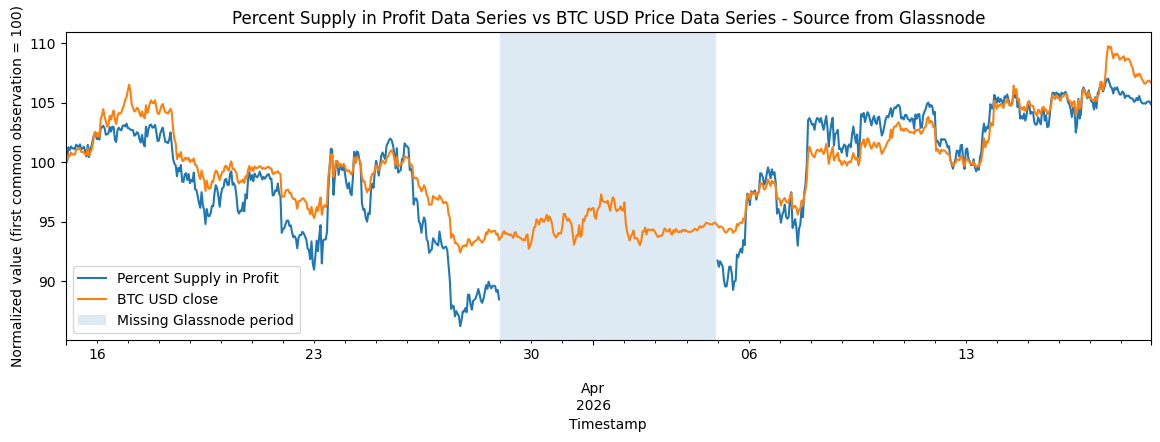

In [25]:
# Comparison window around the missing timestamps
comparison_start = pct_supply_missing_timestamps.min() - pd.Timedelta(days=14)
comparison_end = pct_supply_missing_timestamps.max() + pd.Timedelta(days=14)

# Fetch hourly BTC USD close from Glassnode for comparison
params = {"a": "BTC", "i": "1h", "s": int(comparison_start.timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/market/price_usd_close", params=params)
response.raise_for_status()

btc_price = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": "btc_usd_close"})
btc_price["timestamp"] = pd.to_datetime(btc_price["timestamp"], unit="s", utc=True)
btc_price = btc_price.set_index("timestamp")[["btc_usd_close"]].sort_index().loc[comparison_start:comparison_end]

# Combine and normalize the two series
comparison = pd.concat([df_glassnode["pct_supply_profit"], btc_price["btc_usd_close"]], axis=1).loc[comparison_start:comparison_end]
common = comparison.dropna()
normalized = comparison.divide(common.iloc[0]).multiply(100)

# Plot
ax = normalized.plot(figsize=(14, 4), title="Percent Supply in Profit Data Series vs BTC USD Price Data Series - Source from Glassnode")
ax.axvspan(pct_supply_missing_timestamps.min(), pct_supply_missing_timestamps.max(), alpha=0.15, label="Missing Glassnode period")
ax.set_ylabel("Normalized value (first common observation = 100)")
ax.set_xlabel("Timestamp")
ax.legend(["Percent Supply in Profit", "BTC USD close", "Missing Glassnode period"])
plt.show()

The Percent Supply in Profit series and BTC price both fluctuate materially around the missing interval, there is no stable trend to justfiy just mirroring. Next step is to identify if we can rebuild the data series in an alternative manner.

**Percent Supply in Profit: Calculation methodology and proposed treatment**

Glassnode’s supply/profit_relative metric is calculated based on BTC supply currently in profit divided by circulating supply. The seven-day outage is caused by the hourly supply/profit_sum numerator, and the corresponding loss-side of the series being unavailable, supply/current remains complete. This determines the missing hourly values cannot be reconstructed from the 1-hour component endpoints.

The same supply/profit_relative metric remains fully populated though at 24-hour resolution during the affected week. We will therefore use the daily series to re-create a daily-resolution reconstruction of the same metric, but it does have limitation as it loses intraday nuances.

Our methodology is to reconstruct the economic series at its observation timestamp, and then apply PIT availability rules afterward.

In [26]:
# Reconstruct Percent Supply in Profit using the complete 24-hour version of the same metric
pct_supply_col = "pct_supply_profit"
pct_supply_missing_mask = df_glassnode[pct_supply_col].isna()
pct_supply_original = df_glassnode[pct_supply_col].copy()

params = {"a": "BTC", "i": "24h", "s": int(df_glassnode.index.min().timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/supply/profit_relative", params=params)
response.raise_for_status()

pct_supply_daily = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": pct_supply_col})
pct_supply_daily["timestamp"] = pd.to_datetime(pct_supply_daily["timestamp"], unit="s", utc=True)
pct_supply_daily = pct_supply_daily.set_index("timestamp")[[pct_supply_col]].sort_index()
pct_supply_daily = pct_supply_daily.loc[~pct_supply_daily.index.duplicated(keep="first")]
pct_supply_daily = pct_supply_daily.loc[df_glassnode.index.min().floor("D"):df_glassnode.index.max().ceil("D")]

# Expand the daily series to the common hourly index
pct_supply_daily_1h = pct_supply_daily.reindex(df_glassnode.index).ffill()

# Replace only missing native-hourly observations
pct_supply_profit_1h_clean = pct_supply_original.to_frame()
pct_supply_profit_1h_clean.loc[pct_supply_missing_mask, pct_supply_col] = pct_supply_daily_1h.loc[pct_supply_missing_mask, pct_supply_col]
pct_supply_profit_1h_clean["daily_patch_flag"] = pct_supply_missing_mask.astype(int)

# Validation
valid_native_mask = ~pct_supply_missing_mask
unchanged_native = pct_supply_profit_1h_clean.loc[valid_native_mask, pct_supply_col].equals(pct_supply_original.loc[valid_native_mask])

assert int(pct_supply_missing_mask.sum()) == 168
assert pct_supply_daily_1h.loc[pct_supply_missing_mask, pct_supply_col].notna().all()
assert pct_supply_profit_1h_clean[pct_supply_col].notna().all()
assert int(pct_supply_profit_1h_clean["daily_patch_flag"].sum()) == 168
assert unchanged_native, "Valid native-hourly observations were altered."

pct_supply_profit_1h_clean.to_csv("pct_supply_profit_1h_clean.csv", index_label="timestamp")

print(f"Native hourly missing bars: {int(pct_supply_missing_mask.sum())}")
print(f"Daily observations used: {pct_supply_daily.loc[pct_supply_missing_timestamps.min().floor('D'):pct_supply_missing_timestamps.max().floor('D')].shape[0]}")
print(f"Hourly bars patched: {int(pct_supply_profit_1h_clean['daily_patch_flag'].sum())}")
print(f"Missing values after reconstruction: {int(pct_supply_profit_1h_clean[pct_supply_col].isna().sum())}")
print(f"Valid native-hourly observations unchanged: {unchanged_native}")
print("Saved reconstructed series to: pct_supply_profit_1h_clean.csv")

Native hourly missing bars: 168
Daily observations used: 7
Hourly bars patched: 168
Missing values after reconstruction: 0
Valid native-hourly observations unchanged: True
Saved reconstructed series to: pct_supply_profit_1h_clean.csv


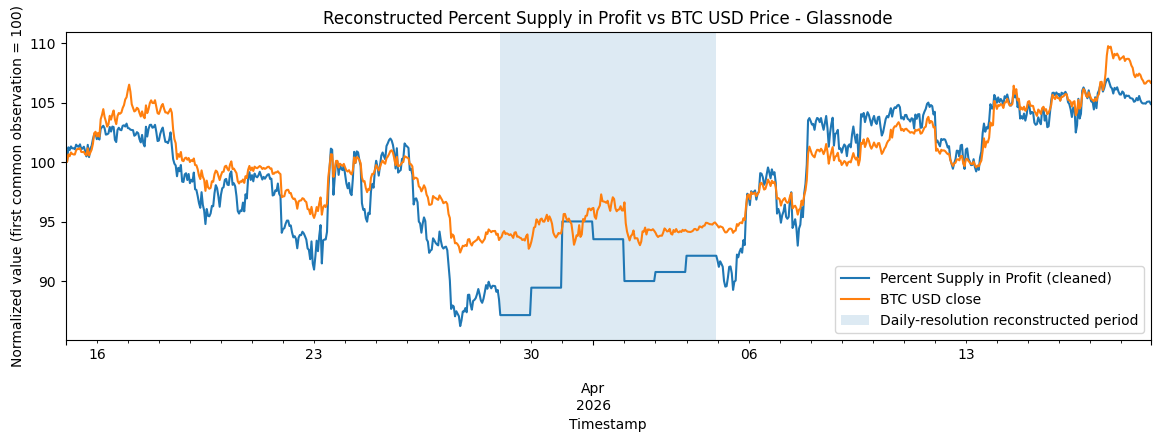

In [28]:
# Plot the reconstructed Percent Supply in Profit series against BTC price
comparison_start = pct_supply_missing_timestamps.min() - pd.Timedelta(days=14)
comparison_end = pct_supply_missing_timestamps.max() + pd.Timedelta(days=14)

# Fetch hourly BTC USD close from Glassnode
params = {"a": "BTC", "i": "1h", "s": int(comparison_start.timestamp()), "api_key": gn_api}
response = requests.get("https://api.glassnode.com/v1/metrics/market/price_usd_close", params=params)
response.raise_for_status()

btc_price = pd.DataFrame(response.json()).rename(columns={"t": "timestamp", "v": "btc_usd_close"})
btc_price["timestamp"] = pd.to_datetime(btc_price["timestamp"], unit="s", utc=True)
btc_price = btc_price.set_index("timestamp")[["btc_usd_close"]].sort_index().loc[comparison_start:comparison_end]

# Combine the cleaned series with BTC price and normalize both to 100
comparison_clean = pd.concat([pct_supply_profit_1h_clean["pct_supply_profit"], btc_price["btc_usd_close"]], axis=1).loc[comparison_start:comparison_end]
common_start = comparison_clean.dropna().iloc[0]
normalized_clean = comparison_clean.divide(common_start).multiply(100)

# Plot and retain the shaded reconstructed interval
ax = normalized_clean.plot(figsize=(14, 4), title="Reconstructed Percent Supply in Profit vs BTC USD Price - Glassnode")
ax.axvspan(pct_supply_missing_timestamps.min(), pct_supply_missing_timestamps.max(), alpha=0.15, label="Daily-resolution reconstructed period")
ax.set_ylabel("Normalized value (first common observation = 100)")
ax.set_xlabel("Timestamp")
ax.legend(["Percent Supply in Profit (cleaned)", "BTC USD close", "Daily-resolution reconstructed period"])

plt.show()

<p>
Step 4: Merging all Glassnode Endpoints in a Point-In-Time Aligned Data File
</p>


In [29]:
# Load the cleaned native-timestamp Glassnode files
glassnode_raw = pd.read_csv("raw_glassnode.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
pct_supply_clean = pd.read_csv("pct_supply_profit_1h_clean.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
inv_loss_pit = pd.read_csv("inv_loss_daily_1h_pit_aligned.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()

# Standardize all indices to UTC
glassnode_raw.index = pd.to_datetime(glassnode_raw.index, utc=True)
pct_supply_clean.index = pd.to_datetime(pct_supply_clean.index, utc=True)
inv_loss_pit.index = pd.to_datetime(inv_loss_pit.index, utc=True)

# Remove separately treated endpoints from the raw Glassnode file
glassnode_raw = glassnode_raw.drop(columns=["pct_supply_profit", "inv_loss_seller"], errors="ignore")

# Retain only the reconstructed Percent Supply in Profit values
pct_supply_clean = pct_supply_clean[["pct_supply_profit"]]

# Validate indices before combining
assert glassnode_raw.index.equals(pct_supply_clean.index), "Glassnode and Percent Supply in Profit indices do not match."
assert glassnode_raw.index.equals(inv_loss_pit.index), "Glassnode and inverse-loss indices do not match."
assert not glassnode_raw.index.duplicated().any(), "Duplicate timestamps found in raw Glassnode data."
assert not pct_supply_clean.index.duplicated().any(), "Duplicate timestamps found in Percent Supply in Profit data."
assert not inv_loss_pit.index.duplicated().any(), "Duplicate timestamps found in inverse-loss data."

# Merge the cleaned Percent Supply in Profit series into the native hourly Glassnode dataset
glassnode_1h_clean = glassnode_raw.join(pct_supply_clean, how="left")

# Apply the two-hour PIT lag to all completed 1-hour Glassnode endpoints
glassnode_1h_pit_aligned = glassnode_1h_clean.shift(2)

# Merge the separately two-day-lagged and hourly-expanded inverse-loss endpoint
glassnode_1h_pit_aligned = glassnode_1h_pit_aligned.join(inv_loss_pit[["inv_loss_seller"]], how="left")

# Final validation
assert glassnode_1h_pit_aligned.index.is_monotonic_increasing, "Final Glassnode index is not sorted."
assert not glassnode_1h_pit_aligned.index.duplicated().any(), "Duplicate timestamps found in final Glassnode data."
assert "pct_supply_profit" in glassnode_1h_pit_aligned.columns, "Percent Supply in Profit is missing."
assert "inv_loss_seller" in glassnode_1h_pit_aligned.columns, "Inverse Loss Seller is missing."
assert glassnode_1h_pit_aligned.columns.duplicated().sum() == 0, "Duplicate column names found."

# Save the final PIT-aligned Glassnode dataset
glassnode_1h_pit_aligned.to_csv("glassnode_1h_pit_aligned.csv", index_label="timestamp")

print(f"Final shape: {glassnode_1h_pit_aligned.shape}")
print(f"Date range: {glassnode_1h_pit_aligned.index.min()} to {glassnode_1h_pit_aligned.index.max()}")
print(f"Duplicate timestamps: {glassnode_1h_pit_aligned.index.duplicated().sum()}")
print(f"Duplicate columns: {glassnode_1h_pit_aligned.columns.duplicated().sum()}")
print(f"Percent Supply in Profit missing values: {glassnode_1h_pit_aligned['pct_supply_profit'].isna().sum()}")
print(f"Inverse Loss Seller missing values: {glassnode_1h_pit_aligned['inv_loss_seller'].isna().sum()}")
print("Saved final PIT-aligned Glassnode file to: glassnode_1h_pit_aligned.csv")

Final shape: (65712, 19)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Duplicate columns: 0
Percent Supply in Profit missing values: 2
Inverse Loss Seller missing values: 50
Saved final PIT-aligned Glassnode file to: glassnode_1h_pit_aligned.csv


### b) **US Dollar Index, S&P500 Index, VIX, 10 Year US Treasury Yield**

<p>
Step 1: Data Extraction
</p>


*   Extract cross-asset benchmark data from yfinance
*   As we may need warm up period during feature engineering, data extraction date starts 2019-01-01 where possible



In [30]:
# extract cross asset data
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

cross_asset_tickers = {
    "DX-Y.NYB": "dxy",
    "^GSPC": "spx",
    "^VIX": "vix",
    "^TNX": "us10y"}

df_cross_asset = (yf.download(list(cross_asset_tickers),
     start="2019-01-01", end="2026-07-01", interval="1d", auto_adjust=False, progress=False)["Close"]
    .rename(columns=cross_asset_tickers)
    .sort_index())

df_cross_asset.index = pd.to_datetime(df_cross_asset.index, utc=True)
df_cross_asset.to_csv("raw_cross_asset.csv", index_label="timestamp")
df_cross_asset.head()

Ticker,dxy,spx,us10y,vix
Date,,,,
2019-01-02 00:00:00+00:00,96.820000,2510.030029,2.661,23.219999
2019-01-03 00:00:00+00:00,96.309998,2447.889893,2.554,25.450001
2019-01-04 00:00:00+00:00,96.190002,2531.939941,2.659,21.379999
2019-01-07 00:00:00+00:00,95.709999,2549.689941,2.682,21.400000
2019-01-08 00:00:00+00:00,95.900002,2574.409912,2.716,20.469999


<p>
Step 2: Data Quality Check
</p>


In [31]:
# Cross-asset data quality checks: shape, date range and missing-value structure

print(f"Shape: {df_cross_asset.shape}")
print(f"Date range: {df_cross_asset.index.min()} to {df_cross_asset.index.max()}")
print(f"Duplicate timestamps: {df_cross_asset.index.duplicated().sum()}")

cross_asset_check_cols = ["dxy", "spx", "vix", "us10y"]

cross_asset_nan_summary = []

for col in cross_asset_check_cols:
    series = df_cross_asset[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    cross_asset_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

cross_asset_nan_summary = pd.DataFrame(cross_asset_nan_summary).set_index("series")

print(f"Total missing values across checked series: {int(cross_asset_nan_summary['missing_count'].sum())}")
print(f"Series with internal NaN values: {int(cross_asset_nan_summary['has_internal_nan'].sum())}")

cross_asset_nan_summary

Shape: (1886, 4)
Date range: 2019-01-02 00:00:00+00:00 to 2026-06-30 00:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked series: 9
Series with internal NaN values: 4


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
dxy,1,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,1,True
spx,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3,True
vix,2,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,2,True
us10y,3,2019-01-02 00:00:00+00:00,2026-06-30 00:00:00+00:00,1886,3,True


<p>
Step 3: Data Cleaning
</p>

In here, data cleaning comprises of 2 parts
*   Examining the NaN profile and handling policy
*   Handling real life data delays, ensure there's no look ahead bias/ data leakage. These data are only available at 24hour horizon and market close, so bars needed to be shifted to ensure no look ahead bias



In [32]:
# Isolate every internal NaN timestamp for each investigated cross-asset series
cross_asset_internal_nan_dates = []

for col in cross_asset_check_cols:
    series = df_cross_asset[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]
    missing_dates = active_series.index[active_series.isna()]

    for missing_date in missing_dates:
        cross_asset_internal_nan_dates.append({
            "series": col,
            "missing_timestamp": missing_date
        })

cross_asset_internal_nan_dates = pd.DataFrame(cross_asset_internal_nan_dates)

if not cross_asset_internal_nan_dates.empty:
    cross_asset_internal_nan_dates = cross_asset_internal_nan_dates.sort_values(
        ["series", "missing_timestamp"]
    ).reset_index(drop=True)

cross_asset_internal_nan_dates

,series,missing_timestamp
0,dxy,2026-05-25 00:00:00+00:00
1,spx,2025-01-09 00:00:00+00:00
2,spx,2025-05-26 00:00:00+00:00
3,spx,2026-05-25 00:00:00+00:00
4,us10y,2025-01-09 00:00:00+00:00
5,us10y,2025-05-26 00:00:00+00:00
6,us10y,2026-05-25 00:00:00+00:00
7,vix,2025-01-09 00:00:00+00:00
8,vix,2025-05-26 00:00:00+00:00


Missing data are all evolved around 2 specific dates, upon further investigation it suggested that both 9 Jan 2025 and 26 May 2025 were US stock markets were closure, naturally no data is available and the handling policy is just to forward fill the missing data.

In [36]:
# Forward-fill internal missing values in the native daily cross-asset series
df_cross_asset = df_cross_asset.ffill()
print(f"Missing values after forward-fill: {df_cross_asset.isna().sum().sum()}")

Missing values after forward-fill: 0


Step 4: Creating Point-In-Time Aligned Data File

In [37]:
# Apply the T+1-calendar-day PIT lag and expand the daily series to an hourly spine
df_cross_asset_pit_daily = df_cross_asset.copy()
df_cross_asset_pit_daily.index = df_cross_asset_pit_daily.index + pd.Timedelta(days=1)

cross_asset_hourly_index = pd.date_range(
    start=df_cross_asset_pit_daily.index.min(),
    end=pd.Timestamp("2026-06-30 23:00:00", tz="UTC"),
    freq="1h")

df_cross_asset_1h_pit = df_cross_asset_pit_daily.reindex(cross_asset_hourly_index).ffill()
df_cross_asset_1h_pit.index.name = "timestamp"

print(f"Shape: {df_cross_asset_1h_pit.shape}")
print(f"Date range: {df_cross_asset_1h_pit.index.min()} to {df_cross_asset_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_cross_asset_1h_pit.index.duplicated().sum()}")
print(f"Remaining missing values: {int(df_cross_asset_1h_pit.isna().sum().sum())}")

df_cross_asset_1h_pit.to_csv("cross_asset_1h_pit_aligned.csv", index_label="timestamp")
df_cross_asset_1h_pit.head()

Shape: (65664, 4)
Date range: 2019-01-03 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Remaining missing values: 0


Ticker,dxy,spx,us10y,vix
timestamp,,,,
2019-01-03 00:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 01:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 02:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 03:00:00+00:00,96.82,2510.030029,2.661,23.219999
2019-01-03 04:00:00+00:00,96.82,2510.030029,2.661,23.219999


### c) **CEX Data**

**i) Binance K-line data** </br>

Step 1: Data extraction

In [38]:
# Binance USD-M perpetual-futures kline extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

binance_kline_endpoints = [
    {"name": "btc", "symbol": "BTCUSDT", "interval": "1h", "start_month": "2019-09"},
    {"name": "eth", "symbol": "ETHUSDT", "interval": "1h", "start_month": "2019-11"}]

analysis_end = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")
kline_columns = ["open_time", "open", "high", "low", "close", "volume", "close_time", "quote_volume", "num_trades", "taker_buy_volume", "taker_buy_quote_volume", "ignore"]
binance_kline_data = {}

for endpoint in binance_kline_endpoints:
    monthly_frames = []
    months = pd.period_range(start=endpoint["start_month"], end="2026-06", freq="M")

    for month in months:
        month = str(month)
        url = f"https://data.binance.vision/data/futures/um/monthly/klines/{endpoint['symbol']}/{endpoint['interval']}/{endpoint['symbol']}-{endpoint['interval']}-{month}.zip"
        response = requests.get(url, timeout=30)

        if response.status_code == 404:
            print(f"No archive found: {endpoint['symbol']} {month}")
            continue

        response.raise_for_status()

        with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
            with archive.open(archive.namelist()[0]) as file:
                monthly_frames.append(pd.read_csv(file, header=None, names=kline_columns))

    if not monthly_frames:
        raise ValueError(f"No kline data returned for {endpoint['symbol']}")

    asset_data = pd.concat(monthly_frames, ignore_index=True)
    open_time_numeric = pd.to_numeric(asset_data["open_time"], errors="coerce")
    open_time_ms = open_time_numeric.where(open_time_numeric < 1e14, open_time_numeric / 1000)
    asset_data["timestamp"] = pd.to_datetime(open_time_ms, unit="ms", utc=True, errors="coerce")

    invalid_timestamp_rows = int(asset_data["timestamp"].isna().sum())
    asset_data = asset_data.dropna(subset=["timestamp"])
    asset_data = asset_data.loc[asset_data["timestamp"] < analysis_end]
    asset_data = asset_data.drop(columns=["open_time", "close_time", "ignore"])

    duplicate_rows = int(asset_data.duplicated().sum())
    asset_data = asset_data.drop_duplicates()
    asset_data = asset_data.set_index("timestamp").sort_index()

    duplicated_timestamp_rows = int(asset_data.index.duplicated(keep=False).sum())
    asset_data = asset_data.loc[~asset_data.index.duplicated(keep=False)]
    asset_data = asset_data.apply(pd.to_numeric, errors="coerce")
    asset_data.columns = [f"{endpoint['name']}_{col}" for col in asset_data.columns]

    print(f"{endpoint['symbol']} invalid timestamp rows removed: {invalid_timestamp_rows}")
    print(f"{endpoint['symbol']} exact duplicate rows removed: {duplicate_rows}")
    print(f"{endpoint['symbol']} duplicated timestamp rows removed: {duplicated_timestamp_rows}")

    binance_kline_data[endpoint["name"]] = asset_data

df_binance_klines = pd.concat([binance_kline_data["btc"], binance_kline_data["eth"]], axis=1).sort_index()
df_binance_klines.to_csv("raw_binance_klines.csv", index_label="timestamp")

df_binance_klines.head()

No archive found: BTCUSDT 2019-09
No archive found: BTCUSDT 2019-10
No archive found: BTCUSDT 2019-11
No archive found: BTCUSDT 2019-12
BTCUSDT invalid timestamp rows removed: 54
BTCUSDT exact duplicate rows removed: 0
BTCUSDT duplicated timestamp rows removed: 0
No archive found: ETHUSDT 2019-11
No archive found: ETHUSDT 2019-12
ETHUSDT invalid timestamp rows removed: 54
ETHUSDT exact duplicate rows removed: 0
ETHUSDT duplicated timestamp rows removed: 0


,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,eth_high,eth_low,eth_close,eth_volume,eth_quote_volume,eth_num_trades,eth_taker_buy_volume,eth_taker_buy_quote_volume
timestamp,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688,996.198,7.149371e+06,129.12,129.12,128.62,128.82,14947.691,1.925644e+06,1249,7707.625,9.928838e+05
2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635,2340.878,1.686029e+07,128.81,130.61,128.76,130.57,34755.256,4.514484e+06,3116,19928.267,2.588555e+06
2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120,1774.145,1.281847e+07,130.58,130.97,130.30,130.80,21864.946,2.857378e+06,1807,10299.172,1.345962e+06
2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143,1245.065,8.996219e+06,130.80,130.82,129.88,130.09,16823.171,2.190835e+06,1448,7580.536,9.869013e+05
2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966,586.864,4.236084e+06,130.10,130.63,130.09,130.15,11357.239,1.480319e+06,1065,5204.925,6.783015e+05


<p>
Step 2: Data Quality Check
</p>


In [39]:
# Binance kline data quality checks: shape, date range and missing-value structure

print(f"Shape: {df_binance_klines.shape}")
print(f"Date range: {df_binance_klines.index.min()} to {df_binance_klines.index.max()}")
print(f"Duplicate timestamps: {df_binance_klines.index.duplicated().sum()}")

binance_kline_check_cols = df_binance_klines.columns.tolist()
binance_kline_nan_summary = []

for col in binance_kline_check_cols:
    series = df_binance_klines[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_kline_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

binance_kline_nan_summary = pd.DataFrame(binance_kline_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(binance_kline_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_kline_nan_summary['has_internal_nan'].sum())}")

binance_kline_nan_summary

Shape: (56952, 18)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
btc_open,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_high,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_low,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_close,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_quote_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_num_trades,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_taker_buy_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
btc_taker_buy_quote_volume,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False


ii) Binance perpetual premium-index data </br>

Step 1: Data extraction

Binance perpetual premium-index data had data quality issues retrieving from binance archive. There's a version available and usable. However, it requires futures REST access and was unavailable from the hosted Google Colab runtime due to an HTTP 451 geographic/IP restriction. Therefore, the premium-index extraction was implemented as a standalone reproducible Python module and executed once from an unrestricted local network. The resulting raw CSV was versioned and frozen for the submitted analysis. The notebook imports the extraction module for code transparency and validates the saved dataset’s schema, coverage, timestamp continuity and integrity before use.

In [49]:
# Load and standardize the Binance BTC perpetual premium-index series

raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)
premium_source_path = f"{raw_data_dir}/raw_binance_perp_premium.csv"

df_binance_premium = pd.read_csv(premium_source_path, parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_premium.index = pd.to_datetime(df_binance_premium.index, utc=True)

df_binance_premium = df_binance_premium.loc[(df_binance_premium.index >= pd.Timestamp("2020-01-01 00:00:00", tz="UTC")) & (df_binance_premium.index < analysis_end)]

premium_cols = ["btc_perp_premium_open", "btc_perp_premium_high", "btc_perp_premium_low", "btc_perp_premium_close"]
missing_columns = [col for col in premium_cols if col not in df_binance_premium.columns]

if missing_columns: raise ValueError(f"Missing Binance premium-index columns: {missing_columns}")

df_binance_premium = df_binance_premium[premium_cols].apply(pd.to_numeric, errors="coerce")
df_binance_premium.to_csv("raw_binance_premium.csv", index_label="timestamp")

df_binance_premium.head()

,btc_perp_premium_open,btc_perp_premium_high,btc_perp_premium_low,btc_perp_premium_close
timestamp,,,,
2020-01-01 00:00:00+00:00,-0.000777,-0.000443,-0.001206,-0.000809
2020-01-01 01:00:00+00:00,-0.000818,-0.000100,-0.001015,-0.000801
2020-01-01 02:00:00+00:00,-0.000445,-0.000445,-0.001063,-0.000554
2020-01-01 03:00:00+00:00,-0.000412,-0.000295,-0.001005,-0.000627
2020-01-01 04:00:00+00:00,-0.000523,-0.000296,-0.000887,-0.000517


<p>
Step 2: Data Quality Check
</p>


In [50]:
# Binance premium-index data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_binance_premium.shape}")
print(f"Date range: {df_binance_premium.index.min()} to {df_binance_premium.index.max()}")
print(f"Duplicate timestamps: {df_binance_premium.index.duplicated().sum()}")

binance_premium_check_cols = df_binance_premium.columns.tolist()
binance_premium_nan_summary = []

for col in binance_premium_check_cols:
    series = df_binance_premium[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_premium_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

binance_premium_nan_summary = pd.DataFrame(binance_premium_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(binance_premium_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_premium_nan_summary['has_internal_nan'].sum())}")

binance_premium_nan_summary

Shape: (56951, 4)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
btc_perp_premium_open,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_high,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_low,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False
btc_perp_premium_close,0,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56951,0,False


In [51]:
# Check for missing hourly timestamps in the Binance premium-index series
premium_expected_index = pd.date_range(start=df_binance_premium.index.min(), end=df_binance_premium.index.max(), freq="h")
premium_missing_timestamps = premium_expected_index.difference(df_binance_premium.index)

print(f"Missing hourly timestamps: {len(premium_missing_timestamps)}")
premium_missing_timestamps

Missing hourly timestamps: 1


DatetimeIndex(['2020-12-01 23:00:00+00:00'], dtype='datetime64[ns, UTC]', freq='h')

<p>
Step 3: Data Cleaning
</p>

In [52]:
# Forward-fill the single missing Binance premium-index hour

premium_full_index = pd.date_range(start=df_binance_premium.index.min(), end=analysis_end - pd.Timedelta(hours=1), freq="h")

df_binance_premium = df_binance_premium.reindex(premium_full_index)
df_binance_premium.index.name = "timestamp"

missing_before = int(df_binance_premium.isna().all(axis=1).sum())
df_binance_premium = df_binance_premium.ffill(limit=1)
missing_after = int(df_binance_premium.isna().all(axis=1).sum())

print(f"Missing premium rows before forward-fill: {missing_before}")
print(f"Missing premium rows after forward-fill: {missing_after}")

Missing premium rows before forward-fill: 1
Missing premium rows after forward-fill: 0


In [53]:
df_binance_premium.to_csv("raw_binance_premium.csv", index_label="timestamp")

iii) Binance funding rate endpoint </br>

Step 1: Data extraction

In [54]:
# Binance BTC funding-rate extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

binance_funding_endpoint = {"name": "btc_funding", "symbol": "BTCUSDT", "start_month": "2019-09"}
funding_monthly_frames = []
funding_months = pd.period_range(start=binance_funding_endpoint["start_month"], end="2026-06", freq="M")

for month in funding_months:
    month = str(month)
    url = f"https://data.binance.vision/data/futures/um/monthly/fundingRate/{binance_funding_endpoint['symbol']}/{binance_funding_endpoint['symbol']}-fundingRate-{month}.zip"
    response = requests.get(url, timeout=30)

    if response.status_code == 404:
        print(f"No archive found: {binance_funding_endpoint['symbol']} funding {month}")
        continue

    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        with archive.open(archive.namelist()[0]) as file:
            funding_monthly_frames.append(pd.read_csv(file))

if not funding_monthly_frames: raise ValueError("No Binance BTC funding-rate data returned")

df_binance_funding = pd.concat(funding_monthly_frames, ignore_index=True)
df_binance_funding.columns = [str(col).strip() for col in df_binance_funding.columns]
df_binance_funding["timestamp"] = pd.to_datetime(pd.to_numeric(df_binance_funding["calc_time"], errors="coerce"), unit="ms", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_binance_funding["timestamp"].isna().sum())
df_binance_funding = df_binance_funding.dropna(subset=["timestamp"])
df_binance_funding = df_binance_funding.loc[df_binance_funding["timestamp"] < analysis_end]
df_binance_funding = df_binance_funding.set_index("timestamp").sort_index()

duplicate_timestamp_rows = int(df_binance_funding.index.duplicated(keep=False).sum())
df_binance_funding = df_binance_funding.loc[~df_binance_funding.index.duplicated(keep=False)]

df_binance_funding = df_binance_funding[["last_funding_rate"]].rename(columns={"last_funding_rate": "btc_funding"})
df_binance_funding["btc_funding"] = pd.to_numeric(df_binance_funding["btc_funding"], errors="coerce")

print(f"BTC funding invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"BTC funding duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_binance_funding.to_csv("raw_binance_funding.csv", index_label="timestamp")
df_binance_funding.head()

No archive found: BTCUSDT funding 2019-09
No archive found: BTCUSDT funding 2019-10
No archive found: BTCUSDT funding 2019-11
No archive found: BTCUSDT funding 2019-12
BTC funding invalid timestamp rows removed: 0
BTC funding duplicated timestamp rows removed: 0


,btc_funding
timestamp,
2020-01-01 00:00:00+00:00,-0.000124
2020-01-01 08:00:00+00:00,-0.000124
2020-01-01 16:00:00+00:00,-0.000097
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-02 08:00:00+00:00,0.000100


<p>
Step 2: Data Quality Check
</p>


In [55]:
# Binance funding-rate data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_binance_funding.shape}")
print(f"Date range: {df_binance_funding.index.min()} to {df_binance_funding.index.max()}")
print(f"Duplicate timestamps: {df_binance_funding.index.duplicated().sum()}")

binance_funding_check_cols = df_binance_funding.columns.tolist()
binance_funding_nan_summary = []

for col in binance_funding_check_cols:
    series = df_binance_funding[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    binance_funding_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

binance_funding_nan_summary = pd.DataFrame(binance_funding_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(binance_funding_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(binance_funding_nan_summary['has_internal_nan'].sum())}")
binance_funding_nan_summary

Shape: (7119, 1)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 16:00:00.005000+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
btc_funding,0,2020-01-01 00:00:00+00:00,2026-06-30 16:00:00.005000+00:00,7119,0,False


<p>
Step 3: Data Cleaning
</p>

There are no missing value to be handled in this data series, however the initial header display is showing an odd index which requires investigation/ cleaning - 2020-01-02 00:00:00.002000+00:00



In [56]:
# Find funding timestamps that are not exactly aligned to the hour
funding_off_hour = df_binance_funding[(df_binance_funding.index.minute != 0) | (df_binance_funding.index.second != 0) | (df_binance_funding.index.microsecond != 0)]
funding_off_hour

,btc_funding
timestamp,
2020-01-02 00:00:00.002000+00:00,0.000037
2020-01-03 16:00:00.001000+00:00,0.000100
2020-01-07 08:00:00.001000+00:00,0.000100
2020-01-08 16:00:00.001000+00:00,0.000100
2020-01-13 00:00:00.001000+00:00,0.000100
...,...
2026-06-28 08:00:00.013000+00:00,0.000014
2026-06-29 00:00:00.006000+00:00,0.000031
2026-06-29 08:00:00.013000+00:00,0.000074


In [57]:
# Round Binance funding timestamps to the nearest hour
df_binance_funding.index = (df_binance_funding.index.round("h"))

In [58]:
# Funding settlements should normally occur at 00:00, 08:00 and 16:00 UTC
unexpected_funding_hours = df_binance_funding[~df_binance_funding.index.hour.isin([0, 8, 16])]
print("Unexpected funding-hour rows:", len(unexpected_funding_hours))

Unexpected funding-hour rows: 0


<p>
Step 4: Creating Point-In-Time Aligned Data File
</p>

BTC funding rate settles every 8 hours, as such we need to transform this series into a point-in-time aligned data towards the one hour resolution level.



In [59]:
# Expand the T+0 Binance funding-rate series from its native 8-hour cadence to an hourly spine

funding_hourly_index = pd.date_range(start=df_binance_funding.index.min(), end=pd.Timestamp("2026-06-30 23:00:00", tz="UTC"), freq="1h")

df_binance_funding_1h_pit = df_binance_funding.reindex(funding_hourly_index).ffill()
df_binance_funding_1h_pit.index.name = "timestamp"

print(f"Shape: {df_binance_funding_1h_pit.shape}")
print(f"Date range: {df_binance_funding_1h_pit.index.min()} to {df_binance_funding_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_binance_funding_1h_pit.index.duplicated().sum()}")
print(f"Remaining missing values: {int(df_binance_funding_1h_pit.isna().sum().sum())}")

df_binance_funding_1h_pit.to_csv("binance_funding_1h_pit_aligned.csv", index_label="timestamp")
df_binance_funding_1h_pit.head()

Shape: (56952, 1)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Remaining missing values: 0


,btc_funding
timestamp,
2020-01-01 00:00:00+00:00,-0.000124
2020-01-01 01:00:00+00:00,-0.000124
2020-01-01 02:00:00+00:00,-0.000124
2020-01-01 03:00:00+00:00,-0.000124
2020-01-01 04:00:00+00:00,-0.000124


**Merge all binance endpoint into a single csv file**

In [60]:
# Load the completed Binance source files for the final source-level merge
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_binance_klines_merge = pd.read_csv("raw_binance_klines.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_premium_merge = pd.read_csv("raw_binance_premium.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()
df_binance_funding_merge = pd.read_csv("binance_funding_1h_pit_aligned.csv", parse_dates=["timestamp"]).set_index("timestamp").sort_index()

for df in [df_binance_klines_merge, df_binance_premium_merge, df_binance_funding_merge]:
    df.index = pd.to_datetime(df.index, utc=True)

df_binance_1h_pit = pd.concat([df_binance_klines_merge, df_binance_premium_merge, df_binance_funding_merge], axis=1).sort_index()
df_binance_1h_pit.index.name = "timestamp"

print(f"Shape: {df_binance_1h_pit.shape}")
print(f"Date range: {df_binance_1h_pit.index.min()} to {df_binance_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_binance_1h_pit.index.duplicated().sum()}")
print(f"Total missing values: {int(df_binance_1h_pit.isna().sum().sum())}")

df_binance_1h_pit.to_csv("binance_1h_pit_aligned.csv", index_label="timestamp")
df_binance_1h_pit.head()

Shape: (56952, 23)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values: 0


,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,eth_volume,eth_quote_volume,eth_num_trades,eth_taker_buy_volume,eth_taker_buy_quote_volume,btc_perp_premium_open,btc_perp_premium_high,btc_perp_premium_low,btc_perp_premium_close,btc_funding
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688,996.198,7.149371e+06,129.12,...,14947.691,1.925644e+06,1249,7707.625,9.928838e+05,-0.000777,-0.000443,-0.001206,-0.000809,-0.000124
2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635,2340.878,1.686029e+07,128.81,...,34755.256,4.514484e+06,3116,19928.267,2.588555e+06,-0.000818,-0.000100,-0.001015,-0.000801,-0.000124
2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120,1774.145,1.281847e+07,130.58,...,21864.946,2.857378e+06,1807,10299.172,1.345962e+06,-0.000445,-0.000445,-0.001063,-0.000554,-0.000124
2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143,1245.065,8.996219e+06,130.80,...,16823.171,2.190835e+06,1448,7580.536,9.869013e+05,-0.000412,-0.000295,-0.001005,-0.000627,-0.000124
2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966,586.864,4.236084e+06,130.10,...,11357.239,1.480319e+06,1065,5204.925,6.783015e+05,-0.000523,-0.000296,-0.000887,-0.000517,-0.000124


**iv) Coinbase BTC USD spot price** </br>

Step 1: Data extraction

In [4]:
# Coinbase BTC-USD hourly candle extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

coinbase_endpoint = {
    "name": "coinbase_btc_close",
    "url": "https://api.exchange.coinbase.com/products/BTC-USD/candles",
    "granularity": 3600,
    "start": "2019-01-01",
    "end": "2026-07-01"
}

coinbase_rows = []
start_time = pd.Timestamp(coinbase_endpoint["start"], tz="UTC")
end_time = pd.Timestamp(coinbase_endpoint["end"], tz="UTC")

while start_time < end_time:
    window_end = min(start_time + pd.Timedelta(hours=300), end_time)
    params = {"granularity": coinbase_endpoint["granularity"], "start": start_time.isoformat(), "end": window_end.isoformat()}
    response = requests.get(coinbase_endpoint["url"], params=params, headers={"User-Agent": "research_project"}, timeout=30)
    response.raise_for_status()
    data = response.json()

    if not isinstance(data, list): raise ValueError(f"Coinbase returned an unexpected response: {data}")

    coinbase_rows.extend(data)
    start_time = window_end
    time.sleep(0.1)

df_coinbase = pd.DataFrame(coinbase_rows, columns=["timestamp", "low", "high", "open", "close", "volume"])
df_coinbase["timestamp"] = pd.to_datetime(pd.to_numeric(df_coinbase["timestamp"], errors="coerce"), unit="s", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_coinbase["timestamp"].isna().sum())
df_coinbase = df_coinbase.dropna(subset=["timestamp"])
df_coinbase = df_coinbase.loc[df_coinbase["timestamp"] < end_time]
df_coinbase = df_coinbase.set_index("timestamp").sort_index()

exact_duplicate_rows = int(df_coinbase.duplicated().sum())
df_coinbase = df_coinbase.drop_duplicates()

duplicate_timestamp_rows = int(df_coinbase.index.duplicated(keep=False).sum())
df_coinbase = df_coinbase.loc[~df_coinbase.index.duplicated(keep=False)]

df_coinbase = df_coinbase[["close"]].rename(columns={"close": coinbase_endpoint["name"]})
df_coinbase["coinbase_btc_close"] = pd.to_numeric(df_coinbase["coinbase_btc_close"], errors="coerce")
df_coinbase.index.name = "timestamp"

print(f"Invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"Exact duplicate rows removed: {exact_duplicate_rows}")
print(f"Duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_coinbase.to_csv("coinbase_1h_pit_aligned.csv", index_label="timestamp")
df_coinbase.head()

Invalid timestamp rows removed: 0
Exact duplicate rows removed: 219
Duplicated timestamp rows removed: 0


,coinbase_btc_close
timestamp,
2019-01-01 00:00:00+00:00,3691.89
2019-01-01 01:00:00+00:00,3676.66
2019-01-01 02:00:00+00:00,3674.00
2019-01-01 03:00:00+00:00,3682.00
2019-01-01 04:00:00+00:00,3681.80


<p>
Step 2: Data Quality Check
</p>


In [5]:
# Coinbase data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_coinbase.shape}")
print(f"Date range: {df_coinbase.index.min()} to {df_coinbase.index.max()}")
print(f"Duplicate timestamps: {df_coinbase.index.duplicated().sum()}")

coinbase_check_cols = df_coinbase.columns.tolist()
coinbase_nan_summary = []

for col in coinbase_check_cols:
    series = df_coinbase[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    coinbase_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

coinbase_nan_summary = pd.DataFrame(coinbase_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(coinbase_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(coinbase_nan_summary['has_internal_nan'].sum())}")
coinbase_nan_summary

Shape: (65693, 1)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
coinbase_btc_close,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65693,0,False


v) OKX BTC Perp endpoint </br>

Step 1: Data extraction

In [6]:
# OKX BTC-USDT perpetual hourly candle extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

okx_endpoint = {"name": "okx_btc_close", "instrument": "BTC-USDT-SWAP", "bar": "1H", "url": "https://www.okx.com/api/v5/market/history-candles", "limit": 300}
okx_start_time = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
okx_end_time = pd.Timestamp("2026-06-30 23:00:00", tz="UTC")

okx_rows = []
after = None

while True:
    params = {"instId": okx_endpoint["instrument"], "bar": okx_endpoint["bar"], "limit": okx_endpoint["limit"]}

    if after is not None: params["after"] = after

    response = requests.get(okx_endpoint["url"], params=params, timeout=30)
    response.raise_for_status()
    body = response.json()

    if body.get("code") != "0": raise ValueError(f"OKX returned code {body.get('code')}: {body.get('msg')}")

    data = body.get("data", [])

    if not data: break

    okx_rows.extend(data)
    oldest_timestamp_ms = min(int(row[0]) for row in data)
    oldest_timestamp = pd.to_datetime(oldest_timestamp_ms, unit="ms", utc=True)

    if oldest_timestamp <= okx_start_time: break

    if after is not None and oldest_timestamp_ms >= int(after):
        print("OKX pagination stopped because the cursor did not move backward.")
        break

    after = oldest_timestamp_ms
    time.sleep(0.1)

if not okx_rows: raise ValueError("No OKX BTC hourly candle data returned")

okx_columns = ["timestamp", "open", "high", "low", "close", "volume", "volume_ccy", "volume_quote", "confirm"]
df_okx = pd.DataFrame(okx_rows, columns=okx_columns)

exact_duplicate_rows = int(df_okx.duplicated().sum())
df_okx = df_okx.drop_duplicates()

df_okx["timestamp"] = pd.to_datetime(pd.to_numeric(df_okx["timestamp"], errors="coerce"), unit="ms", utc=True, errors="coerce")

invalid_timestamp_rows = int(df_okx["timestamp"].isna().sum())
df_okx = df_okx.dropna(subset=["timestamp"])

unconfirmed_rows = int((df_okx["confirm"].astype(str) != "1").sum())
df_okx = df_okx.loc[df_okx["confirm"].astype(str) == "1"]
df_okx = df_okx.loc[(df_okx["timestamp"] >= okx_start_time) & (df_okx["timestamp"] <= okx_end_time)]
df_okx = df_okx.set_index("timestamp").sort_index()

duplicate_timestamp_rows = int(df_okx.index.duplicated(keep=False).sum())
df_okx = df_okx.loc[~df_okx.index.duplicated(keep=False)]

df_okx = df_okx[["close"]].rename(columns={"close": okx_endpoint["name"]})
df_okx["okx_btc_close"] = pd.to_numeric(df_okx["okx_btc_close"], errors="coerce")
df_okx.index.name = "timestamp"

print(f"Exact duplicate rows removed: {exact_duplicate_rows}")
print(f"Invalid timestamp rows removed: {invalid_timestamp_rows}")
print(f"Unconfirmed rows removed: {unconfirmed_rows}")
print(f"Duplicated timestamp rows removed: {duplicate_timestamp_rows}")

df_okx.to_csv("okx_1h_pit_aligned.csv", index_label="timestamp")
df_okx.head()

Exact duplicate rows removed: 0
Invalid timestamp rows removed: 0
Unconfirmed rows removed: 1
Duplicated timestamp rows removed: 0


,okx_btc_close
timestamp,
2019-12-16 06:00:00+00:00,7079.0
2019-12-16 07:00:00+00:00,7052.7
2019-12-16 08:00:00+00:00,7064.8
2019-12-16 09:00:00+00:00,7059.8
2019-12-16 10:00:00+00:00,7063.7


<p>
Step 2: Data Quality Check
</p>


In [7]:
# OKX data quality checks: shape, date range and missing-value structure
print(f"Shape: {df_okx.shape}")
print(f"Date range: {df_okx.index.min()} to {df_okx.index.max()}")
print(f"Duplicate timestamps: {df_okx.index.duplicated().sum()}")

okx_check_cols = df_okx.columns.tolist()
okx_nan_summary = []

for col in okx_check_cols:
    series = df_okx[col]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    okx_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

okx_nan_summary = pd.DataFrame(okx_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(okx_nan_summary['missing_count'].sum())}")
print(f"Fields with internal NaN values: {int(okx_nan_summary['has_internal_nan'].sum())}")
okx_nan_summary

Shape: (57330, 1)
Date range: 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Total missing values across checked fields: 0
Fields with internal NaN values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
series,,,,,,
okx_btc_close,0,2019-12-16 06:00:00+00:00,2026-06-30 23:00:00+00:00,57330,0,False


**vi) Deribit endpoints**</br>

Step 1: Data extraction

In [9]:
# Deribit BTC perpetual and quarterly futures extraction
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

deribit_endpoint = {"name": "deribit_btc_futures", "url": "https://www.deribit.com/api/v2/public/get_tradingview_chart_data", "resolution": "60"}
deribit_start_time = pd.Timestamp("2019-01-01 00:00:00", tz="UTC")
deribit_end_time = pd.Timestamp("2026-06-30 23:00:00", tz="UTC")

def last_friday(year, month):
    month_end = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)

    while month_end.dayofweek != 4:
        month_end -= pd.Timedelta(days=1)

    return month_end

deribit_instruments = [{
    "instrument_name": "BTC-PERPETUAL",
    "instrument_family": "perpetual",
    "settlement_period": "perpetual",
    "expiration_timestamp_ms": pd.NA,
    "expiration_timestamp": pd.NaT
}]

for year in range(2019, 2028):
    for month in [3, 6, 9, 12]:
        expiry_date = last_friday(year, month)
        expiry_timestamp = pd.Timestamp(year=year, month=month, day=expiry_date.day, hour=8, tz="UTC")
        instrument_name = f"BTC-{expiry_timestamp.day}{expiry_timestamp.strftime('%b').upper()}{expiry_timestamp.strftime('%y')}"

        deribit_instruments.append({
            "instrument_name": instrument_name,
            "instrument_family": "quarterly",
            "settlement_period": "month",
            "expiration_timestamp_ms": int(expiry_timestamp.timestamp() * 1000),
            "expiration_timestamp": expiry_timestamp
        })

df_deribit_instruments = pd.DataFrame(deribit_instruments)

print(f"Deribit candidate instruments: {len(df_deribit_instruments)}")
display(df_deribit_instruments.head())

deribit_frames = []
deribit_unavailable_instruments = []

for instrument in deribit_instruments:
    instrument_name = instrument["instrument_name"]
    expiration_timestamp = instrument["expiration_timestamp"]
    instrument_end_time = min(deribit_end_time, expiration_timestamp) if pd.notna(expiration_timestamp) else deribit_end_time

    if instrument_end_time < deribit_start_time:
        continue

    window_start = deribit_start_time
    instrument_returned_data = False
    instrument_request_failed = False

    while window_start < instrument_end_time:
        window_end = min(window_start + pd.Timedelta(days=30), instrument_end_time)

        params = {
            "instrument_name": instrument_name,
            "start_timestamp": int(window_start.timestamp() * 1000),
            "end_timestamp": int(window_end.timestamp() * 1000),
            "resolution": deribit_endpoint["resolution"]
        }

        response = requests.get(deribit_endpoint["url"], params=params, timeout=30)

        if response.status_code == 400:
            instrument_request_failed = True
            break

        response.raise_for_status()
        body = response.json()

        if "error" in body:
            instrument_request_failed = True
            break

        result = body.get("result", {})
        ticks = result.get("ticks", [])

        if result.get("status") == "ok" and ticks:
            candle_count = len(ticks)

            candle_frame = pd.DataFrame({
                "timestamp_ms": ticks,
                "open": result.get("open", [None] * candle_count),
                "high": result.get("high", [None] * candle_count),
                "low": result.get("low", [None] * candle_count),
                "close": result.get("close", [None] * candle_count),
                "volume": result.get("volume", [None] * candle_count),
                "cost": result.get("cost", [None] * candle_count)
            })

            candle_frame["instrument_name"] = instrument_name
            candle_frame["instrument_family"] = instrument["instrument_family"]
            candle_frame["settlement_period"] = instrument["settlement_period"]
            candle_frame["expiration_timestamp_ms"] = instrument["expiration_timestamp_ms"]
            candle_frame["expiration_timestamp"] = instrument["expiration_timestamp"]

            deribit_frames.append(candle_frame)
            instrument_returned_data = True

        window_start = window_end
        time.sleep(0.1)

    if instrument_request_failed or not instrument_returned_data:
        deribit_unavailable_instruments.append(instrument_name)

if not deribit_frames:
    raise ValueError("No Deribit BTC futures candle data returned")

print(f"Deribit instruments returning data: {len(deribit_instruments) - len(deribit_unavailable_instruments)}")
print(f"Deribit candidate instruments without returned data: {len(deribit_unavailable_instruments)}")

if deribit_unavailable_instruments:
    print(deribit_unavailable_instruments)

df_deribit_futures = pd.concat(deribit_frames, ignore_index=True)

df_deribit_futures["timestamp"] = pd.to_datetime(pd.to_numeric(df_deribit_futures["timestamp_ms"], errors="coerce"), unit="ms", utc=True, errors="coerce")
df_deribit_futures["expiration_timestamp"] = pd.to_datetime(df_deribit_futures["expiration_timestamp"], utc=True, errors="coerce")

deribit_numeric_cols = ["open", "high", "low", "close", "volume", "cost"]
df_deribit_futures[deribit_numeric_cols] = df_deribit_futures[deribit_numeric_cols].apply(pd.to_numeric, errors="coerce")

df_deribit_futures = df_deribit_futures.loc[(df_deribit_futures["timestamp"] >= deribit_start_time) & (df_deribit_futures["timestamp"] <= deribit_end_time)]
df_deribit_futures = df_deribit_futures.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

df_deribit_futures.to_csv("raw_deribit_btc_futures.csv", index=False)
df_deribit_futures.head()

Deribit candidate instruments: 37


,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp
0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT
1,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00
2,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00
3,BTC-27SEP19,quarterly,month,1569571200000,2019-09-27 08:00:00+00:00
4,BTC-27DEC19,quarterly,month,1577433600000,2019-12-27 08:00:00+00:00


Deribit instruments returning data: 35
Deribit candidate instruments without returned data: 2
['BTC-24SEP27', 'BTC-31DEC27']


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp
0,1546300800000,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 00:00:00+00:00
1,1546300800000,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 00:00:00+00:00
2,1546300800000,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT,2019-01-01 00:00:00+00:00
3,1546304400000,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 01:00:00+00:00
4,1546304400000,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 01:00:00+00:00


<p>
Step 2: Data Quality Check
</p>


In [11]:
# Deribit data quality checks: panel structure, duplicates, invalid timestamps, post-expiry rows and missing values
print(f"Shape: {df_deribit_futures.shape}")
print(f"Date range: {df_deribit_futures['timestamp'].min()} to {df_deribit_futures['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures['instrument_name'].nunique()}")

exact_duplicate_rows = int(df_deribit_futures.duplicated().sum())
invalid_timestamp_rows = int(df_deribit_futures["timestamp"].isna().sum())

duplicate_contract_timestamp_rows = int(
    df_deribit_futures.duplicated(subset=["timestamp", "instrument_name"], keep=False).sum()
)

post_expiry_mask = (
    df_deribit_futures["expiration_timestamp"].notna()
    & (df_deribit_futures["timestamp"] > df_deribit_futures["expiration_timestamp"])
)

post_expiry_rows = int(post_expiry_mask.sum())

print(f"Exact duplicate rows: {exact_duplicate_rows}")
print(f"Invalid timestamp rows: {invalid_timestamp_rows}")
print(f"Duplicated instrument-timestamp rows: {duplicate_contract_timestamp_rows}")
print(f"Post-expiry rows: {post_expiry_rows}")

deribit_check_cols = ["open", "high", "low", "close", "volume", "cost"]
deribit_nan_summary = []

for col in deribit_check_cols:
    series = df_deribit_futures[col]
    first_valid = df_deribit_futures.loc[series.notna(), "timestamp"].min()
    last_valid = df_deribit_futures.loc[series.notna(), "timestamp"].max()

    deribit_nan_summary.append({
        "series": col,
        "missing_count": int(series.isna().sum()),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "has_missing_values": bool(series.isna().any())
    })

deribit_nan_summary = pd.DataFrame(deribit_nan_summary).set_index("series")

print(f"Total missing values across checked fields: {int(deribit_nan_summary['missing_count'].sum())}")
print(f"Fields with missing values: {int(deribit_nan_summary['has_missing_values'].sum())}")
deribit_nan_summary

Shape: (298630, 13)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Instruments: 35
Exact duplicate rows: 415
Invalid timestamp rows: 0
Duplicated instrument-timestamp rows: 830
Post-expiry rows: 0
Total missing values across checked fields: 0
Fields with missing values: 0


,missing_count,first_valid_timestamp,last_valid_timestamp,has_missing_values
series,,,,
open,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False
high,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False
low,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False
close,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False
volume,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False
cost,0,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,False


In [13]:
# Check missing hourly timestamps within each Deribit contract's active observed period
deribit_missing_summary = []
deribit_missing_timestamps = []

for instrument_name, instrument_data in df_deribit_futures.groupby("instrument_name"):
    instrument_data = instrument_data.sort_values("timestamp")
    first_timestamp = instrument_data["timestamp"].min()
    last_timestamp = instrument_data["timestamp"].max()
    expected_index = pd.date_range(start=first_timestamp, end=last_timestamp, freq="1h")
    observed_index = pd.DatetimeIndex(instrument_data["timestamp"])
    missing_index = expected_index.difference(observed_index)

    deribit_missing_summary.append({
        "instrument_name": instrument_name,
        "first_timestamp": first_timestamp,
        "last_timestamp": last_timestamp,
        "observed_rows": len(instrument_data),
        "expected_rows": len(expected_index),
        "missing_hour_count": len(missing_index),
        "has_missing_hours": bool(len(missing_index))
    })

    for missing_timestamp in missing_index:
        deribit_missing_timestamps.append({
            "instrument_name": instrument_name,
            "missing_timestamp": missing_timestamp
        })

deribit_missing_summary = pd.DataFrame(deribit_missing_summary).set_index("instrument_name").sort_index()
deribit_missing_timestamps = pd.DataFrame(deribit_missing_timestamps)

print(f"Contracts with missing hours: {int(deribit_missing_summary['has_missing_hours'].sum())}")
print(f"Total missing contract-hours: {int(deribit_missing_summary['missing_hour_count'].sum())}")
deribit_missing_summary

Contracts with missing hours: 0
Total missing contract-hours: 0


,first_timestamp,last_timestamp,observed_rows,expected_rows,missing_hour_count,has_missing_hours
instrument_name,,,,,,
BTC-24JUN22,2021-06-25 13:00:00+00:00,2022-06-24 08:00:00+00:00,8732,8732,0,False
BTC-24SEP21,2020-12-25 08:00:00+00:00,2021-09-24 08:00:00+00:00,6553,6553,0,False
BTC-25DEC20,2020-04-24 08:00:00+00:00,2020-12-25 08:00:00+00:00,5881,5881,0,False
BTC-25DEC26,2025-12-26 08:00:00+00:00,2026-06-30 23:00:00+00:00,4480,4480,0,False
BTC-25JUN21,2020-09-25 08:00:00+00:00,2021-06-25 08:00:00+00:00,6553,6553,0,False
BTC-25JUN27,2026-06-26 08:00:00+00:00,2026-06-30 23:00:00+00:00,112,112,0,False
BTC-25MAR22,2021-04-19 12:00:00+00:00,2022-03-25 08:00:00+00:00,8157,8157,0,False
BTC-25SEP20,2020-03-02 08:00:00+00:00,2020-09-25 08:00:00+00:00,4969,4969,0,False
BTC-25SEP26,2025-09-26 08:00:00+00:00,2026-06-30 23:00:00+00:00,6664,6664,0,False


<p>
Step 3: Data Cleaning
</p>


In [12]:
# Remove exact duplicate rows from the Deribit contract panel

rows_before = len(df_deribit_futures)
df_deribit_futures = df_deribit_futures.drop_duplicates().sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)
rows_after = len(df_deribit_futures)

print(f"Exact duplicate rows removed: {rows_before - rows_after}")
print(f"Remaining duplicated instrument-timestamp rows: {df_deribit_futures.duplicated(subset=['timestamp', 'instrument_name'], keep=False).sum()}")
print(f"Cleaned shape: {df_deribit_futures.shape}")

df_deribit_futures.to_csv("deribit_btc_futures_clean.csv", index=False)
df_deribit_futures.head()

Exact duplicate rows removed: 415
Remaining duplicated instrument-timestamp rows: 0
Cleaned shape: (298215, 13)


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp
0,1546300800000,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 00:00:00+00:00
1,1546300800000,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 00:00:00+00:00
2,1546300800000,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT,2019-01-01 00:00:00+00:00
3,1546304400000,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 01:00:00+00:00
4,1546304400000,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 01:00:00+00:00


<p>
Step 4: Creating Point-In-Time Aligned Data File
</p>


In [14]:
# Apply the T+1-hour PIT lag to the cleaned Deribit contract panel
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_deribit_futures_pit = df_deribit_futures.copy()
df_deribit_futures_pit["timestamp"] = df_deribit_futures_pit["timestamp"] + pd.Timedelta(hours=1)
df_deribit_futures_pit = df_deribit_futures_pit.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

print(f"Shape: {df_deribit_futures_pit.shape}")
print(f"Date range: {df_deribit_futures_pit['timestamp'].min()} to {df_deribit_futures_pit['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures_pit['instrument_name'].nunique()}")
print(f"Duplicated instrument-timestamp rows: {df_deribit_futures_pit.duplicated(subset=['timestamp', 'instrument_name'], keep=False).sum()}")
print(f"Missing values in market fields: {int(df_deribit_futures_pit[['open', 'high', 'low', 'close', 'volume', 'cost']].isna().sum().sum())}")

df_deribit_futures_pit.to_csv("deribit_btc_futures_pit_aligned.csv", index=False)
df_deribit_futures_pit.head()

Shape: (298215, 13)
Date range: 2019-01-01 01:00:00+00:00 to 2026-07-01 00:00:00+00:00
Instruments: 35
Duplicated instrument-timestamp rows: 0
Missing values in market fields: 0


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp
0,1546300800000,3607.5,3617.0,3598.0,3605.5,8.886658,32090.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 01:00:00+00:00
1,1546300800000,3630.5,3644.5,3621.0,3633.0,71.291402,258770.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 01:00:00+00:00
2,1546300800000,3697.0,3706.0,3686.5,3696.5,205.492577,759020.0,BTC-PERPETUAL,perpetual,perpetual,<NA>,NaT,2019-01-01 01:00:00+00:00
3,1546304400000,3606.0,3608.5,3586.5,3589.5,15.256294,54840.0,BTC-28JUN19,quarterly,month,1561708800000,2019-06-28 08:00:00+00:00,2019-01-01 02:00:00+00:00
4,1546304400000,3631.0,3631.0,3615.0,3624.0,23.823414,86320.0,BTC-29MAR19,quarterly,month,1553846400000,2019-03-29 08:00:00+00:00,2019-01-01 02:00:00+00:00


## **(III) Raw Data Merge & Data Set Partitioning**

### **a) Load Cleaned Raw Data**

i) Deribit data - already cleaned and point in time aligned

In [15]:
# Load the PIT-aligned Deribit contract panel
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

df_deribit_futures_pit = pd.read_csv("deribit_btc_futures_pit_aligned.csv", parse_dates=["timestamp", "expiration_timestamp"])
df_deribit_futures_pit["timestamp"] = pd.to_datetime(df_deribit_futures_pit["timestamp"], utc=True, errors="coerce")
df_deribit_futures_pit["expiration_timestamp"] = pd.to_datetime(df_deribit_futures_pit["expiration_timestamp"], utc=True, errors="coerce")
df_deribit_futures_pit = df_deribit_futures_pit.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

print(f"Shape: {df_deribit_futures_pit.shape}")
print(f"Date range: {df_deribit_futures_pit['timestamp'].min()} to {df_deribit_futures_pit['timestamp'].max()}")
print(f"Instruments: {df_deribit_futures_pit['instrument_name'].nunique()}")
print(f"Invalid timestamps: {df_deribit_futures_pit['timestamp'].isna().sum()}")
print(f"Duplicated instrument-timestamp rows: {df_deribit_futures_pit.duplicated(['timestamp', 'instrument_name']).sum()}")

Shape: (298215, 13)
Date range: 2019-01-01 01:00:00+00:00 to 2026-07-01 00:00:00+00:00
Instruments: 35
Invalid timestamps: 0
Duplicated instrument-timestamp rows: 0


ii) Glassnode, yfinance, CEX data - already cleaned and point in time aligned

In [16]:
# Load the completed PIT-aligned hourly source files
raw_data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data"; os.chdir(raw_data_dir)

hourly_source_files = {
    "binance": "binance_1h_pit_aligned.csv",
    "coinbase": "coinbase_1h_pit_aligned.csv",
    "okx": "okx_1h_pit_aligned.csv",
    "glassnode": "glassnode_1h_pit_aligned.csv",
    "cross_asset": "cross_asset_1h_pit_aligned.csv"}

hourly_sources = {}

for source_name, filename in hourly_source_files.items():
    source_df = pd.read_csv(filename, parse_dates=["timestamp"]).set_index("timestamp").sort_index()
    source_df.index = pd.to_datetime(source_df.index, utc=True)
    source_df.index.name = "timestamp"
    hourly_sources[source_name] = source_df

    print(f"{source_name}: {source_df.shape} | {source_df.index.min()} to {source_df.index.max()} | duplicates: {source_df.index.duplicated().sum()}")

binance: (56952, 23) | 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
coinbase: (65693, 1) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
okx: (57330, 1) | 2019-12-16 06:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
glassnode: (65712, 19) | 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0
cross_asset: (65664, 4) | 2019-01-03 00:00:00+00:00 to 2026-06-30 23:00:00+00:00 | duplicates: 0


### **b) Merge Hourly Data Sources**

In [21]:
# Merge all finalized PIT-aligned one-row-per-hour source files
df_merged_1h_pit = pd.concat([
    hourly_sources["binance"],
    hourly_sources["coinbase"],
    hourly_sources["okx"],
    hourly_sources["glassnode"],
    hourly_sources["cross_asset"]
], axis=1, join="outer").sort_index()

df_merged_1h_pit.index.name = "timestamp"
df_merged_1h_pit.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,34770.0,1.699421e+06,-210971.696499,0.445557,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,21379.0,1.700169e+06,-210987.371039,0.444526,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16363.0,1.699461e+06,-211014.554645,0.441091,NaN,NaN,NaN,NaN,NaN


### **c) Post-Merge Data Audit**

In [22]:
# Check merged PIT-aligned column names, timestamp structure and missing-value ranges
print(f"Shape: {df_merged_1h_pit.shape}")
print(f"Date range: {df_merged_1h_pit.index.min()} to {df_merged_1h_pit.index.max()}")
print(f"Duplicate timestamps: {df_merged_1h_pit.index.duplicated().sum()}")

duplicated_column_names = df_merged_1h_pit.columns[df_merged_1h_pit.columns.duplicated(keep=False)]
print(f"Duplicated merged column names: {duplicated_column_names.tolist()}")

merged_nan_summary = []

for col_position, column_name in enumerate(df_merged_1h_pit.columns):
    series = df_merged_1h_pit.iloc[:, col_position]
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    active_series = series.loc[first_valid:last_valid] if first_valid is not None and last_valid is not None else series.iloc[0:0]

    merged_nan_summary.append({
        "column_position": col_position,
        "series": column_name,
        "missing_count": int(series.isna().sum()),
        "missing_pct": float(series.isna().mean() * 100),
        "first_valid_timestamp": first_valid,
        "last_valid_timestamp": last_valid,
        "observations_in_active_range": len(active_series),
        "internal_nan_count": int(active_series.isna().sum()),
        "has_internal_nan": bool(active_series.isna().any())
    })

merged_nan_summary = pd.DataFrame(merged_nan_summary).set_index("column_position")
merged_nan_summary = merged_nan_summary.sort_values(["internal_nan_count", "missing_count"], ascending=False)

print(f"Columns with internal NaN values: {int(merged_nan_summary['has_internal_nan'].sum())}")
print(f"Total internal NaN values: {int(merged_nan_summary['internal_nan_count'].sum())}")

with pd.option_context("display.max_rows", None):
    display(merged_nan_summary)

Shape: (65712, 48)
Date range: 2019-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0
Duplicated merged column names: []
Columns with internal NaN values: 1
Total internal NaN values: 19


,series,missing_count,missing_pct,first_valid_timestamp,last_valid_timestamp,observations_in_active_range,internal_nan_count,has_internal_nan
column_position,,,,,,,,
23,coinbase_btc_close,19,0.028914,2019-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,65712,19,True
0,btc_open,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
1,btc_high,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
2,btc_low,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
3,btc_close,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
4,btc_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
5,btc_quote_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
6,btc_num_trades,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False
7,btc_taker_buy_volume,8760,13.330898,2020-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,56952,0,False


### **d) Post-Merge Data Cleaning**

In [23]:
# Isolate Coinbase rows with missing hourly close values
coinbase_nan_rows = df_merged_1h_pit.loc[df_merged_1h_pit["coinbase_btc_close"].isna(), ["coinbase_btc_close"]]
print(f"Coinbase missing rows: {len(coinbase_nan_rows)}")
coinbase_nan_rows

Coinbase missing rows: 19


,coinbase_btc_close
timestamp,
2019-04-11 13:00:00+00:00,NaN
2019-06-20 15:00:00+00:00,NaN
2019-10-31 20:00:00+00:00,NaN
2020-01-30 17:00:00+00:00,NaN
2020-09-04 23:00:00+00:00,NaN
2020-10-20 20:00:00+00:00,NaN
2023-03-04 18:00:00+00:00,NaN
2023-03-04 19:00:00+00:00,NaN
2023-03-04 20:00:00+00:00,NaN


Coinbase contained no null values within the observations returned by the API, but alignment to the complete hourly master index revealed 19 absent timestamps. These gaps were isolated and short, with a maximum duration of five hours. The missing observations were therefore treated using a bounded forward-fill of at most five hours. This is a causal treatment because each missing value is replaced only with the most recently observed price, avoiding the use of future information. The limit prevents stale prices from being propagated through any materially longer outage.

In [24]:
# Forward-fill internal Coinbase hourly gaps

coinbase_missing_before = int(df_merged_1h_pit["coinbase_btc_close"].isna().sum())
df_merged_1h_pit["coinbase_btc_close"] = df_merged_1h_pit["coinbase_btc_close"].ffill()
coinbase_missing_after = int(df_merged_1h_pit["coinbase_btc_close"].isna().sum())

print(f"Coinbase missing values before forward-fill: {coinbase_missing_before}")
print(f"Coinbase missing values after forward-fill: {coinbase_missing_after}")

Coinbase missing values before forward-fill: 19
Coinbase missing values after forward-fill: 0


**Save all the merged, cleaned point in time aligned file**

In [26]:
df_merged_1h_pit.to_csv("df_merged_1h_pit_aligned.csv", index_label="timestamp")
df_merged_1h_pit.head()

,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,eth_open,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
timestamp,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,34770.0,1.699421e+06,-210971.696499,0.445557,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,21379.0,1.700169e+06,-210987.371039,0.444526,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16363.0,1.699461e+06,-211014.554645,0.441091,NaN,NaN,NaN,NaN,NaN


### **e) Train/Test Split and Data Partition**

A realistic start date for this entire 1 hour point in time aligned data set is 2020-01-01 onwards despite selected data series are availble in 2019. 2020 onwards is where the principal market and derivatives dataset are available.

This start date also preserves a broad range of market regimes, including halving cycles, COVID-19 shock, the 2020–2021 expansion, the 2022 crypto deleveraging cycle, FTX and Luna crash,  subsequent recovery and the spot-ETF era. The resulting window therefore provides both improved cross-source coverage and meaningful regime diversity.


i) Determining data period for the model

In [27]:
# Load the finalized PIT-aligned hourly dataset and define the modelling period
merged_filepath = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/raw_data/df_merged_1h_pit_aligned.csv"
df_merged_1h_pit = pd.read_csv(merged_filepath, parse_dates=["timestamp"])
df_merged_1h_pit["timestamp"] = pd.to_datetime(df_merged_1h_pit["timestamp"], utc=True)

model_start = pd.Timestamp("2020-01-01 00:00:00", tz="UTC")
model_end_exclusive = pd.Timestamp("2026-07-01 00:00:00", tz="UTC")

df_model = df_merged_1h_pit.loc[
    (df_merged_1h_pit["timestamp"] >= model_start)
    & (df_merged_1h_pit["timestamp"] < model_end_exclusive)].copy()

df_model = df_model.sort_values("timestamp").reset_index(drop=True)

print(f"Shape: {df_model.shape}")
print(f"Model period: {df_model['timestamp'].min()} to {df_model['timestamp'].max()}")
print(f"Duplicate timestamps: {df_model['timestamp'].duplicated().sum()}")
df_model.head()

Shape: (56952, 49)
Model period: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Duplicate timestamps: 0


,timestamp,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_quote_volume,btc_num_trades,btc_taker_buy_volume,btc_taker_buy_quote_volume,...,atm_iv_1m,active_addr,supply_active_1w1m,hodler_net_pos,pct_supply_profit,inv_loss_seller,dxy,spx,us10y,vix
0,2020-01-01 00:00:00+00:00,7189.43,7190.52,7170.15,7171.55,2449.049,1.757642e+07,3688.0,996.198,7.149371e+06,...,56.370404,35663.0,914402.460343,67836.430362,0.566500,751544.467678,96.389999,3230.780029,1.919,13.78
1,2020-01-01 01:00:00+00:00,7171.43,7225.00,7171.10,7210.24,3865.038,2.783805e+07,6635.0,2340.878,1.686029e+07,...,56.359585,19676.0,913497.024339,68074.168011,0.563163,751544.467678,96.389999,3230.780029,1.919,13.78
2,2020-01-01 02:00:00+00:00,7210.38,7239.30,7206.46,7237.99,3228.365,2.332481e+07,5120.0,1774.145,1.281847e+07,...,56.701741,31702.0,912980.597888,68116.832643,0.559747,584679.994118,96.389999,3230.780029,1.919,13.78
3,2020-01-01 03:00:00+00:00,7237.41,7239.74,7215.00,7221.65,2513.307,1.816182e+07,4143.0,1245.065,8.996219e+06,...,56.566660,27746.0,912959.046096,68030.985756,0.569033,584679.994118,96.389999,3230.780029,1.919,13.78
4,2020-01-01 04:00:00+00:00,7221.80,7225.41,7211.22,7213.86,1176.666,8.493631e+06,1966.0,586.864,4.236084e+06,...,56.484484,33691.0,911383.975577,67992.998860,0.579686,584679.994118,96.389999,3230.780029,1.919,13.78


ii) Creating all forward log return targets

Multiple forward-return horizons are created so the prediction horizon is not fixed in advance. The final horizon will be selected using the training data by comparing the strength, stability, and consistency of feature–target signals across horizons, so the modelling target reflects the period over which the available predictors are most informative.

In [29]:
# Create forward log return targets from the finalized PIT-aligned modelling dataset
target_horizons = [1, 4, 6, 8, 12, 24]
df_targets = df_model[["timestamp", "btc_close"]].copy()

for horizon in target_horizons:
    df_targets[f"fwd_logret_{horizon}h"] = np.log(df_targets["btc_close"].shift(-horizon) / df_targets["btc_close"])

target_filepath = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/prediction_targets_1h.csv"
df_targets.to_csv(target_filepath, index=False)

print(f"Shape: {df_targets.shape}")
print(f"Date range: {df_targets['timestamp'].min()} to {df_targets['timestamp'].max()}")
print(f"Saved to: {target_filepath}")
df_targets.head()

Shape: (56952, 8)
Date range: 2020-01-01 00:00:00+00:00 to 2026-06-30 23:00:00+00:00
Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/prediction_targets_1h.csv


,timestamp,btc_close,fwd_logret_1h,fwd_logret_4h,fwd_logret_6h,fwd_logret_8h,fwd_logret_12h,fwd_logret_24h
0,2020-01-01 00:00:00+00:00,7171.55,0.005380,0.005882,0.006872,0.003298,0.006833,0.005110
1,2020-01-01 01:00:00+00:00,7210.24,0.003841,0.001396,-0.000691,-0.003583,0.000735,-0.002988
2,2020-01-01 02:00:00+00:00,7237.99,-0.002260,-0.002350,-0.005924,-0.005645,-0.002932,-0.009918
3,2020-01-01 03:00:00+00:00,7221.65,-0.001079,-0.002272,-0.005164,-0.004024,0.001085,-0.013152
4,2020-01-01 04:00:00+00:00,7213.86,0.000894,-0.002584,-0.002305,0.000950,0.003881,-0.010381


iii_ Creating 80/20 Train-Test Split

In [30]:
# Chronological 80/20 train-test split
split_row = int(len(df_model) * 0.80)

X_train = df_model.iloc[:split_row].copy()
X_test = df_model.iloc[split_row:].copy()

targets_train = df_targets.iloc[:split_row].copy()
targets_test = df_targets.iloc[split_row:].copy()

print(f"Training period: {X_train['timestamp'].min()} to {X_train['timestamp'].max()}")
print(f"Test period: {X_test['timestamp'].min()} to {X_test['timestamp'].max()}")
print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training period: 2020-01-01 00:00:00+00:00 to 2025-03-13 08:00:00+00:00
Test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Training rows: 45,561
Test rows: 11,391


In [31]:
# Apply a 24-hour purge between the training and test sets, then save
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

purge_hours = max(target_horizons)

X_train_purged = X_train.iloc[:-purge_hours].copy()
targets_train_purged = targets_train.iloc[:-purge_hours].copy()

X_train_purged.to_csv("X_train_1h.csv", index=False)
X_test.to_csv("X_test_1h.csv", index=False)

targets_train_purged.to_csv("targets_train_1h.csv", index=False)
targets_test.to_csv("targets_test_1h.csv", index=False)

print(f"Purge period: {purge_hours} hours")
print(f"Training period: {X_train_purged['timestamp'].min()} to {X_train_purged['timestamp'].max()}")
print(f"Test period: {X_test['timestamp'].min()} to {X_test['timestamp'].max()}")
print(f"Training rows after purge: {len(X_train_purged):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Train-target alignment: {X_train_purged['timestamp'].equals(targets_train_purged['timestamp'])}")
print(f"Test-target alignment: {X_test['timestamp'].equals(targets_test['timestamp'])}")

Purge period: 24 hours
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Training rows after purge: 45,537
Test rows: 11,391
Train-target alignment: True
Test-target alignment: True


In [32]:
# Partition and save the PIT-aligned Deribit panel using the purged train-test boundaries
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

train_start = X_train_purged["timestamp"].min()
train_end = X_train_purged["timestamp"].max()
test_start = X_test["timestamp"].min()
test_end = X_test["timestamp"].max()

deribit_train_panel = df_deribit_futures_pit.loc[
    df_deribit_futures_pit["timestamp"].between(train_start, train_end)].copy()

deribit_test_panel = df_deribit_futures_pit.loc[
    df_deribit_futures_pit["timestamp"].between(test_start, test_end)].copy()

deribit_train_panel.to_csv("deribit_train_panel.csv", index=False)
deribit_test_panel.to_csv("deribit_test_panel.csv", index=False)

print(f"Deribit training period: {deribit_train_panel['timestamp'].min()} to {deribit_train_panel['timestamp'].max()}")
print(f"Deribit test period: {deribit_test_panel['timestamp'].min()} to {deribit_test_panel['timestamp'].max()}")
print(f"Deribit training rows: {len(deribit_train_panel):,}")
print(f"Deribit test rows: {len(deribit_test_panel):,}")
print(f"Boundary gap: {test_start - train_end}")

Deribit training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Deribit test period: 2025-03-13 09:00:00+00:00 to 2026-06-30 23:00:00+00:00
Deribit training rows: 214,352
Deribit test rows: 56,961
Boundary gap: 1 days 01:00:00


## **(IV) EDA**

**Part I — Hourly Modelling Dataset EDA**

This part analyses a fixed-dimensional hourly matrix where each row is one timestamp and each column is already a stable candidate predictor.

**a) EDA Scope and Methodology**

The exploratory analysis uses only the purged training partition, while the test sample remains untouched until the modelling methodology and model specification have been finalised. The analysis evaluates the statistical properties of the raw source variables and candidate targets, including coverage, missingness, zero-value concentration, skewness, excess kurtosis, class balance, temporal behaviour and cross-variable dependence. Its purpose is to identify non-stationarity, heavy-tailed or event-driven variables, redundant raw measurements and characteristics requiring transformation during feature engineering. No model fitting, feature selection or test-set analysis is performed at this stage. </br>

**b) Training Data Structure**

In [33]:
# Load the purged training partitions used for all EDA
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"
os.chdir(data_dir)

X_train = pd.read_csv("X_train_1h.csv", parse_dates=["timestamp"])
targets_train = pd.read_csv("targets_train_1h.csv", parse_dates=["timestamp"])

X_train["timestamp"] = pd.to_datetime(X_train["timestamp"], utc=True)
targets_train["timestamp"] = pd.to_datetime(targets_train["timestamp"], utc=True)

assert X_train["timestamp"].equals(targets_train["timestamp"])
assert X_train["timestamp"].is_monotonic_increasing
assert X_train["timestamp"].duplicated().sum() == 0

print(f"Training predictors: {X_train.shape}")
print(f"Training targets: {targets_train.shape}")
print(f"Training period: {X_train['timestamp'].min()} to {X_train['timestamp'].max()}")
print(f"Timestamp alignment: {X_train['timestamp'].equals(targets_train['timestamp'])}")

Training predictors: (45537, 49)
Training targets: (45537, 8)
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Timestamp alignment: True


**c) Descriptive Statistics**

In [34]:
# Descriptive statistics for raw predictor variables
pd.options.display.float_format = "{:,.4f}".format

X_train_numeric = X_train.drop(columns="timestamp")
X_train_desc = X_train_numeric.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

X_train_desc

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
btc_open,"45,537.0000","38,487.6378","23,616.5541","4,062.9500","6,640.9128","8,899.9980","20,022.6000","34,218.2400","55,389.9700","92,985.5200","101,744.3240","108,331.9000"
btc_high,"45,537.0000","38,662.4950","23,715.3290","4,598.0000","6,688.8912","8,939.9980","20,120.7000","34,430.0000","55,817.0000","93,516.0000","102,117.6880","110,000.0000"
btc_low,"45,537.0000","38,306.1456","23,515.2872","3,621.8100","6,598.4128","8,859.6920","19,930.0000","33,978.6000","55,007.1800","92,400.9600","101,436.0760","107,800.3000"
btc_close,"45,537.0000","38,489.2921","23,617.0016","4,062.8900","6,640.9148","8,900.0000","20,023.7000","34,218.2500","55,397.0400","92,985.5400","101,743.7200","108,332.0000"
btc_volume,"45,537.0000","15,174.0481","16,558.5944",0.0000,"1,761.4335","2,898.1668","5,904.8750","10,126.4860","18,181.0060","43,855.1222","81,862.7683","355,275.4470"
btc_quote_volume,"45,537.0000","535,770,211.5394","614,024,423.5451",0.0000,"24,183,656.4050","46,148,264.1758","177,840,034.1190","359,923,526.0200","665,366,875.9554","1,625,954,349.3330","2,946,744,255.6432","14,348,725,952.1598"
btc_num_trades,"45,537.0000","133,241.8644","129,822.7948",0.0000,"6,954.8800","16,108.8000","54,808.0000","97,497.0000","167,721.0000","372,120.4000","629,940.8800","2,304,598.0000"
btc_taker_buy_volume,"45,537.0000","7,563.0882","8,291.6264",0.0000,832.6760,"1,406.1158","2,922.3340","5,036.4980","9,065.5770","21,786.7390","41,187.6116","183,487.6200"
btc_taker_buy_quote_volume,"45,537.0000","266,521,219.0370","305,782,533.4011",0.0000,"11,824,172.2174","22,952,179.9136","87,352,530.2132","179,098,869.3767","331,941,701.0438","808,534,315.8046","1,469,894,498.3335","7,216,176,344.6724"
eth_open,"45,537.0000","2,013.8690","1,142.6666",95.7300,134.3800,201.9640,"1,274.4000","1,895.4100","2,929.5600","3,866.1160","4,404.4536","4,852.0000"


The descriptive statistics include the 1st and 99th percentiles to provide a more informative view of the distribution tails than the minimum and maximum alone. Financial and cryptocurrency variables frequently exhibit skewness, excess kurtosis and extreme observations associated with periods of market stress. The 1st–99th percentile range captures the central 98% of observations while limiting the influence of isolated extremes. Comparing these percentiles with the median and interquartile range helps identify heavy-tailed variables and indicates where robust scaling, nonlinear transformations or specialised treatment may be required during feature engineering.


**c) Additional Distribution Diagnostics for Raw Predictors**

In [36]:
# Additional diagnostics for raw predictor variables
X_train_diag = pd.DataFrame(index=X_train_numeric.columns)

X_train_diag["missing_count"] = X_train_numeric.isna().sum()
X_train_diag["coverage_pct"] = X_train_numeric.notna().mean() * 100
X_train_diag["unique_count"] = X_train_numeric.nunique()
X_train_diag["zero_pct"] = X_train_numeric.eq(0).sum().div(X_train_numeric.notna().sum()).mul(100)
X_train_diag["skewness"] = X_train_numeric.skew()
X_train_diag["excess_kurtosis"] = X_train_numeric.kurt()

X_train_diag

,missing_count,coverage_pct,unique_count,zero_pct,skewness,excess_kurtosis
btc_open,0,100.0000,44281,0.0000,0.7975,0.1243
btc_high,0,100.0000,41089,0.0000,0.7950,0.1191
btc_low,0,100.0000,40847,0.0000,0.8006,0.1309
btc_close,0,100.0000,44219,0.0000,0.7975,0.1240
btc_volume,0,100.0000,45491,0.0022,4.4128,36.8659
btc_quote_volume,0,100.0000,45537,0.0022,4.0309,31.9659
btc_num_trades,0,100.0000,41826,0.0022,3.2878,20.2676
btc_taker_buy_volume,0,100.0000,45477,0.0022,4.4324,37.5704
btc_taker_buy_quote_volume,0,100.0000,45537,0.0022,3.9977,31.4670
eth_open,0,100.0000,41458,0.0000,0.0310,-0.8146


Because cryptocurrency market variables are often skewed, fat-tailed and intermittently inactive, the standard descriptive statistics are supplemented with zero-value frequency, skewness and excess kurtosis. These diagnostics provide additional insight into sparsity, asymmetry and extreme-tail behaviour across the raw predictors, helping to identify variables that may require transformation, robust scaling or specialised treatment during feature engineering.


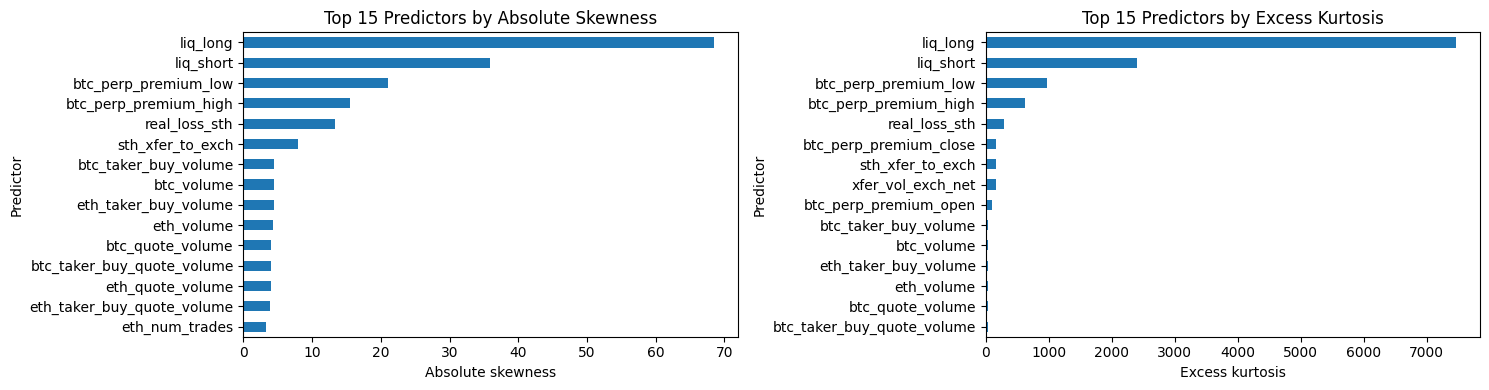

In [39]:
# Predictors with the most extreme skewness and kurtosis
n_show = 15
skew_plot = X_train_diag["skewness"].abs().nlargest(n_show).sort_values()
kurt_plot = X_train_diag["excess_kurtosis"].nlargest(n_show).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

skew_plot.plot(kind="barh", ax=axes[0])
axes[0].set_title(f"Top {n_show} Predictors by Absolute Skewness")
axes[0].set_xlabel("Absolute skewness")
axes[0].set_ylabel("Predictor")

kurt_plot.plot(kind="barh", ax=axes[1])
axes[1].set_title(f"Top {n_show} Predictors by Excess Kurtosis")
axes[1].set_xlabel("Excess kurtosis")
axes[1].set_ylabel("Predictor")

plt.tight_layout()
plt.show()

The results confirm that several raw predictors are strongly asymmetric and heavy-tailed. Liquidation variables show the most extreme skewness and excess kurtosis, reflecting long periods of limited activity interrupted by a small number of severe market events.

Premium-index variables also exhibit pronounced tail behaviour during basis dislocations. These features may therefore act more as event or regime indicators than stable continuous signals and will require appropriate transformations, such as `log1p` or signed-log scaling, before modelling.


**d) Zero-Inflated and Event-Driven Variables**

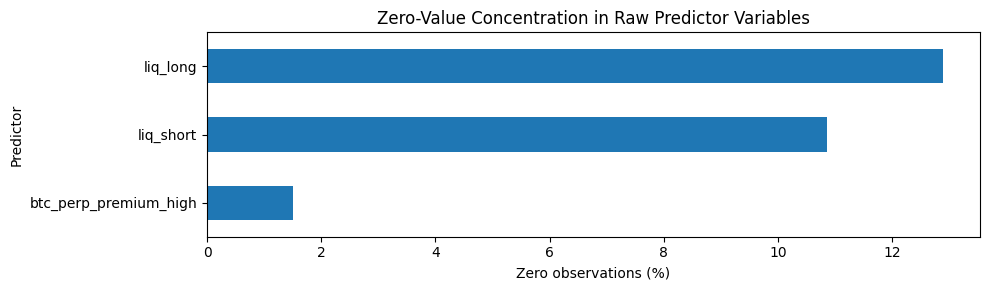

In [40]:
# Predictors with a material concentration of zero values
zero_threshold = 1.0
zero_plot = X_train_diag.loc[X_train_diag["zero_pct"] >= zero_threshold, "zero_pct"].sort_values()

if zero_plot.empty:
    print(f"No raw predictors have zero values in at least {zero_threshold:.0f}% of observed rows.")
else:
    plt.figure(figsize=(10, max(3, len(zero_plot) * 0.35)))
    zero_plot.plot(kind="barh")
    plt.title("Zero-Value Concentration in Raw Predictor Variables")
    plt.xlabel("Zero observations (%)")
    plt.ylabel("Predictor")
    plt.tight_layout()
    plt.show()

The chart confirms that liquidation variables are zero-inflated and episodic: many hours record no activity, while non-zero observations capture discrete stress events. Feature engineering should therefore consider both a transformed liquidation magnitude and a binary event indicator. The much smaller zero concentration in the premium-index high is less material.


**e) Target Variable Analysis Across Candidate Horizons**

Six candidate forecast horizons of 1, 4, 6, 8, 12 and 24 hours are retained because the appropriate prediction horizon has not yet been established. Short horizons provide more frequent trading opportunities but may be dominated by noise and transaction cost challenges, while longer horizons may offer greater return dispersion at the expense of slower signals and more overlap between observations. The target distributions are therefore compared before selecting a final horizon.

For each horizon, the forward log return is converted into a binary direction target, with positive returns assigned to class 1 and zero or negative returns to class 0.

Class balance is assessed separately because it may vary across horizons and influence model training and evaluation. The final horizon will be selected later using training-sample signal strength and stability, including IC and IC/IR evidence.


In [41]:
# Candidate target distributions and class balance
target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]

target_data = targets_train[target_cols]
target_summary = target_data.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

target_summary["negative_count"] = target_data.le(0).sum()
target_summary["positive_count"] = target_data.gt(0).sum()
target_summary["positive_pct"] = target_data.gt(0).sum().div(target_data.notna().sum()).mul(100)
target_summary["negative_pct"] = target_data.le(0).sum().div(target_data.notna().sum()).mul(100)

target_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,negative_count,positive_count,positive_pct,negative_pct
fwd_logret_1h,"45,537.0000",0.0001,0.0070,-0.2071,-0.0207,-0.0095,-0.0024,0.0001,0.0026,0.0097,0.0200,0.1508,22351,23186,50.9168,49.0832
fwd_logret_4h,"45,537.0000",0.0002,0.0138,-0.3593,-0.0409,-0.0201,-0.0047,0.0002,0.0052,0.0205,0.0401,0.1867,22190,23347,51.2704,48.7296
fwd_logret_6h,"45,537.0000",0.0003,0.0167,-0.3956,-0.0490,-0.0247,-0.0058,0.0003,0.0067,0.0253,0.0479,0.2797,22143,23394,51.3736,48.6264
fwd_logret_8h,"45,537.0000",0.0004,0.0192,-0.4083,-0.0564,-0.0284,-0.0068,0.0004,0.0079,0.0296,0.0557,0.3178,22035,23502,51.6108,48.3892
fwd_logret_12h,"45,537.0000",0.0006,0.0234,-0.3880,-0.0687,-0.0350,-0.0087,0.0005,0.0102,0.0367,0.0672,0.3204,21972,23565,51.7491,48.2509
fwd_logret_24h,"45,537.0000",0.0013,0.0337,-0.6416,-0.0968,-0.0499,-0.0132,0.0011,0.0163,0.0533,0.0936,0.2993,21581,23956,52.6078,47.3922


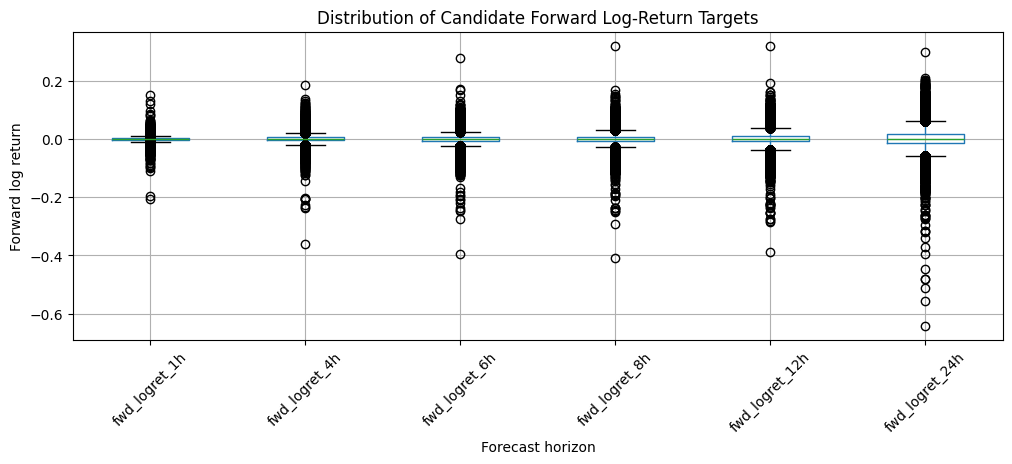

In [42]:
# Boxplots of candidate forward log-return targets
ax = target_data.boxplot(figsize=(12, 4), showfliers=True)

ax.set_title("Distribution of Candidate Forward Log-Return Targets")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Forward log return")

plt.xticks(rotation=45)
plt.show()

The forward-return distributions remain centred close to zero across all six horizons, while both the interquartile range and the magnitude of extreme observations increase with the forecast horizon. The 24-hour target shows the widest dispersion and the largest downside extremes. This confirms that longer horizons capture larger cumulative price movements, although tail asymmetry should be assessed from the accompanying quantiles, skewness and extrema rather than from the boxplots alone.

**f) Temporal Behaviour and Regime Variation**

Financial time series are not stationary across the full sample and often alternate between calm, trending and stressed market regimes. The following analysis examines how BTC returns, realised volatility and selected market indicators evolve through time, rather than relying only on full-sample summary statistics. These charts help identify volatility clustering, structural changes and episodic dislocations that may motivate rolling, normalised or regime-sensitive features during feature engineering.

i) BTC Rolling 24-Hour Log Return and Realised Volatility

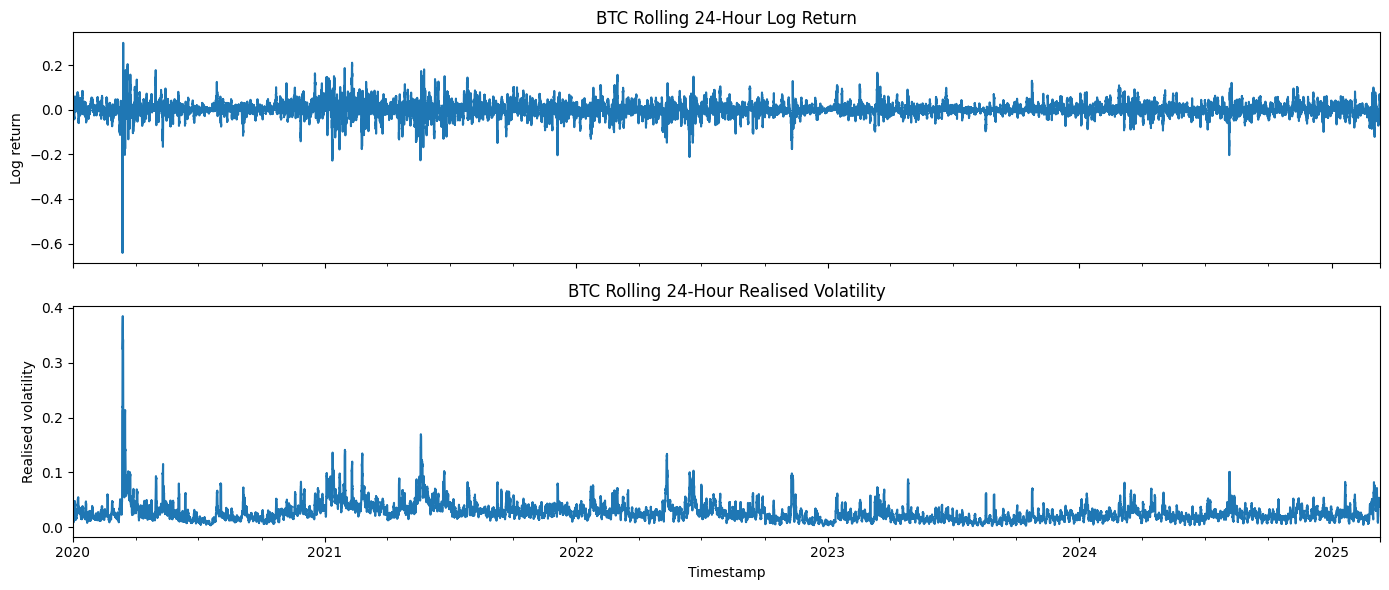

In [43]:
# BTC rolling 24-hour return and realised volatility
temporal_df = X_train.set_index("timestamp").copy()

temporal_df["btc_logret_1h"] = np.log(temporal_df["btc_close"] / temporal_df["btc_close"].shift(1))
temporal_df["btc_logret_24h"] = temporal_df["btc_logret_1h"].rolling(24).sum()
temporal_df["btc_realised_vol_24h"] = np.sqrt(temporal_df["btc_logret_1h"].pow(2).rolling(24).sum())
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

temporal_df["btc_logret_24h"].plot(ax=axes[0])
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("BTC Rolling 24-Hour Log Return")
axes[0].set_ylabel("Log return")

temporal_df["btc_realised_vol_24h"].plot(ax=axes[1])
axes[1].set_title("BTC Rolling 24-Hour Realised Volatility")
axes[1].set_ylabel("Realised volatility")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

The rolling series show clear volatility clustering: high-volatility periods coincide with a wider range of positive and negative 24-hour returns, while calmer periods remain closer to zero.

The relationship is not exact because realised volatility measures total intraday variation, whereas the 24-hour log return captures only the net directional move. This supports the use of volatility and regime-sensitive features in feature engineering.

ii) BTC Perpetual Premium and Funding at 8-Hour Settlement Intervals

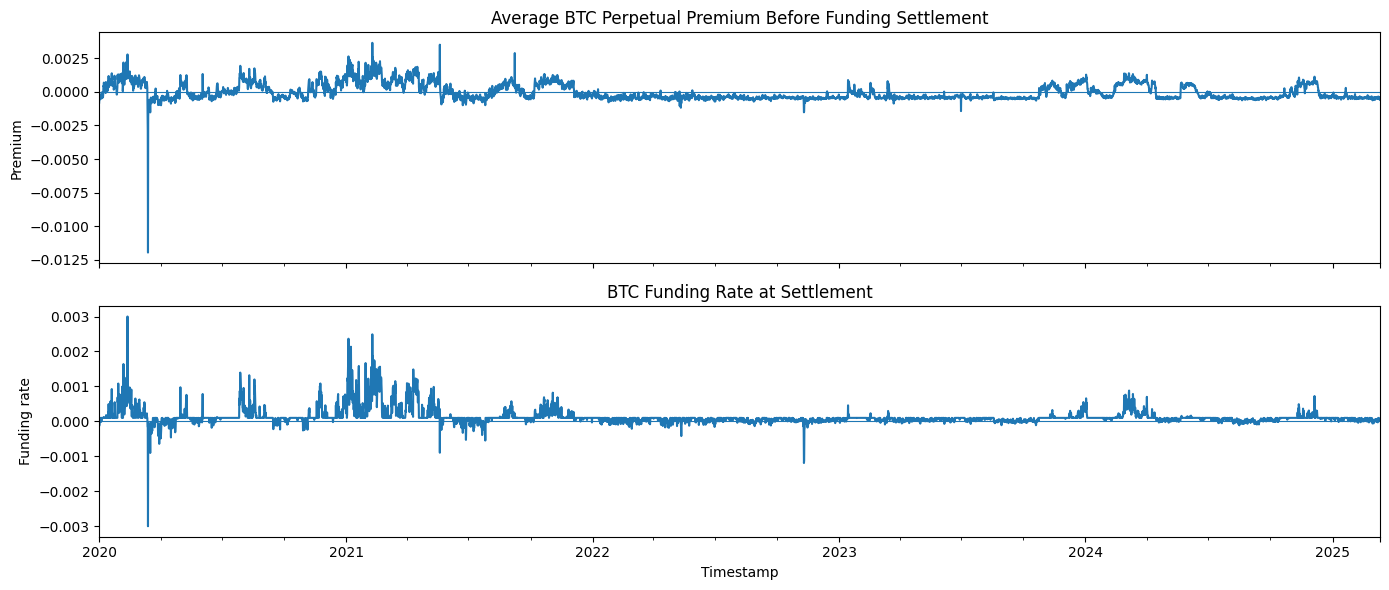

In [44]:
# BTC perpetual premium and funding at 8-hour settlement intervals
premium_funding_8h = temporal_df[["btc_perp_premium_close", "btc_funding"]].resample("8h", origin="start_day", closed="right", label="right").agg({
    "btc_perp_premium_close": "mean",
    "btc_funding": "last"})

premium_funding_8h = premium_funding_8h.dropna(subset=["btc_funding"])
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

premium_funding_8h["btc_perp_premium_close"].plot(ax=axes[0])
axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("Average BTC Perpetual Premium Before Funding Settlement")
axes[0].set_ylabel("Premium")

premium_funding_8h["btc_funding"].plot(ax=axes[1])
axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("BTC Funding Rate at Settlement")
axes[1].set_ylabel("Funding rate")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

The 8-hour aggregation shows that perpetual premium and funding generally move in the same direction, consistent with funding responding to persistent deviations between perpetual and spot prices. Large positive values may indicate crowded long positioning, while large negative values may reflect bearish pressure and deleveraging stress. Extreme joint movements are therefore potential indicators of market stress.

iii) Rolling Standardised Open Interest and Leverage Ratio

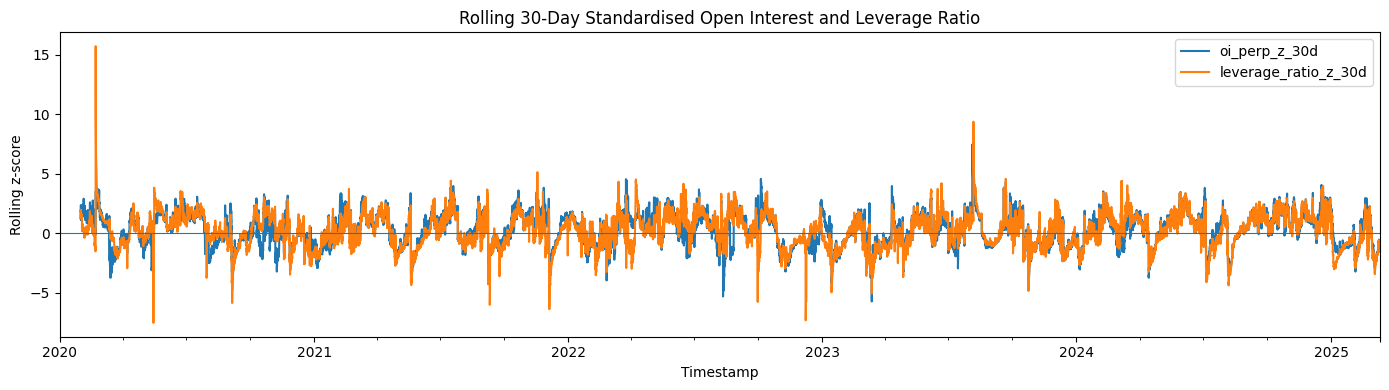

In [45]:
# Rolling 30-day standardisation of open interest and leverage ratio
rolling_window = 24 * 30

oi_mean = temporal_df["oi_perp"].rolling(rolling_window, min_periods=rolling_window).mean()
oi_std = temporal_df["oi_perp"].rolling(rolling_window, min_periods=rolling_window).std()

lev_mean = temporal_df["leverage_ratio"].rolling(rolling_window, min_periods=rolling_window).mean()
lev_std = temporal_df["leverage_ratio"].rolling(rolling_window, min_periods=rolling_window).std()

temporal_df["oi_perp_z_30d"] = (temporal_df["oi_perp"] - oi_mean) / oi_std
temporal_df["leverage_ratio_z_30d"] = (temporal_df["leverage_ratio"] - lev_mean) / lev_std

ax = temporal_df[["oi_perp_z_30d", "leverage_ratio_z_30d"]].plot(figsize=(14, 4))

ax.axhline(0, linewidth=0.8)
ax.set_title("Rolling 30-Day Standardised Open Interest and Leverage Ratio")
ax.set_ylabel("Rolling z-score")
ax.set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

The rolling 30-day standardisation places open interest and the estimated leverage ratio on a common scale and shows broadly similar temporal behaviour. Temporary divergences suggest that changes in open interest do not always correspond to equivalent changes in leverage intensity. Both measures will therefore remain candidates for feature engineering, subject to later redundancy and VIF checks.

Not all predictors were plotted because some raw levels are not directly comparable or produce visually uninformative time-series charts. These variables will be evaluated during feature engineering after applying suitable transformations, including log scaling, changes, returns, rolling standardisation and relative spreads. This allows their behaviour to be assessed in a more comparable and economically meaningful form.

**Part II — Deribit Futures Panel EDA**

Deribit data are handled separately at both the raw-data preparation and EDA stages because the extracted futures data are structured as a contract-level panel. At each timestamp, multiple instruments with different expiry dates coexist.

Directly merging individual Deribit contracts into the hourly predictor matrix would therefore create a changing and non-stationary feature space. A column representing a specific contract would exist only during that contract’s trading life, while its economic meaning would change continuously as time to expiry declines.

This section analyses the Deribit data as a changing contract-level panel rather than as a conventional fixed-dimensional hourly dataset.

The purpose of this section is to -
understand panel coverage and contract turnover;

*   examine maturity and liquidity structure
*   identify roll and expiry effect
*   assess the futures curve
*   determine how to convert the panel into fixed-dimensional, point-in-time features

a) **Contract Maturity and Roll Behaviour**

Deribit futures are analysed separately using only the saved training-period contract panel. This subsection verifies the panel structure and calculates the remaining time to expiry for dated futures. The perpetual contract is identified separately because it has no fixed maturity.

i) Load Deribit Data Panel

In [47]:
# Load Deribit training panel for EDA
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"; os.chdir(data_dir)

deribit_train_panel = pd.read_csv("deribit_train_panel.csv", parse_dates=["timestamp", "expiration_timestamp"])
deribit_train_panel["timestamp"] = pd.to_datetime(deribit_train_panel["timestamp"], utc=True, errors="coerce")
deribit_train_panel["expiration_timestamp"] = pd.to_datetime(deribit_train_panel["expiration_timestamp"], utc=True, errors="coerce")
deribit_train_panel = deribit_train_panel.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

deribit_train_panel["is_perpetual"] = deribit_train_panel["instrument_name"].str.contains("PERPETUAL", case=False, na=False)
deribit_train_panel["observation_timestamp"] = deribit_train_panel["timestamp"] - pd.Timedelta(hours=1)
deribit_train_panel["days_to_expiry"] = (deribit_train_panel["expiration_timestamp"] - deribit_train_panel["observation_timestamp"]).dt.total_seconds() / 86400

dated_mask = ~deribit_train_panel["is_perpetual"]

assert deribit_train_panel["timestamp"].notna().all()
assert not deribit_train_panel.duplicated(["timestamp", "instrument_name"]).any()
assert deribit_train_panel.loc[dated_mask, "expiration_timestamp"].notna().all()
assert deribit_train_panel.loc[dated_mask, "days_to_expiry"].ge(0).all()

print("Deribit training shape:", deribit_train_panel.shape)
print("Training period:", deribit_train_panel["timestamp"].min(), "to", deribit_train_panel["timestamp"].max())
print("Instruments:", deribit_train_panel["instrument_name"].nunique())
print("Perpetual rows:", deribit_train_panel["is_perpetual"].sum())
print("Dated futures rows:", dated_mask.sum())
print("Minimum dated time to expiry:", deribit_train_panel.loc[dated_mask, "days_to_expiry"].min())

deribit_train_panel.head()

Deribit training shape: (214352, 16)
Training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Instruments: 25
Perpetual rows: 45537
Dated futures rows: 168815
Minimum dated time to expiry: 0.0


,timestamp_ms,open,high,low,close,volume,cost,instrument_name,instrument_family,settlement_period,expiration_timestamp_ms,expiration_timestamp,timestamp,is_perpetual,observation_timestamp,days_to_expiry
0,1577833200000,"7,440.5000","7,447.5000","7,426.5000","7,433.0000",9.9284,"73,830.0000",BTC-26JUN20,quarterly,month,"1,593,158,400,000.0000",2020-06-26 08:00:00+00:00,2020-01-01 00:00:00+00:00,False,2019-12-31 23:00:00+00:00,177.3750
1,1577833200000,"7,292.0000","7,292.0000","7,274.0000","7,280.0000",26.5040,"193,000.0000",BTC-27MAR20,quarterly,month,"1,585,296,000,000.0000",2020-03-27 08:00:00+00:00,2020-01-01 00:00:00+00:00,False,2019-12-31 23:00:00+00:00,86.3750
2,1577833200000,"7,178.5000","7,186.0000","7,164.0000","7,169.5000",301.1300,"2,161,100.0000",BTC-PERPETUAL,perpetual,perpetual,NaN,NaT,2020-01-01 00:00:00+00:00,True,2019-12-31 23:00:00+00:00,NaN
3,1577836800000,"7,433.0000","7,433.0000","7,414.0000","7,418.5000",9.6024,"71,270.0000",BTC-26JUN20,quarterly,month,"1,593,158,400,000.0000",2020-06-26 08:00:00+00:00,2020-01-01 01:00:00+00:00,False,2020-01-01 00:00:00+00:00,177.3333
4,1577836800000,"7,277.0000","7,277.0000","7,265.5000","7,265.5000",17.7270,"128,870.0000",BTC-27MAR20,quarterly,month,"1,585,296,000,000.0000",2020-03-27 08:00:00+00:00,2020-01-01 01:00:00+00:00,False,2020-01-01 00:00:00+00:00,86.3333


The Deribit panel contains one perpetual contract and a changing set of dated futures. The following summary examines the number of active contracts available at each timestamp and the maturity range represented by the dated contracts.

ii) Summarize active contracts and maturity coverage by timestamp

In [48]:
# Summarise active contracts and maturity coverage by timestamp
deribit_maturity_summary = deribit_train_panel.groupby("timestamp").agg(
    active_contracts=("instrument_name", "nunique"),
    active_perpetuals=("is_perpetual", "sum"),
    active_dated_futures=("is_perpetual", lambda x: (~x).sum()),
    min_days_to_expiry=("days_to_expiry", "min"),
    max_days_to_expiry=("days_to_expiry", "max"))

deribit_maturity_summary.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).round(2)

,active_contracts,active_perpetuals,active_dated_futures,min_days_to_expiry,max_days_to_expiry
count,"45,537.0000","45,537.0000","45,537.0000","45,537.0000","45,537.0000"
mean,4.7100,1.0000,3.7100,45.9000,292.9900
std,0.5600,0.0000,0.5600,26.2600,55.3400
min,3.0000,1.0000,2.0000,0.0000,116.0400
1%,3.0000,1.0000,2.0000,0.9200,135.0100
25%,5.0000,1.0000,4.0000,23.3300,273.5400
50%,5.0000,1.0000,4.0000,45.9200,304.9600
75%,5.0000,1.0000,4.0000,68.5000,334.5800
99%,5.0000,1.0000,4.0000,90.7100,366.2800
max,6.0000,1.0000,5.0000,97.9600,371.0000


The Deribit training panel provides sufficient maturity depth for term-structure analysis, but the available contract set changes through time. A typical timestamp contains five instruments: one perpetual and four dated futures, with dated-contract coverage ranging from two to five. This confirms that individual contract names cannot be merged directly into the modelling matrix as a fixed feature set.

The nearest dated contract has a median time to expiry of about 46 days, while the longest available maturity is typically around 305 days. The panel therefore spans the front of the curve to roughly one year and is suitable for constructing stable, roll-aware term-structure features.

iii) Identify the Front Dated Future and Contract Roll Dates

In [49]:
# Identify the front dated future and contract roll dates
deribit_dated = deribit_train_panel.loc[~deribit_train_panel["is_perpetual"]].copy()
deribit_dated = deribit_dated.sort_values(["timestamp", "days_to_expiry", "instrument_name"])

deribit_front = deribit_dated.groupby("timestamp", as_index=False).first()
deribit_front = deribit_front[["timestamp", "instrument_name", "days_to_expiry", "close", "volume", "cost"]]

deribit_front["previous_instrument"] = deribit_front["instrument_name"].shift()
deribit_front["is_roll"] = deribit_front["instrument_name"].ne(deribit_front["previous_instrument"])
deribit_front.loc[deribit_front.index[0], "is_roll"] = False

deribit_rolls = deribit_front.loc[
    deribit_front["is_roll"],
    ["timestamp", "previous_instrument", "instrument_name", "days_to_expiry"]
].reset_index(drop=True)

roll_spacing_days = deribit_rolls["timestamp"].diff().dt.total_seconds().div(86400)

print("Front-contract observations:", len(deribit_front))
print("Front-contract changes:", len(deribit_rolls))
print("Median days between rolls:", roll_spacing_days.median())

deribit_rolls

Front-contract observations: 45537
Front-contract changes: 20
Median days between rolls: 91.0


,timestamp,previous_instrument,instrument_name,days_to_expiry
0,2020-03-27 10:00:00+00:00,BTC-27MAR20,BTC-26JUN20,90.9583
1,2020-06-26 10:00:00+00:00,BTC-26JUN20,BTC-25SEP20,90.9583
2,2020-09-25 10:00:00+00:00,BTC-25SEP20,BTC-25DEC20,90.9583
3,2020-12-25 10:00:00+00:00,BTC-25DEC20,BTC-26MAR21,90.9583
4,2021-03-26 10:00:00+00:00,BTC-26MAR21,BTC-25JUN21,90.9583
5,2021-06-25 10:00:00+00:00,BTC-25JUN21,BTC-24SEP21,90.9583
6,2021-09-24 10:00:00+00:00,BTC-24SEP21,BTC-31DEC21,97.9583
7,2021-12-31 10:00:00+00:00,BTC-31DEC21,BTC-25MAR22,83.9583
8,2022-03-25 10:00:00+00:00,BTC-25MAR22,BTC-24JUN22,90.9583
9,2022-06-24 10:00:00+00:00,BTC-24JUN22,BTC-30SEP22,97.9583


This analysis identifies the nearest-to-expiry dated future at each timestamp and records when that contract changes. It illustrates the roll behaviour of the front contract and confirms that a continuous front-futures series must be constructed explicitly rather than linked by fixed instrument name.

**b) Liquidity and Data Reliability**

This subsection assesses whether the Deribit contracts are sufficiently active and reliable for feature construction. Because the panel includes traded volume and cost but not bid–ask spreads or open interest, the analysis focuses on:

- missing, zero or negative trading activity
- unchanged hourly candles as a sign of inactivity
- differences in activity between perpetual and dated futures
- whether liquidity declines materially for longer maturities
- whether thin observations should be excluded or down-weighted

i) Compares structural liquidity characteristics for perpetual and dated futures

In [50]:
# Summarise trading activity and inactive observations
deribit_train_panel["contract_type"] = np.where(deribit_train_panel["is_perpetual"], "Perpetual", "Dated futures")
deribit_train_panel["zero_volume"] = deribit_train_panel["volume"].eq(0)
deribit_train_panel["zero_cost"] = deribit_train_panel["cost"].eq(0)
deribit_train_panel["negative_volume"] = deribit_train_panel["volume"].lt(0)
deribit_train_panel["negative_cost"] = deribit_train_panel["cost"].lt(0)
deribit_train_panel["flat_candle"] = deribit_train_panel[["open", "high", "low", "close"]].nunique(axis=1).eq(1)

deribit_liquidity_summary = deribit_train_panel.groupby("contract_type").agg(
    observations=("instrument_name", "size"),
    instruments=("instrument_name", "nunique"),
    missing_volume=("volume", lambda x: x.isna().sum()),
    missing_cost=("cost", lambda x: x.isna().sum()),
    negative_volume=("negative_volume", "sum"),
    negative_cost=("negative_cost", "sum"),
    zero_volume_pct=("zero_volume", "mean"),
    zero_cost_pct=("zero_cost", "mean"),
    flat_candle_pct=("flat_candle", "mean"),
    median_volume=("volume", "median"),
    median_cost=("cost", "median"),
    mean_cost=("cost", "mean"))

pct_cols = ["zero_volume_pct", "zero_cost_pct", "flat_candle_pct"]
deribit_liquidity_summary[pct_cols] = deribit_liquidity_summary[pct_cols].mul(100)

deribit_liquidity_summary.round(2)

,observations,instruments,missing_volume,missing_cost,negative_volume,negative_cost,zero_volume_pct,zero_cost_pct,flat_candle_pct,median_volume,median_cost,mean_cost
contract_type,,,,,,,,,,,,
Dated futures,168815,24,0,0,0,0,3.6800,3.6800,6.3400,4.8800,"180,940.0000","803,456.0500"
Perpetual,45537,1,0,0,0,0,0.0100,0.0100,0.0200,370.0700,"11,787,750.0000","21,431,112.8100"


The Deribit panel contains no missing or negative volume and cost observations. The perpetual contract is highly active, with almost no zero-activity or flat-candle observations, while dated futures are less liquid, with about 3.7% zero-volume observations and 6.3% flat candles. Dated contracts remain usable for term-structure analysis, but their uneven activity supports liquidity screening or weighting during feature construction.

The next analysis groups dated futures by time to expiry to assess whether liquidity deteriorates materially at longer maturities.

ii) Compare dated-futures liquidity across maturity buckets

In [51]:
# Compare dated-futures liquidity across maturity buckets
maturity_bins = [0, 30, 90, 180, np.inf]
maturity_labels = ["0–30 days", "31–90 days", "91–180 days", "181+ days"]

deribit_dated["maturity_bucket"] = pd.cut(
    deribit_dated["days_to_expiry"],
    bins=maturity_bins,
    labels=maturity_labels,
    include_lowest=True
)

deribit_dated["zero_volume"] = deribit_dated["volume"].eq(0)
deribit_dated["zero_cost"] = deribit_dated["cost"].eq(0)
deribit_dated["flat_candle"] = deribit_dated[["open", "high", "low", "close"]].nunique(axis=1).eq(1)

deribit_maturity_liquidity = deribit_dated.groupby("maturity_bucket", observed=True).agg(
    observations=("instrument_name", "size"),
    median_volume=("volume", "median"),
    median_cost=("cost", "median"),
    mean_cost=("cost", "mean"),
    zero_volume_pct=("zero_volume", "mean"),
    zero_cost_pct=("zero_cost", "mean"),
    flat_candle_pct=("flat_candle", "mean"))

pct_cols = ["zero_volume_pct", "zero_cost_pct", "flat_candle_pct"]
deribit_maturity_liquidity[pct_cols] = deribit_maturity_liquidity[pct_cols].mul(100)

deribit_maturity_liquidity.round(2)

,observations,median_volume,median_cost,mean_cost,zero_volume_pct,zero_cost_pct,flat_candle_pct
maturity_bucket,,,,,,,
0–30 days,14756,30.8100,"977,285.0000","2,159,923.8200",0.2000,0.2000,0.2400
31–90 days,30153,21.1600,"683,780.0000","1,664,919.4800",0.1000,0.1000,0.2500
91–180 days,44889,8.5400,"287,240.0000","765,148.8900",0.5100,0.5100,1.1900
181+ days,79017,1.0600,"41,730.0000","243,169.3500",7.4900,7.4900,12.7400


Dated-futures liquidity declines clearly with maturity. Contracts within 90 days of expiry are highly active, while activity weakens between 91 and 180 days. Beyond 180 days, liquidity is materially thinner, with about 7.5% zero-volume observations and 12.7% flat candles. Far-dated contracts should therefore be filtered, down-weighted or used selectively in term-structure features.

**c) Futures Basis and Term-Structure Behaviour**

This subsection converts dated-futures prices into maturity-comparable term-structure measures. Each contract is compared with BTC spot to calculate percentage basis, which is then annualised by remaining time to expiry. Observations with one day or less to expiry are excluded from annualisation because the scaling becomes unstable near settlement.

i) Construct the Front Futures Curve Slope

In [59]:
# Rebuild dated-futures basis and construct the front futures curve slope
btc_spot = X_train[["timestamp", "btc_close"]].copy()
btc_spot["timestamp"] = pd.to_datetime(btc_spot["timestamp"], utc=True)
btc_spot = btc_spot.rename(columns={"timestamp": "observation_timestamp"})

deribit_basis = deribit_dated.merge(btc_spot, on="observation_timestamp", how="left", validate="many_to_one")
deribit_basis = deribit_basis.dropna(subset=["btc_close"]).copy()
deribit_basis["basis_pct"] = 100 * (deribit_basis["close"] / deribit_basis["btc_close"] - 1)

curve_cols = ["timestamp", "instrument_name", "days_to_expiry", "basis_pct"]
curve_ranked = deribit_basis[curve_cols].sort_values(["timestamp", "days_to_expiry", "instrument_name"]).copy()
curve_ranked["maturity_rank"] = curve_ranked.groupby("timestamp").cumcount() + 1
curve_ranked = curve_ranked.loc[curve_ranked["maturity_rank"].le(2)].copy()

front_contract = curve_ranked.loc[curve_ranked["maturity_rank"].eq(1), curve_cols].copy()
second_contract = curve_ranked.loc[curve_ranked["maturity_rank"].eq(2), curve_cols].copy()

front_contract = front_contract.rename(columns={"instrument_name": "front_instrument", "days_to_expiry": "front_days", "basis_pct": "front_basis_pct"})
second_contract = second_contract.rename(columns={"instrument_name": "second_instrument", "days_to_expiry": "second_days", "basis_pct": "second_basis_pct"})

front_curve = front_contract.merge(second_contract, on="timestamp", how="inner", validate="one_to_one")
front_curve["curve_slope_pct"] = front_curve["second_basis_pct"] - front_curve["front_basis_pct"]
front_curve["curve_state"] = np.where(front_curve["curve_slope_pct"].ge(0), "Upward sloping", "Inverted")

front_curve_summary = pd.Series({
    "observations": len(front_curve),
    "median_front_basis_pct": front_curve["front_basis_pct"].median(),
    "median_second_basis_pct": front_curve["second_basis_pct"].median(),
    "median_curve_slope_pct": front_curve["curve_slope_pct"].median(),
    "upward_sloping_pct": 100 * front_curve["curve_state"].eq("Upward sloping").mean(),
    "inverted_pct": 100 * front_curve["curve_state"].eq("Inverted").mean()
})

front_curve_summary.to_frame("value").T.round(2)

,observations,median_front_basis_pct,median_second_basis_pct,median_curve_slope_pct,upward_sloping_pct,inverted_pct
value,"45,536.0000",0.7700,2.7900,1.8500,96.3800,3.6200


The front futures curve is upward sloping in 96.4% of training observations and inverted in only 3.6%. The median basis rises from 0.77% for the nearest contract to 2.79% for the second contract, producing a median curve slope of 1.85 percentage points. Inversion is therefore an uncommon regime that may be more informative than the normal upward-sloping state and should be retained as a candidate stress indicator.

**d) Implications for Deribit Feature Engineering**

The Deribit EDA confirms that individual contract prices should not be used directly as predictors because the active contract set changes through time and the front contract rolls periodically. The panel should instead be converted into a fixed set of roll-aware, point-in-time features.

Liquidity is concentrated in the perpetual and nearer-dated futures, while contracts beyond 180 days are materially thinner. Feature construction should therefore prioritise the perpetual, front and intermediate sections of the curve, with far-dated contracts excluded, screened or liquidity-weighted.

The basis results support candidate features including front-contract basis, annualised front basis, front-curve slope, curve inversion indicators, changes in curve slope and front-contract days to expiry. Perpetual trading activity may also provide continuous liquidity and positioning measures.

All Deribit features will be constructed from contracts available at each timestamp using deribit_train_panel, with unstable near-expiry annualisation excluded and extreme basis or slope changes reviewed during feature engineering before alignment with the hourly training matrix.

**Part III) Insights from the EDA process**

The training-only EDA identified substantial variation in scale, distribution, sparsity and temporal behaviour across the predictor set. Raw levels were therefore retained only where economically interpretable, while most variables will enter the modelling matrix through returns, changes, rolling standardisation, relative spreads or event indicators. Deribit contracts will be converted into fixed roll-aware term-structure features rather than merged by instrument name. The next stage constructs the compact v2 feature matrix, after which correlation, IC/IR, multicollinearity, stability and model-based feature selection will be assessed using training data only.

## **(V) Feature Engineering & Prediction Horizon Selection**

## **Part 1 - Feature Engineering**

The feature-engineering stage converts the cleaned training inputs into a compact set of predictors designed to capture short-horizon BTC price dynamics, volatility, market positioning, liquidity, derivatives structure, on-chain behaviour and broader risk conditions.

The candidate set is intentionally selective rather than exhaustive. Simple returns are retained only where they provide a necessary short-horizon reference, while greater emphasis is placed on rolling slopes, trend quality, acceleration, volatility asymmetry, regime indicators and relative-value measures. This reflects both the earlier exploratory results and prior modelling experience, where large collections of conventional return and technical features did not consistently improve predictive performance or stability.

Most directional features are concentrated around 1-hour, 4-hour, 8-hour and 24-hour windows, in order to capture short term, nuances around funding windows and a slightly longer duration benchmark/ daily reference. Longer windows are used mainly for estimating regimes or standardising variables, rather than as direct momentum signals.

Several features are also designed to capture nonlinear market states that may not be adequately represented by continuous variables alone. These include extreme drawdowns, unusually large premium–funding dislocations and exceptional trading activity. Such indicators are intended to identify stressed or crowded conditions that market participants commonly monitor.

Deribit futures are treated separately because the active contract set changes through time. Individual contract names therefore cannot be used as fixed model columns. Instead, the contract panel is converted into roll-aware measures of basis, curve slope, maturity, participation and liquidity before being aligned with the common hourly modelling index.

The initial candidate registry contains 95 features. These features will first be constructed and audited in full. Only after the complete matrix has passed alignment, missing-value, leakage and stability checks will the six candidate forecast horizons be compared using training-only IC/IR analysis. The selected horizon will then be examined for class balance and the possible need for a near-zero return exclusion band before the L2 logistic-regression baseline and subsequent feature-selection stages are run.

The six candidate forecast horizons—1, 4, 6, 8, 12 and 24 hours—will be compared using training-only IC/IR analysis after the complete feature matrix has been constructed and validated.


In [65]:
# Load training inputs for v2 feature engineering
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_TRAIN_PATH = DATA_PATH / "X_train_1h.csv"
TARGETS_TRAIN_PATH = DATA_PATH / "targets_train_1h.csv"
DERIBIT_TRAIN_PATH = DATA_PATH / "deribit_train_panel.csv"

for path in [X_TRAIN_PATH, TARGETS_TRAIN_PATH, DERIBIT_TRAIN_PATH]:
    assert path.exists(), f"Missing file: {path}"

X_train = pd.read_csv(X_TRAIN_PATH, index_col="timestamp", parse_dates=["timestamp"])
X_train.index = pd.to_datetime(X_train.index, utc=True)
X_train = X_train.sort_index()

targets_train = pd.read_csv(TARGETS_TRAIN_PATH, index_col="timestamp", parse_dates=["timestamp"])
targets_train.index = pd.to_datetime(targets_train.index, utc=True)
targets_train = targets_train.sort_index()

deribit_train_panel = pd.read_csv(DERIBIT_TRAIN_PATH)
deribit_train_panel = deribit_train_panel.drop(columns=deribit_train_panel.filter(regex=r"^Unnamed:").columns)
deribit_train_panel["timestamp"] = pd.to_datetime(deribit_train_panel["timestamp"], utc=True)
deribit_train_panel["expiration_timestamp"] = pd.to_datetime(deribit_train_panel["expiration_timestamp"], utc=True, errors="coerce")
deribit_train_panel = deribit_train_panel.sort_values(["timestamp", "instrument_name"]).reset_index(drop=True)

X_train_engineered = pd.DataFrame(index=X_train.index)

target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]
missing_target_cols = [col for col in target_cols if col not in targets_train.columns]

assert not X_train.index.has_duplicates, "Duplicate timestamps detected in X_train."
assert not targets_train.index.has_duplicates, "Duplicate timestamps detected in targets_train."
assert X_train.index.is_monotonic_increasing, "X_train is not sorted chronologically."
assert targets_train.index.is_monotonic_increasing, "targets_train is not sorted chronologically."
assert X_train.index.equals(targets_train.index), "X_train and targets_train timestamps are not aligned."
assert not missing_target_cols, f"Missing target columns: {missing_target_cols}"
assert not deribit_train_panel.duplicated(["timestamp", "instrument_name"]).any(), "Duplicate Deribit timestamp-instrument rows detected."
assert deribit_train_panel["timestamp"].notna().all(), "Invalid Deribit timestamps detected."
assert X_train_engineered.index.equals(X_train.index), "Engineered matrix index does not match X_train."

print(f"X_train shape: {X_train.shape}")
print(f"X_train period: {X_train.index.min()} to {X_train.index.max()}")
print(f"X_train duplicate timestamps: {X_train.index.duplicated().sum():,}")

print(f"\nTargets shape: {targets_train.shape}")
print(f"Targets period: {targets_train.index.min()} to {targets_train.index.max()}")
print(f"Candidate forward-return targets: {len(target_cols)}")
print(f"Feature-target timestamp alignment: {X_train.index.equals(targets_train.index)}")

print(f"\nDeribit training panel shape: {deribit_train_panel.shape}")
print(f"Deribit training period: {deribit_train_panel['timestamp'].min()} to {deribit_train_panel['timestamp'].max()}")
print(f"Deribit instruments: {deribit_train_panel['instrument_name'].nunique():,}")
print(f"Deribit unique timestamps: {deribit_train_panel['timestamp'].nunique():,}")

print(f"\nX_train_engineered initial shape: {X_train_engineered.shape}")
print("Candidate v2 feature registry locked: 95")

X_train shape: (45537, 48)
X_train period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
X_train duplicate timestamps: 0

Targets shape: (45537, 7)
Targets period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Candidate forward-return targets: 6
Feature-target timestamp alignment: True

Deribit training panel shape: (214352, 13)
Deribit training period: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Deribit instruments: 25
Deribit unique timestamps: 45,537

X_train_engineered initial shape: (45537, 0)
Candidate v2 feature registry locked: 95


### **a) BTC Price, Trend and Momentum**

Construction choices

- Slopes are measured as hourly changes in log price, so the 4h, 8h and 24h values are directly comparable.
- The slope t-statistics and R square are only calculated over 8h and 24h; four observations are too few for a useful trend-quality estimate.
- Acceleration compares consecutive non-overlapping return blocks:
i) latest 4h versus previous 4h;
ii) latest 8h versus previous 8h.

In [66]:
# a) BTC Price, Trend and Momentum

btc_close = pd.to_numeric(X_train["btc_close"], errors="coerce")
assert btc_close.notna().all() and btc_close.gt(0).all(), "Invalid BTC close values detected."

btc_log_price = np.log(btc_close)
btc_trend_features = pd.DataFrame(index=X_train.index)

# Simple log returns
btc_trend_features["btc_ret_1h"] = btc_log_price.diff(1)
btc_trend_features["btc_ret_4h"] = btc_log_price.diff(4)
btc_trend_features["btc_ret_24h"] = btc_log_price.diff(24)

# Rolling OLS statistics for equally spaced hourly observations
def rolling_logprice_regression(log_price, window):
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    sxx = np.sum((x - x_mean) ** 2)
    sum_y = log_price.rolling(window, min_periods=window).sum()
    sum_y2 = log_price.pow(2).rolling(window, min_periods=window).sum()
    sum_xy = log_price.rolling(window, min_periods=window).apply(lambda y: np.dot(y, x), raw=True)
    slope = (sum_xy - x_mean * sum_y) / sxx
    sst = sum_y2 - sum_y.pow(2) / window
    residual_ss = (sst - slope.pow(2) * sxx).clip(lower=0)
    slope_se = np.sqrt((residual_ss / (window - 2)) / sxx)
    slope_tstat = slope / slope_se.replace(0, np.nan)
    r2 = slope.pow(2) * sxx / sst.replace(0, np.nan)
    return slope, slope_tstat, r2

slope_4h, _, _ = rolling_logprice_regression(btc_log_price, 4)
slope_8h, slope_tstat_8h, trend_r2_8h = rolling_logprice_regression(btc_log_price, 8)
slope_24h, slope_tstat_24h, trend_r2_24h = rolling_logprice_regression(btc_log_price, 24)

# Trend direction, strength and path orderliness
btc_trend_features["btc_logprice_slope_4h"] = slope_4h
btc_trend_features["btc_logprice_slope_8h"] = slope_8h
btc_trend_features["btc_logprice_slope_24h"] = slope_24h
btc_trend_features["btc_slope_tstat_8h"] = slope_tstat_8h
btc_trend_features["btc_slope_tstat_24h"] = slope_tstat_24h
btc_trend_features["btc_trend_r2_8h"] = trend_r2_8h
btc_trend_features["btc_trend_r2_24h"] = trend_r2_24h

# Fast-versus-slow trend structure
btc_trend_features["btc_slope_spread_4h_24h"] = slope_4h - slope_24h
btc_trend_features["btc_slope_spread_8h_24h"] = slope_8h - slope_24h

# Return acceleration across consecutive non-overlapping blocks
btc_ret_8h = btc_log_price.diff(8)
btc_trend_features["btc_return_acceleration_4h"] = btc_trend_features["btc_ret_4h"] - btc_trend_features["btc_ret_4h"].shift(4)
btc_trend_features["btc_return_acceleration_8h"] = btc_ret_8h - btc_ret_8h.shift(8)

# Final family audit and merge
btc_trend_features = btc_trend_features.replace([np.inf, -np.inf], np.nan)

assert not btc_trend_features.columns.duplicated().any(), "Duplicate BTC trend feature names detected."
assert btc_trend_features["btc_trend_r2_8h"].dropna().between(0, 1).all()
assert btc_trend_features["btc_trend_r2_24h"].dropna().between(0, 1).all()

for feature in btc_trend_features:
    first_valid = btc_trend_features[feature].first_valid_index()

    if first_valid is not None:
        assert btc_trend_features.loc[first_valid:, feature].notna().all(), f"Internal missing values detected in {feature}."

X_train_engineered = X_train_engineered.join(btc_trend_features)

print(f"BTC price, trend and momentum features added: {btc_trend_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {btc_trend_features.isna().sum().max():,} rows")
print("Internal missing values after feature inception: 0")

display(pd.DataFrame({
    "first_valid": btc_trend_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": btc_trend_features.isna().sum()}))

BTC price, trend and momentum features added: 14
X_train_engineered shape: (45537, 14)
Longest warm-up: 24 rows
Internal missing values after feature inception: 0


,first_valid,warmup_rows
btc_ret_1h,2020-01-01 01:00:00+00:00,1
btc_ret_4h,2020-01-01 04:00:00+00:00,4
btc_ret_24h,2020-01-02 00:00:00+00:00,24
btc_logprice_slope_4h,2020-01-01 03:00:00+00:00,3
btc_logprice_slope_8h,2020-01-01 07:00:00+00:00,7
btc_logprice_slope_24h,2020-01-01 23:00:00+00:00,23
btc_slope_tstat_8h,2020-01-01 07:00:00+00:00,7
btc_slope_tstat_24h,2020-01-01 23:00:00+00:00,23
btc_trend_r2_8h,2020-01-01 07:00:00+00:00,7
btc_trend_r2_24h,2020-01-01 23:00:00+00:00,23


### **b) BTC Volatility, Asymmetry and Regimes**

In [76]:
# b) BTC Volatility, Asymmetry and Regimes
btc_volatility_features = pd.DataFrame(index=X_train.index)
btc_ret_1h = btc_trend_features["btc_ret_1h"]
btc_squared_return = btc_ret_1h.pow(2)
btc_downside_squared_return = btc_ret_1h.clip(upper=0).pow(2)

# Realised volatility
btc_volatility_features["btc_rv_4h"] = np.sqrt(btc_squared_return.rolling(4, min_periods=4).sum())
btc_volatility_features["btc_rv_8h"] = np.sqrt(btc_squared_return.rolling(8, min_periods=8).sum())
btc_volatility_features["btc_rv_24h"] = np.sqrt(btc_squared_return.rolling(24, min_periods=24).sum())

# Downside variance share
downside_share_8h = btc_downside_squared_return.rolling(8, min_periods=8).sum() / btc_squared_return.rolling(8, min_periods=8).sum().replace(0, np.nan)
downside_share_24h = btc_downside_squared_return.rolling(24, min_periods=24).sum() / btc_squared_return.rolling(24, min_periods=24).sum().replace(0, np.nan)

btc_volatility_features["btc_downside_variance_share_8h"] = downside_share_8h.clip(0, 1)
btc_volatility_features["btc_downside_variance_share_24h"] = downside_share_24h.clip(0, 1)

# Volatility instability
btc_volatility_features["btc_vol_of_vol_24h"] = btc_volatility_features["btc_rv_4h"].rolling(24, min_periods=24).std()

# Drawdown
btc_volatility_features["btc_drawdown_8h"] = btc_close / btc_close.rolling(8, min_periods=8).max() - 1
btc_volatility_features["btc_drawdown_24h"] = btc_close / btc_close.rolling(24, min_periods=24).max() - 1

drawdown_8h_threshold = btc_volatility_features["btc_drawdown_8h"].rolling(720, min_periods=168).quantile(0.05).shift(1)
drawdown_24h_threshold = btc_volatility_features["btc_drawdown_24h"].rolling(720, min_periods=168).quantile(0.05).shift(1)
drawdown_ready = drawdown_8h_threshold.notna() & drawdown_24h_threshold.notna()
drawdown_extreme = (btc_volatility_features["btc_drawdown_8h"] < drawdown_8h_threshold) | (btc_volatility_features["btc_drawdown_24h"] < drawdown_24h_threshold)

btc_volatility_features["btc_drawdown_extreme_flag"] = np.where(drawdown_ready, drawdown_extreme.astype(float), np.nan)

# Rolling Hurst exponent
hurst_window = 168
hurst_update_frequency = 24
hurst_scales = np.array([1, 2, 4, 8, 12, 24])

def estimate_hurst(return_window):
    log_scales = []
    log_variances = []

    for scale in hurst_scales:
        usable_length = len(return_window) // scale * scale

        if usable_length < scale * 5:
            continue

        aggregated_returns = return_window[-usable_length:].reshape(-1, scale).sum(axis=1)
        variance = np.var(aggregated_returns, ddof=1)

        if np.isfinite(variance) and variance > 0:
            log_scales.append(np.log(scale))
            log_variances.append(np.log(variance))

    if len(log_scales) < 3:
        return np.nan

    return np.polyfit(log_scales, log_variances, 1)[0] / 2

btc_hurst = pd.Series(np.nan, index=X_train.index, dtype=float)

for position in range(hurst_window, len(X_train), hurst_update_frequency):
    return_window = btc_ret_1h.iloc[position - hurst_window + 1:position + 1]

    if return_window.notna().sum() == hurst_window:
        btc_hurst.iloc[position] = estimate_hurst(return_window.to_numpy())

btc_volatility_features["btc_hurst_168h"] = btc_hurst.ffill()

# Causal EGARCH volatility
egarch_window = 4320
egarch_refit_frequency = 24
egarch_returns = 100 * btc_ret_1h
egarch_conditional_vol = pd.Series(np.nan, index=X_train.index, dtype=float)

for position in range(egarch_window, len(X_train), egarch_refit_frequency):
    estimation_start = position - egarch_window + 1
    segment_end = min(position + egarch_refit_frequency, len(X_train))

    estimation_sample = egarch_returns.iloc[estimation_start:position + 1].dropna()
    filtering_sample = egarch_returns.iloc[estimation_start:segment_end].dropna()

    if len(estimation_sample) != egarch_window:
        continue

    model = arch_model(estimation_sample, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
    fitted_model = model.fit(disp="off", show_warning=False)

    filtering_model = arch_model(filtering_sample, mean="Zero", vol="EGARCH", p=1, o=1, q=1, dist="t", rescale=False)
    filtered_model = filtering_model.fix(fitted_model.params)

    segment_index = X_train.index[position:segment_end]
    segment_volatility = filtered_model.conditional_volatility.reindex(segment_index) / 100
    egarch_conditional_vol.loc[segment_index] = segment_volatility

egarch_regime_mean = egarch_conditional_vol.rolling(720, min_periods=720).mean().shift(1)
egarch_regime_std = egarch_conditional_vol.rolling(720, min_periods=720).std().shift(1)

btc_volatility_features["btc_egarch_conditional_vol"] = egarch_conditional_vol
btc_volatility_features["btc_egarch_vol_regime"] = (egarch_conditional_vol - egarch_regime_mean) / egarch_regime_std.replace(0, np.nan)

# Family audit and merge
btc_volatility_features = btc_volatility_features.replace([np.inf, -np.inf], np.nan)

assert not btc_volatility_features.columns.duplicated().any(), "Duplicate BTC volatility feature names detected."
assert btc_volatility_features["btc_drawdown_extreme_flag"].dropna().isin([0, 1]).all(), "Invalid drawdown flag values."

for feature in btc_volatility_features:
    first_valid = btc_volatility_features[feature].first_valid_index()

    if first_valid is not None:
        assert btc_volatility_features.loc[first_valid:, feature].notna().all(), f"Internal missing values detected in {feature}."

X_train_engineered = X_train_engineered.join(btc_volatility_features)

print(f"BTC volatility, asymmetry and regime features added: {btc_volatility_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {btc_volatility_features.isna().sum().max():,} rows")
print("Internal missing values after feature inception: 0")

display(pd.DataFrame({
    "first_valid": btc_volatility_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": btc_volatility_features.isna().sum()}))

BTC volatility, asymmetry and regime features added: 12
X_train_engineered shape: (45537, 26)
Longest warm-up: 5,040 rows
Internal missing values after feature inception: 0


,first_valid,warmup_rows
btc_rv_4h,2020-01-01 04:00:00+00:00,4
btc_rv_8h,2020-01-01 08:00:00+00:00,8
btc_rv_24h,2020-01-02 00:00:00+00:00,24
btc_downside_variance_share_8h,2020-01-01 08:00:00+00:00,8
btc_downside_variance_share_24h,2020-01-02 00:00:00+00:00,24
btc_vol_of_vol_24h,2020-01-02 03:00:00+00:00,27
btc_drawdown_8h,2020-01-01 07:00:00+00:00,7
btc_drawdown_24h,2020-01-01 23:00:00+00:00,23
btc_drawdown_extreme_flag,2020-01-08 23:00:00+00:00,191
btc_hurst_168h,2020-01-08 00:00:00+00:00,168


### **c) Premium, Funding and CEX Microstructure**

In [79]:
# c) Premium, Funding and CEX Microstructure

required_cex_cols = ["btc_volume", "btc_taker_buy_volume", "btc_perp_premium_close", "btc_funding", "coinbase_btc_close"]
missing_cex_cols = [col for col in required_cex_cols if col not in X_train.columns]
if missing_cex_cols: raise KeyError(f"Missing required CEX columns: {missing_cex_cols}")

cex_microstructure_features = pd.DataFrame(index=X_train.index)

premium = pd.to_numeric(X_train["btc_perp_premium_close"], errors="coerce")
funding = pd.to_numeric(X_train["btc_funding"], errors="coerce").ffill()
btc_volume = pd.to_numeric(X_train["btc_volume"], errors="coerce")
btc_taker_buy_volume = pd.to_numeric(X_train["btc_taker_buy_volume"], errors="coerce")
coinbase_close = pd.to_numeric(X_train["coinbase_btc_close"], errors="coerce")

# Premium
premium_mean_168h = premium.rolling(168, min_periods=168).mean()
premium_std_168h = premium.rolling(168, min_periods=168).std()
premium_zscore_168h = (premium - premium_mean_168h) / premium_std_168h
premium_zscore_168h = premium_zscore_168h.mask(premium_std_168h.eq(0), 0)

cex_microstructure_features["premium_level"] = premium
cex_microstructure_features["premium_change_4h"] = premium.diff(4)
cex_microstructure_features["premium_zscore_168h"] = premium_zscore_168h

# Funding
funding_mean_168h = funding.rolling(168, min_periods=168).mean()
funding_std_168h = funding.rolling(168, min_periods=168).std()
funding_zscore_168h = (funding - funding_mean_168h) / funding_std_168h
funding_zscore_168h = funding_zscore_168h.mask(funding_std_168h.eq(0), 0)

cex_microstructure_features["funding_rate"] = funding
cex_microstructure_features["funding_change_8h"] = funding.diff(8)
cex_microstructure_features["funding_zscore_168h"] = funding_zscore_168h
cex_microstructure_features["hours_since_funding"] = X_train.index.hour % 8

# Premium-funding dislocation
premium_funding_divergence = premium_zscore_168h - funding_zscore_168h
premium_funding_disagreement = (premium * funding < 0).astype(float)
premium_funding_disagreement = premium_funding_disagreement.where(premium.notna() & funding.notna())

cex_microstructure_features["premium_funding_divergence"] = premium_funding_divergence
cex_microstructure_features["premium_funding_abs_divergence"] = premium_funding_divergence.abs()
cex_microstructure_features["premium_funding_disagreement"] = premium_funding_disagreement

divergence_threshold = premium_funding_divergence.abs().rolling(720, min_periods=168).quantile(0.95).shift(1)
divergence_extreme = premium_funding_divergence.abs() > divergence_threshold

cex_microstructure_features["premium_funding_extreme_flag"] = divergence_extreme.astype(float).where(divergence_threshold.notna())

# Binance volume and taker flow
btc_log_volume = np.log1p(btc_volume.clip(lower=0))
btc_taker_buy_share = btc_taker_buy_volume / btc_volume
btc_taker_buy_share = btc_taker_buy_share.where(btc_volume.ne(0), 0.5)
btc_taker_buy_share = btc_taker_buy_share.where(btc_volume.notna() & btc_taker_buy_volume.notna())

cex_microstructure_features["binance_volume_log_change_4h"] = btc_log_volume.diff(4)
cex_microstructure_features["binance_taker_buy_share"] = btc_taker_buy_share.clip(0, 1)
cex_microstructure_features["binance_taker_buy_share_change_4h"] = cex_microstructure_features["binance_taker_buy_share"].diff(4)

# Coinbase-Binance price dislocation
coinbase_binance_spread = coinbase_close / btc_close - 1
spread_mean_168h = coinbase_binance_spread.rolling(168, min_periods=168).mean()
spread_std_168h = coinbase_binance_spread.rolling(168, min_periods=168).std()
spread_zscore_168h = (coinbase_binance_spread - spread_mean_168h) / spread_std_168h
spread_zscore_168h = spread_zscore_168h.mask(spread_std_168h.eq(0), 0)

cex_microstructure_features["coinbase_binance_price_spread"] = coinbase_binance_spread
cex_microstructure_features["coinbase_binance_spread_zscore_168h"] = spread_zscore_168h

# Family audit and merge
cex_microstructure_features = cex_microstructure_features.replace([np.inf, -np.inf], np.nan)

assert not cex_microstructure_features.columns.duplicated().any(), "Duplicate CEX feature names detected."
assert cex_microstructure_features["binance_taker_buy_share"].dropna().between(0, 1).all()
assert cex_microstructure_features["premium_funding_disagreement"].dropna().isin([0, 1]).all()
assert cex_microstructure_features["premium_funding_extreme_flag"].dropna().isin([0, 1]).all()

for feature in cex_microstructure_features:
    first_valid = cex_microstructure_features[feature].first_valid_index()
    if first_valid is not None: assert cex_microstructure_features.loc[first_valid:, feature].notna().all(), f"Internal missing values detected in {feature}."

X_train_engineered = X_train_engineered.join(cex_microstructure_features)

print(f"Premium, funding and CEX microstructure features added: {cex_microstructure_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {cex_microstructure_features.isna().sum().max():,} rows")
print("Internal missing values after feature inception: 0")

display(pd.DataFrame({
    "first_valid": cex_microstructure_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": cex_microstructure_features.isna().sum()}))

Premium, funding and CEX microstructure features added: 16
X_train_engineered shape: (45537, 42)
Longest warm-up: 335 rows
Internal missing values after feature inception: 0


,first_valid,warmup_rows
premium_level,2020-01-01 00:00:00+00:00,0
premium_change_4h,2020-01-01 04:00:00+00:00,4
premium_zscore_168h,2020-01-07 23:00:00+00:00,167
funding_rate,2020-01-01 00:00:00+00:00,0
funding_change_8h,2020-01-01 08:00:00+00:00,8
funding_zscore_168h,2020-01-07 23:00:00+00:00,167
hours_since_funding,2020-01-01 00:00:00+00:00,0
premium_funding_divergence,2020-01-07 23:00:00+00:00,167
premium_funding_abs_divergence,2020-01-07 23:00:00+00:00,167
premium_funding_disagreement,2020-01-01 00:00:00+00:00,0


### **d) ETH and Cross-Crypto**

In [80]:
# d) ETH and Cross-Crypto

required_eth_cols = ["eth_close"]
missing_eth_cols = [col for col in required_eth_cols if col not in X_train.columns]
if missing_eth_cols: raise KeyError(f"Missing required ETH columns: {missing_eth_cols}")

eth_features = pd.DataFrame(index=X_train.index)

eth_close = pd.to_numeric(X_train["eth_close"], errors="coerce")
eth_log_price = np.log(eth_close.where(eth_close > 0))

eth_slope_8h, _, _ = rolling_logprice_regression(eth_log_price, 8)
eth_slope_24h, _, _ = rolling_logprice_regression(eth_log_price, 24)

eth_features["eth_logprice_slope_8h"] = eth_slope_8h
eth_features["eth_logprice_slope_24h"] = eth_slope_24h
eth_features["btc_eth_slope_spread_8h"] = btc_trend_features["btc_logprice_slope_8h"] - eth_slope_8h

eth_features = eth_features.replace([np.inf, -np.inf], np.nan)

assert not eth_features.columns.duplicated().any(), "Duplicate ETH feature names detected."

for feature in eth_features:
    first_valid = eth_features[feature].first_valid_index()
    if first_valid is not None: assert eth_features.loc[first_valid:, feature].notna().all(), f"Internal missing values detected in {feature}."

X_train_engineered = X_train_engineered.join(eth_features)

print(f"ETH and cross-crypto features added: {eth_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {eth_features.isna().sum().max():,} rows")
print("Internal missing values after feature inception: 0")

display(pd.DataFrame({
    "first_valid": eth_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": eth_features.isna().sum()}))

ETH and cross-crypto features added: 3
X_train_engineered shape: (45537, 45)
Longest warm-up: 23 rows
Internal missing values after feature inception: 0


,first_valid,warmup_rows
eth_logprice_slope_8h,2020-01-01 07:00:00+00:00,7
eth_logprice_slope_24h,2020-01-01 23:00:00+00:00,23
btc_eth_slope_spread_8h,2020-01-01 07:00:00+00:00,7


### **e) Open Interest, Leverage and Liquidations**

In [81]:
# e) Open Interest, Leverage and Liquidations

required_positioning_cols = ["oi_perp", "leverage_ratio", "liq_long", "liq_short"]
missing_positioning_cols = [col for col in required_positioning_cols if col not in X_train.columns]
if missing_positioning_cols: raise KeyError(f"Missing required positioning columns: {missing_positioning_cols}")

positioning_features = pd.DataFrame(index=X_train.index)

open_interest = pd.to_numeric(X_train["oi_perp"], errors="coerce")
leverage_ratio = pd.to_numeric(X_train["leverage_ratio"], errors="coerce")
long_liquidations = pd.to_numeric(X_train["liq_long"], errors="coerce")
short_liquidations = pd.to_numeric(X_train["liq_short"], errors="coerce")

open_interest_log = np.log(open_interest.where(open_interest > 0))
leverage_log = np.log(leverage_ratio.where(leverage_ratio > 0))

# Open-interest momentum and regime
oi_mean_168h = open_interest_log.rolling(168, min_periods=168).mean()
oi_std_168h = open_interest_log.rolling(168, min_periods=168).std()
oi_zscore_168h = (open_interest_log - oi_mean_168h) / oi_std_168h
oi_zscore_168h = oi_zscore_168h.mask(oi_std_168h.eq(0), 0)

oi_slope_8h, _, _ = rolling_logprice_regression(open_interest_log, 8)

positioning_features["oi_log_roc_4h"] = open_interest_log.diff(4)
positioning_features["oi_log_roc_24h"] = open_interest_log.diff(24)
positioning_features["oi_slope_8h"] = oi_slope_8h
positioning_features["oi_zscore_168h"] = oi_zscore_168h

# Estimated-leverage momentum and regime
leverage_mean_168h = leverage_log.rolling(168, min_periods=168).mean()
leverage_std_168h = leverage_log.rolling(168, min_periods=168).std()
leverage_zscore_168h = (leverage_log - leverage_mean_168h) / leverage_std_168h
leverage_zscore_168h = leverage_zscore_168h.mask(leverage_std_168h.eq(0), 0)

leverage_slope_8h, _, _ = rolling_logprice_regression(leverage_log, 8)

positioning_features["leverage_log_roc_4h"] = leverage_log.diff(4)
positioning_features["leverage_log_roc_24h"] = leverage_log.diff(24)
positioning_features["leverage_slope_8h"] = leverage_slope_8h
positioning_features["leverage_zscore_168h"] = leverage_zscore_168h

# Open-interest and leverage divergence
positioning_features["oi_leverage_divergence"] = oi_zscore_168h - leverage_zscore_168h

# Liquidation pressure
long_first_valid = long_liquidations.first_valid_index()
short_first_valid = short_liquidations.first_valid_index()

if long_first_valid is not None: long_liquidations.loc[long_first_valid:] = long_liquidations.loc[long_first_valid:].fillna(0)
if short_first_valid is not None: short_liquidations.loc[short_first_valid:] = short_liquidations.loc[short_first_valid:].fillna(0)

positioning_features["long_liquidation_pressure"] = np.log1p(long_liquidations.clip(lower=0))
positioning_features["short_liquidation_pressure"] = np.log1p(short_liquidations.clip(lower=0))

# Family audit and merge
positioning_features = positioning_features.replace([np.inf, -np.inf], np.nan)

assert not positioning_features.columns.duplicated().any(), "Duplicate positioning feature names detected."

for feature in positioning_features:
    first_valid = positioning_features[feature].first_valid_index()
    if first_valid is not None: assert positioning_features.loc[first_valid:, feature].notna().all(), f"Internal missing values detected in {feature}."

X_train_engineered = X_train_engineered.join(positioning_features)

print(f"Open interest, leverage and liquidation features added: {positioning_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {positioning_features.isna().sum().max():,} rows")
print("Internal missing values after feature inception: 0")

display(pd.DataFrame({
    "first_valid": positioning_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": positioning_features.isna().sum()}))

Open interest, leverage and liquidation features added: 11
X_train_engineered shape: (45537, 56)
Longest warm-up: 167 rows
Internal missing values after feature inception: 0


,first_valid,warmup_rows
oi_log_roc_4h,2020-01-01 04:00:00+00:00,4
oi_log_roc_24h,2020-01-02 00:00:00+00:00,24
oi_slope_8h,2020-01-01 07:00:00+00:00,7
oi_zscore_168h,2020-01-07 23:00:00+00:00,167
leverage_log_roc_4h,2020-01-01 04:00:00+00:00,4
leverage_log_roc_24h,2020-01-02 00:00:00+00:00,24
leverage_slope_8h,2020-01-01 07:00:00+00:00,7
leverage_zscore_168h,2020-01-07 23:00:00+00:00,167
oi_leverage_divergence,2020-01-07 23:00:00+00:00,167
long_liquidation_pressure,2020-01-01 00:00:00+00:00,0


### **f) Deribit Term Structure and Liquidity**

In [83]:
# f) Deribit Term Structure and Liquidity

required_deribit_cols = ["timestamp", "instrument_name", "expiration_timestamp", "close", "volume", "cost"]
missing_deribit_cols = [col for col in required_deribit_cols if col not in deribit_train_panel.columns]
if missing_deribit_cols: raise KeyError(f"Missing required Deribit columns: {missing_deribit_cols}")

deribit = deribit_train_panel.copy()
deribit["timestamp"] = pd.to_datetime(deribit["timestamp"], utc=True)
deribit["expiration_timestamp"] = pd.to_datetime(deribit["expiration_timestamp"], utc=True, errors="coerce")
deribit["observation_timestamp"] = deribit["timestamp"] - pd.Timedelta(hours=1)

deribit["close"] = pd.to_numeric(deribit["close"], errors="coerce")
deribit["volume"] = pd.to_numeric(deribit["volume"], errors="coerce").fillna(0).clip(lower=0)
deribit["cost"] = pd.to_numeric(deribit["cost"], errors="coerce").fillna(0).clip(lower=0)

deribit["is_perpetual"] = deribit["instrument_name"].str.contains("PERPETUAL", case=False, na=False)
deribit["days_to_expiry"] = (deribit["expiration_timestamp"] - deribit["observation_timestamp"]).dt.total_seconds() / 86400

deribit["spot_close"] = deribit["observation_timestamp"].map(btc_close)
deribit["basis_pct"] = 100 * (deribit["close"] / deribit["spot_close"] - 1)

perpetual = deribit[deribit["is_perpetual"]].copy()
dated = deribit[~deribit["is_perpetual"] & deribit["days_to_expiry"].gt(0)].copy()
dated = dated.sort_values(["timestamp", "expiration_timestamp", "instrument_name"])

dated["maturity_rank"] = dated.groupby("timestamp").cumcount() + 1

front = dated[dated["maturity_rank"].eq(1)].drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)
second = dated[dated["maturity_rank"].eq(2)].drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)
perpetual = perpetual.drop_duplicates("timestamp").set_index("timestamp").reindex(X_train.index)

deribit_features = pd.DataFrame(index=X_train.index)

# Front curve
deribit_features["deribit_front_basis_pct"] = front["basis_pct"]
deribit_features["deribit_curve_slope_pct"] = second["basis_pct"] - front["basis_pct"]
deribit_features["deribit_curve_slope_change_4h"] = deribit_features["deribit_curve_slope_pct"].diff(4)
deribit_features["deribit_curve_slope_change_24h"] = deribit_features["deribit_curve_slope_pct"].diff(24)
deribit_features["deribit_curve_inversion_flag"] = (deribit_features["deribit_curve_slope_pct"] < 0).astype(float)
deribit_features["deribit_front_days_to_expiry"] = front["days_to_expiry"]

front_contract = front["instrument_name"]
deribit_features["deribit_front_roll_flag"] = front_contract.ne(front_contract.shift(1)).astype(float)
deribit_features.loc[front_contract.first_valid_index(), "deribit_front_roll_flag"] = 0

# Contract activity
hourly_volume = deribit.groupby("timestamp")["volume"].sum().reindex(X_train.index).fillna(0)
hourly_notional = deribit.groupby("timestamp")["cost"].sum().reindex(X_train.index).fillna(0)

perpetual_volume = perpetual["volume"].fillna(0)
front_volume = front["volume"].fillna(0)
perpetual_notional = perpetual["cost"].fillna(0)
front_notional = front["cost"].fillna(0)

perpetual_volume_share = perpetual_volume / hourly_volume.replace(0, np.nan)
front_volume_share = front_volume / hourly_volume.replace(0, np.nan)

deribit_features["deribit_perpetual_volume_share"] = perpetual_volume_share.fillna(0).clip(0, 1)
deribit_features["deribit_front_volume_share"] = front_volume_share.fillna(0).clip(0, 1)
deribit_features["deribit_front_perpetual_activity_ratio"] = np.log1p(front_notional) - np.log1p(perpetual_notional)
deribit_features["deribit_total_log_notional"] = np.log1p(hourly_notional)

# Liquidity-weighted basis
liquid_dated = dated[dated["days_to_expiry"].le(180)].copy()
liquid_dated["weighted_basis"] = liquid_dated["basis_pct"] * liquid_dated["cost"]

weighted_basis_sum = liquid_dated.groupby("timestamp")["weighted_basis"].sum()
dated_notional_sum = liquid_dated.groupby("timestamp")["cost"].sum()
liquidity_weighted_basis = weighted_basis_sum / dated_notional_sum.replace(0, np.nan)

deribit_features["deribit_liquidity_weighted_basis"] = liquidity_weighted_basis.reindex(X_train.index).ffill()

# Joint Binance-Deribit activity spike
binance_log_volume = np.log1p(pd.to_numeric(X_train["btc_volume"], errors="coerce").clip(lower=0))

binance_volume_mean = binance_log_volume.rolling(168, min_periods=168).mean()
binance_volume_std = binance_log_volume.rolling(168, min_periods=168).std()
binance_activity_z = (binance_log_volume - binance_volume_mean) / binance_volume_std.replace(0, np.nan)

deribit_notional = deribit_features["deribit_total_log_notional"]
deribit_notional_mean = deribit_notional.rolling(168, min_periods=168).mean()
deribit_notional_std = deribit_notional.rolling(168, min_periods=168).std()
deribit_activity_z = (deribit_notional - deribit_notional_mean) / deribit_notional_std.replace(0, np.nan)

market_activity_score = pd.concat([binance_activity_z, deribit_activity_z], axis=1).max(axis=1)
activity_threshold = market_activity_score.rolling(720, min_periods=168).quantile(0.95).shift(1)

deribit_features["market_activity_spike_flag"] = (market_activity_score > activity_threshold).astype(float).where(activity_threshold.notna())

# Family audit and merge
deribit_features = deribit_features.replace([np.inf, -np.inf], np.nan)

assert not deribit_features.columns.duplicated().any(), "Duplicate Deribit feature names detected."
assert deribit_features["deribit_perpetual_volume_share"].dropna().between(0, 1).all()
assert deribit_features["deribit_front_volume_share"].dropna().between(0, 1).all()
assert deribit_features["deribit_curve_inversion_flag"].dropna().isin([0, 1]).all()
assert deribit_features["deribit_front_roll_flag"].dropna().isin([0, 1]).all()
assert deribit_features["market_activity_spike_flag"].dropna().isin([0, 1]).all()

X_train_engineered = X_train_engineered.join(deribit_features)

print(f"Deribit term-structure and liquidity features added: {deribit_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {deribit_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": deribit_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": deribit_features.isna().sum()}))

Deribit term-structure and liquidity features added: 13
X_train_engineered shape: (45537, 69)
Longest warm-up: 335 rows


,first_valid,warmup_rows
deribit_front_basis_pct,2020-01-01 01:00:00+00:00,1
deribit_curve_slope_pct,2020-01-01 01:00:00+00:00,1
deribit_curve_slope_change_4h,2020-01-01 05:00:00+00:00,5
deribit_curve_slope_change_24h,2020-01-02 01:00:00+00:00,25
deribit_curve_inversion_flag,2020-01-01 00:00:00+00:00,0
deribit_front_days_to_expiry,2020-01-01 00:00:00+00:00,0
deribit_front_roll_flag,2020-01-01 00:00:00+00:00,0
deribit_perpetual_volume_share,2020-01-01 00:00:00+00:00,0
deribit_front_volume_share,2020-01-01 00:00:00+00:00,0
deribit_front_perpetual_activity_ratio,2020-01-01 00:00:00+00:00,0


###**g) On-Chain Valuation and Holder Behaviour**

In [84]:
# g) On-Chain Valuation and Holder Behaviour

exchange_col = "exchange_net_position_change"
if exchange_col not in X_train.columns and "exch_net_pos_chg" in X_train.columns: exchange_col = "exch_net_pos_chg"

required_onchain_cols = ["mvrv_z", "sth_mvrv", "lth_mvrv", "pct_supply_profit", exchange_col, "inv_loss_seller"]
missing_onchain_cols = [col for col in required_onchain_cols if col not in X_train.columns]
if missing_onchain_cols: raise KeyError(f"Missing required on-chain columns: {missing_onchain_cols}")

onchain_features = pd.DataFrame(index=X_train.index)

mvrv = pd.to_numeric(X_train["mvrv_z"], errors="coerce").ffill()
sth_mvrv = pd.to_numeric(X_train["sth_mvrv"], errors="coerce").ffill()
lth_mvrv = pd.to_numeric(X_train["lth_mvrv"], errors="coerce").ffill()
supply_profit = pd.to_numeric(X_train["pct_supply_profit"], errors="coerce").ffill()
exchange_position = pd.to_numeric(X_train[exchange_col], errors="coerce").fillna(0)
loss_seller = pd.to_numeric(X_train["inv_loss_seller"], errors="coerce").ffill()

# MVRV valuation
mvrv_slope_24h, _, _ = rolling_logprice_regression(mvrv, 24)
mvrv_mean_168h = mvrv.rolling(168, min_periods=168).mean()
mvrv_std_168h = mvrv.rolling(168, min_periods=168).std()
mvrv_zscore_168h = (mvrv - mvrv_mean_168h) / mvrv_std_168h
mvrv_zscore_168h = mvrv_zscore_168h.mask(mvrv_std_168h.eq(0), 0)

onchain_features["mvrv_slope_24h"] = mvrv_slope_24h
onchain_features["mvrv_zscore_168h"] = mvrv_zscore_168h

# Short-term versus long-term holder valuation
sth_lth_mvrv_spread = sth_mvrv - lth_mvrv

onchain_features["sth_lth_mvrv_spread"] = sth_lth_mvrv_spread
onchain_features["sth_lth_mvrv_spread_change_24h"] = sth_lth_mvrv_spread.diff(24)

# Supply in profit
supply_profit_mean_168h = supply_profit.rolling(168, min_periods=168).mean()
supply_profit_std_168h = supply_profit.rolling(168, min_periods=168).std()
supply_profit_zscore_168h = (supply_profit - supply_profit_mean_168h) / supply_profit_std_168h
supply_profit_zscore_168h = supply_profit_zscore_168h.mask(supply_profit_std_168h.eq(0), 0)

onchain_features["pct_supply_profit_zscore_168h"] = supply_profit_zscore_168h
onchain_features["pct_supply_profit_change_24h"] = supply_profit.diff(24)

# Exchange positioning
exchange_signed_log = np.sign(exchange_position) * np.log1p(exchange_position.abs())
exchange_mean_168h = exchange_signed_log.rolling(168, min_periods=168).mean()
exchange_std_168h = exchange_signed_log.rolling(168, min_periods=168).std()
exchange_zscore_168h = (exchange_signed_log - exchange_mean_168h) / exchange_std_168h
exchange_zscore_168h = exchange_zscore_168h.mask(exchange_std_168h.eq(0), 0)

onchain_features["exchange_net_position_signed_log"] = exchange_signed_log
onchain_features["exchange_net_position_zscore_168h"] = exchange_zscore_168h

# Loss-seller event intensity
loss_seller_log = np.log1p(loss_seller.clip(lower=0))
loss_seller_threshold = loss_seller_log.rolling(2160, min_periods=720).quantile(0.90).shift(1)
loss_seller_event = loss_seller_log.where(loss_seller_log > loss_seller_threshold, 0)

onchain_features["loss_seller_event_intensity"] = loss_seller_event.where(loss_seller_threshold.notna())

# Family audit and merge
onchain_features = onchain_features.replace([np.inf, -np.inf], np.nan)

assert not onchain_features.columns.duplicated().any(), "Duplicate on-chain feature names detected."
assert onchain_features["loss_seller_event_intensity"].dropna().ge(0).all(), "Invalid loss-seller event intensity."

X_train_engineered = X_train_engineered.join(onchain_features)

print(f"On-chain valuation and holder behaviour features added: {onchain_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {onchain_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": onchain_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": onchain_features.isna().sum()}))

On-chain valuation and holder behaviour features added: 9
X_train_engineered shape: (45537, 78)
Longest warm-up: 720 rows


,first_valid,warmup_rows
mvrv_slope_24h,2020-01-01 23:00:00+00:00,23
mvrv_zscore_168h,2020-01-07 23:00:00+00:00,167
sth_lth_mvrv_spread,2020-01-01 00:00:00+00:00,0
sth_lth_mvrv_spread_change_24h,2020-01-02 00:00:00+00:00,24
pct_supply_profit_zscore_168h,2020-01-07 23:00:00+00:00,167
pct_supply_profit_change_24h,2020-01-02 00:00:00+00:00,24
exchange_net_position_signed_log,2020-01-01 00:00:00+00:00,0
exchange_net_position_zscore_168h,2020-01-07 23:00:00+00:00,167
loss_seller_event_intensity,2020-01-31 00:00:00+00:00,720


###**h) Cross-Asset and Macro**

In [85]:
# h) Cross-Asset and Macro
required_macro_cols = ["spx", "dxy", "us10y", "vix"]
missing_macro_cols = [col for col in required_macro_cols if col not in X_train.columns]
if missing_macro_cols: raise KeyError(f"Missing required macro columns: {missing_macro_cols}")

macro_features = pd.DataFrame(index=X_train.index)

spx = pd.to_numeric(X_train["spx"], errors="coerce").ffill()
dxy = pd.to_numeric(X_train["dxy"], errors="coerce").ffill()
us10y = pd.to_numeric(X_train["us10y"], errors="coerce").ffill()
vix = pd.to_numeric(X_train["vix"], errors="coerce").ffill()

# Daily cross-asset changes
spx_ret_1d = np.log(spx.where(spx > 0)).diff(24)
dxy_ret_1d = np.log(dxy.where(dxy > 0)).diff(24)
us10y_change_bps_1d = us10y.diff(24) * 10
vix_change_1d = vix.diff(24)

macro_features["spx_ret_1d"] = spx_ret_1d
macro_features["dxy_ret_1d"] = dxy_ret_1d
macro_features["us10y_change_bps_1d"] = us10y_change_bps_1d
macro_features["vix_change_1d"] = vix_change_1d

# 60-day macro regimes
macro_window = 1440

us10y_mean_60d = us10y.rolling(macro_window, min_periods=macro_window).mean()
us10y_std_60d = us10y.rolling(macro_window, min_periods=macro_window).std()
us10y_zscore_60d = (us10y - us10y_mean_60d) / us10y_std_60d
us10y_zscore_60d = us10y_zscore_60d.mask(us10y_std_60d.eq(0), 0)

vix_mean_60d = vix.rolling(macro_window, min_periods=macro_window).mean()
vix_std_60d = vix.rolling(macro_window, min_periods=macro_window).std()
vix_zscore_60d = (vix - vix_mean_60d) / vix_std_60d
vix_zscore_60d = vix_zscore_60d.mask(vix_std_60d.eq(0), 0)

macro_features["us10y_zscore_60d"] = us10y_zscore_60d
macro_features["vix_zscore_60d"] = vix_zscore_60d

# Risk-on composite
spx_ret_mean = spx_ret_1d.rolling(macro_window, min_periods=macro_window).mean()
spx_ret_std = spx_ret_1d.rolling(macro_window, min_periods=macro_window).std()
spx_ret_z = (spx_ret_1d - spx_ret_mean) / spx_ret_std
spx_ret_z = spx_ret_z.mask(spx_ret_std.eq(0), 0)

dxy_ret_mean = dxy_ret_1d.rolling(macro_window, min_periods=macro_window).mean()
dxy_ret_std = dxy_ret_1d.rolling(macro_window, min_periods=macro_window).std()
dxy_ret_z = (dxy_ret_1d - dxy_ret_mean) / dxy_ret_std
dxy_ret_z = dxy_ret_z.mask(dxy_ret_std.eq(0), 0)

vix_change_mean = vix_change_1d.rolling(macro_window, min_periods=macro_window).mean()
vix_change_std = vix_change_1d.rolling(macro_window, min_periods=macro_window).std()
vix_change_z = (vix_change_1d - vix_change_mean) / vix_change_std
vix_change_z = vix_change_z.mask(vix_change_std.eq(0), 0)

macro_features["risk_on_composite"] = (spx_ret_z - dxy_ret_z - vix_change_z) / 3
macro_features["btc_spx_return_spread"] = btc_trend_features["btc_ret_24h"] - spx_ret_1d

# Family audit and merge
macro_features = macro_features.replace([np.inf, -np.inf], np.nan)

assert not macro_features.columns.duplicated().any(), "Duplicate macro feature names detected."

X_train_engineered = X_train_engineered.join(macro_features)

print(f"Cross-asset and macro features added: {macro_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {macro_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": macro_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": macro_features.isna().sum()}))

Cross-asset and macro features added: 8
X_train_engineered shape: (45537, 86)
Longest warm-up: 1,463 rows


,first_valid,warmup_rows
spx_ret_1d,2020-01-02 00:00:00+00:00,24
dxy_ret_1d,2020-01-02 00:00:00+00:00,24
us10y_change_bps_1d,2020-01-02 00:00:00+00:00,24
vix_change_1d,2020-01-02 00:00:00+00:00,24
us10y_zscore_60d,2020-02-29 23:00:00+00:00,1439
vix_zscore_60d,2020-02-29 23:00:00+00:00,1439
risk_on_composite,2020-03-01 23:00:00+00:00,1463
btc_spx_return_spread,2020-01-02 00:00:00+00:00,24


###**i) Calendar and Fixed UTC Activity**

In [86]:
# i) Calendar and Fixed UTC Activity
calendar_features = pd.DataFrame(index=X_train.index)

utc_hour = X_train.index.hour
utc_weekday = X_train.index.dayofweek

calendar_features["cal_hour_sin"] = np.sin(2 * np.pi * utc_hour / 24)
calendar_features["cal_hour_cos"] = np.cos(2 * np.pi * utc_hour / 24)
calendar_features["cal_weekend"] = (utc_weekday >= 5).astype(int)

# Fixed UTC activity proxies
calendar_features["cal_us_activity_window"] = ((utc_hour >= 13) & (utc_hour < 22)).astype(int)
calendar_features["cal_eu_us_overlap_window"] = ((utc_hour >= 13) & (utc_hour < 17)).astype(int)
calendar_features["cal_funding_window"] = np.isin(utc_hour, [0, 8, 16]).astype(int)

# Family audit and merge
assert not calendar_features.columns.duplicated().any(), "Duplicate calendar feature names detected."

X_train_engineered = X_train_engineered.join(calendar_features)

print(f"Calendar and fixed UTC activity features added: {calendar_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {calendar_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": calendar_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": calendar_features.isna().sum()}))

Calendar and fixed UTC activity features added: 6
X_train_engineered shape: (45537, 92)
Longest warm-up: 0 rows


,first_valid,warmup_rows
cal_hour_sin,2020-01-01 00:00:00+00:00,0
cal_hour_cos,2020-01-01 00:00:00+00:00,0
cal_weekend,2020-01-01 00:00:00+00:00,0
cal_us_activity_window,2020-01-01 00:00:00+00:00,0
cal_eu_us_overlap_window,2020-01-01 00:00:00+00:00,0
cal_funding_window,2020-01-01 00:00:00+00:00,0


The activity windows are deliberately described as fixed UTC proxies rather than formal exchange sessions:

- US activity: 13:00–21:59 UTC
- Europe–US overlap: 13:00–16:59 UTC
- funding hours: 00:00, 08:00 and 16:00 UTC

###**j) Regime Interaction Features**

In [87]:
# j) Regime Interaction Features

regime_interaction_features = pd.DataFrame(index=X_train.index)

regime_interaction_features["btc_slope_4h_x_hurst_centered"] = (btc_trend_features["btc_logprice_slope_4h"] * (btc_volatility_features["btc_hurst_168h"] - 0.5))
regime_interaction_features["btc_slope_4h_x_egarch_regime"] = (btc_trend_features["btc_logprice_slope_4h"] * btc_volatility_features["btc_egarch_vol_regime"])
regime_interaction_features["btc_slope_tstat_8h_x_egarch_regime"] = (btc_trend_features["btc_slope_tstat_8h"] * btc_volatility_features["btc_egarch_vol_regime"])

regime_interaction_features = regime_interaction_features.replace([np.inf, -np.inf], np.nan)

assert not regime_interaction_features.columns.duplicated().any(), "Duplicate regime interaction feature names detected."

X_train_engineered = X_train_engineered.join(regime_interaction_features)

print(f"Regime interaction features added: {regime_interaction_features.shape[1]}")
print(f"X_train_engineered shape: {X_train_engineered.shape}")
print(f"Longest warm-up: {regime_interaction_features.isna().sum().max():,} rows")

display(pd.DataFrame({
    "first_valid": regime_interaction_features.apply(lambda col: col.first_valid_index()),
    "warmup_rows": regime_interaction_features.isna().sum()}))

Regime interaction features added: 3
X_train_engineered shape: (45537, 95)
Longest warm-up: 5,040 rows


,first_valid,warmup_rows
btc_slope_4h_x_hurst_centered,2020-01-08 00:00:00+00:00,168
btc_slope_4h_x_egarch_regime,2020-07-29 00:00:00+00:00,5040
btc_slope_tstat_8h_x_egarch_regime,2020-07-29 00:00:00+00:00,5040


## **Final Matrix Audit**

i) Validate Final Feature Matrix and Create Backup Copy

In [89]:
# k) Final Feature Matrix Audit and Backup
X_train_engineered = X_train_engineered.replace([np.inf, -np.inf], np.nan)

common_start = X_train_engineered.apply(lambda col: col.first_valid_index()).max()
X_train_engineered_v2 = X_train_engineered.loc[common_start:].copy()
targets_train_v2 = targets_train.reindex(X_train_engineered_v2.index).copy()

duplicate_timestamps = X_train_engineered_v2.index.duplicated().sum()
duplicate_features = X_train_engineered_v2.columns.duplicated().sum()
missing_values = X_train_engineered_v2.isna().sum().sum()
infinite_values = np.isinf(X_train_engineered_v2.select_dtypes(include=np.number)).sum().sum()

assert X_train_engineered_v2.shape[1] == 95, f"Expected 95 features, found {X_train_engineered_v2.shape[1]}."
assert duplicate_timestamps == 0, "Duplicate timestamps detected."
assert duplicate_features == 0, "Duplicate feature names detected."
assert missing_values == 0, "Missing values detected."
assert infinite_values == 0, "Infinite values detected."
assert X_train_engineered_v2.index.equals(targets_train_v2.index), "Feature-target index mismatch."

engineered_path = DATA_PATH / "X_train_engineered_v2.csv"
targets_path = DATA_PATH / "targets_train_engineered_v2.csv"
backup_path = DATA_PATH / "X_train_engineered_v2_backup.csv"
backup_targets_path = DATA_PATH / "targets_train_engineered_v2_backup.csv"

X_train_engineered_v2.to_csv(engineered_path, index_label="timestamp")
targets_train_v2.to_csv(targets_path, index_label="timestamp")
X_train_engineered_v2.to_csv(backup_path, index_label="timestamp")
targets_train_v2.to_csv(backup_targets_path, index_label="timestamp")

print(f"Full engineered matrix: {X_train_engineered.shape}")
print(f"Modelling-ready matrix: {X_train_engineered_v2.shape}")
print(f"Common modelling start: {common_start}")
print(f"Rows removed for warm-up: {len(X_train_engineered) - len(X_train_engineered_v2):,}")
print(f"Duplicate timestamps: {duplicate_timestamps:,}")
print(f"Duplicate feature names: {duplicate_features:,}")
print(f"Missing values: {missing_values:,}")
print(f"Infinite values: {infinite_values:,}")
print(f"Feature-target alignment: {X_train_engineered_v2.index.equals(targets_train_v2.index)}")
print(f"Saved: {engineered_path}")
print(f"Backup saved: {backup_path}")

Full engineered matrix: (45537, 95)
Modelling-ready matrix: (40497, 95)
Common modelling start: 2020-07-29 00:00:00+00:00
Rows removed for warm-up: 5,040
Duplicate timestamps: 0
Duplicate feature names: 0
Missing values: 0
Infinite values: 0
Feature-target alignment: True
Saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/X_train_engineered_v2.csv
Backup saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/X_train_engineered_v2_backup.csv


ii) Determine Realistic Model Period

In [91]:
# Identify the earliest timestamp available across all features, trim the matrix and update the saved file
common_start = X_train_engineered.apply(lambda col: col.first_valid_index()).max()
X_train_engineered = X_train_engineered.loc[common_start:].copy()

engineered_main_path = f"{data_dir}/X_train_engineered_1h.csv"
X_train_engineered.to_csv(engineered_main_path, index=True, index_label="timestamp")

print("Earliest common start:", common_start)
print("Shape:", X_train_engineered.shape)
print("Date range:", X_train_engineered.index.min(), "to", X_train_engineered.index.max())
print("Missing values:", X_train_engineered.isna().sum().sum())
print("Saved:", engineered_main_path)

Earliest common start: 2020-07-29 00:00:00+00:00
Shape: (40497, 95)
Date range: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Missing values: 0
Saved: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/X_train_engineered_1h.csv


##**Part II) Target-Horizon Evaluation and Selection**

**i) Signal strength across horizons**

In [92]:
# Load and align the engineered training matrix and continuous targets
data_dir = "/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data"

X_ic = pd.read_csv(f"{data_dir}/X_train_engineered_1h.csv", index_col="timestamp", parse_dates=["timestamp"])
y_ic = pd.read_csv(f"{data_dir}/targets_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"])

X_ic.index = pd.to_datetime(X_ic.index, utc=True)
y_ic.index = pd.to_datetime(y_ic.index, utc=True)

X_ic = X_ic.sort_index()
y_ic = y_ic.sort_index()

target_cols = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]
y_ic = y_ic.reindex(X_ic.index)[target_cols]

print("X_ic shape:", X_ic.shape)
print("y_ic shape:", y_ic.shape)
print("Common date range:", X_ic.index.min(), "to", X_ic.index.max())
print("Index alignment:", X_ic.index.equals(y_ic.index))
print("Missing X values:", X_ic.isna().sum().sum())
print("Missing target values:", y_ic.isna().sum().sum())

X_ic shape: (40497, 95)
y_ic shape: (40497, 6)
Common date range: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Index alignment: True
Missing X values: 0
Missing target values: 0


In [93]:
# Calculate overall Spearman IC and monthly IC/IR across all target horizons
ic_results = []
monthly_ic_records = []

for target in target_cols:
    overall_ic = X_ic.corrwith(y_ic[target], method="spearman")

    for month, month_index in X_ic.groupby(X_ic.index.to_period("M")).groups.items():
        month_y = y_ic.loc[month_index, target]
        valid_index = month_y.dropna().index

        if len(valid_index) < 100: continue

        monthly_ic = X_ic.loc[valid_index].corrwith(month_y.loc[valid_index], method="spearman")

        for feature, value in monthly_ic.items():
            monthly_ic_records.append({"target": target, "month": str(month), "feature": feature, "monthly_ic": value})

    for feature, value in overall_ic.items():
        ic_results.append({"target": target, "feature": feature, "overall_ic": value})

ic_results = pd.DataFrame(ic_results)
monthly_ic = pd.DataFrame(monthly_ic_records)

monthly_ic_summary = monthly_ic.groupby(["target", "feature"])["monthly_ic"].agg(
    monthly_ic_mean="mean",
    monthly_ic_std="std",
    months="count"
).reset_index()

ic_ir_results = ic_results.merge(monthly_ic_summary, on=["target", "feature"], how="left")
ic_ir_results["ic_ir"] = ic_ir_results["monthly_ic_mean"] / ic_ir_results["monthly_ic_std"].replace(0, np.nan)
ic_ir_results["abs_overall_ic"] = ic_ir_results["overall_ic"].abs()
ic_ir_results["abs_ic_ir"] = ic_ir_results["ic_ir"].abs()

monthly_ic = monthly_ic.merge(ic_results, on=["target", "feature"], how="left")
monthly_ic["sign_consistent"] = np.sign(monthly_ic["monthly_ic"]) == np.sign(monthly_ic["overall_ic"])

sign_consistency = monthly_ic.groupby(["target", "feature"])["sign_consistent"].mean().mul(100).reset_index(name="sign_consistency_pct")
ic_ir_results = ic_ir_results.merge(sign_consistency, on=["target", "feature"], how="left")
ic_ir_results = ic_ir_results.sort_values(["target", "abs_ic_ir", "abs_overall_ic"], ascending=[True, False, False])

horizon_summary = ic_ir_results.groupby("target").agg(
    median_abs_ic=("abs_overall_ic", "median"),
    mean_abs_ic=("abs_overall_ic", "mean"),
    median_abs_ic_ir=("abs_ic_ir", "median"),
    top10_median_abs_ic=("abs_overall_ic", lambda x: x.nlargest(10).median()),
    top10_median_abs_ic_ir=("abs_ic_ir", lambda x: x.nlargest(10).median()),
    median_sign_consistency=("sign_consistency_pct", "median")
).reset_index()

display(horizon_summary.sort_values("top10_median_abs_ic_ir", ascending=False))

/tmp/ipykernel_1613/2889675383.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  for month, month_index in X_ic.groupby(X_ic.index.to_period("M")).groups.items():
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,target,median_abs_ic,mean_abs_ic,median_abs_ic_ir,top10_median_abs_ic,top10_median_abs_ic_ir,median_sign_consistency
1,fwd_logret_1h,0.0096,0.0160,0.3173,0.0554,2.0490,60.7143
3,fwd_logret_4h,0.0136,0.0182,0.2976,0.0459,1.2743,62.5000
4,fwd_logret_6h,0.0128,0.0177,0.2659,0.0432,0.9420,58.9286
5,fwd_logret_8h,0.0139,0.0172,0.2494,0.0432,0.9038,57.1429
0,fwd_logret_12h,0.0135,0.0181,0.2330,0.0473,0.8049,57.1429
2,fwd_logret_24h,0.0185,0.0215,0.2408,0.0523,0.7702,57.1429


In [94]:
# Save IC/IR outputs and display the top 10 features by horizon

ic_ir_results.to_csv(f"{data_dir}/feature_ic_ir_by_target_horizon.csv", index=False)
monthly_ic.to_csv(f"{data_dir}/feature_monthly_ic_by_target_horizon.csv", index=False)
horizon_summary.to_csv(f"{data_dir}/feature_horizon_summary.csv", index=False)

target_order = ["fwd_logret_1h", "fwd_logret_4h", "fwd_logret_6h", "fwd_logret_8h", "fwd_logret_12h", "fwd_logret_24h"]

top_ic_ir_by_horizon = (
    ic_ir_results.sort_values(["target", "abs_ic_ir", "abs_overall_ic"], ascending=[True, False, False])
    .groupby("target", group_keys=False)
    .head())

top_ic_ir_by_horizon["target"] = pd.Categorical(top_ic_ir_by_horizon["target"], categories=target_order, ordered=True)
top_ic_ir_by_horizon = top_ic_ir_by_horizon.sort_values(["target", "abs_ic_ir"], ascending=[True, False])

print("Saved IC/IR summary, monthly IC history and horizon summary.")
display(top_ic_ir_by_horizon.set_index(["target", "feature"]))

Saved IC/IR summary, monthly IC history and horizon summary.


overall_ic  monthly_ic_mean  \
target         feature                                                       
fwd_logret_1h  btc_drawdown_8h                    -0.0733          -0.0784   
               btc_drawdown_24h                   -0.0540          -0.0617   
               btc_ret_4h                         -0.0646          -0.0674   
               btc_slope_tstat_8h                 -0.0572          -0.0606   
               btc_logprice_slope_4h              -0.0666          -0.0686   
fwd_logret_4h  btc_drawdown_24h                   -0.0514          -0.0655   
               btc_logprice_slope_4h              -0.0552          -0.0621   
               sth_lth_mvrv_spread                -0.0073           0.1006   
               btc_ret_1h                         -0.0357          -0.0436   
               btc_ret_4h                         -0.0543          -0.0627   
fwd_logret_6h  sth_lth_mvrv_spread                -0.0071           0.1250   
               btc_ret_1h                         -0.0317          -0.0403   
               btc_drawdown_24h                   -0.0476          -0.0648   
               btc_logprice_slope_4h              -0.0441          -0.0534   
               btc_ret_4h                         -0.0405          -0.0511   
fwd_logret_8h  sth_lth_mvrv_spread                -0.0092           0.1446   
               btc_ret_1h                         -0.0247          -0.0326   
               deribit_curve_inversion_flag        0.0021           0.0558   
               premium_level                      -0.0086          -0.0667   
               btc_drawdown_24h                   -0.0429          -0.0615   
fwd_logret_12h sth_lth_mvrv_spread                -0.0099           0.1726   
               premium_level                      -0.0095          -0.0785   
               deribit_curve_inversion_flag        0.0076           0.0786   
               funding_rate                       -0.0222          -0.0900   
               sth_lth_mvrv_spread_change_24h      0.0368           0.0752   
fwd_logret_24h sth_lth_mvrv_spread                -0.0082           0.2322   
               premium_level                      -0.0129          -0.1107   
               funding_rate                       -0.0253          -0.1127   
               deribit_curve_inversion_flag        0.0088           0.0987   
               btc_drawdown_8h                    -0.0360          -0.0504   

                                               monthly_ic_std  months   ic_ir  \
target         feature                                                          
fwd_logret_1h  btc_drawdown_8h                         0.0329      56 -2.3843   
               btc_drawdown_24h                        0.0268      56 -2.3002   
               btc_ret_4h                              0.0297      56 -2.2669   
               btc_slope_tstat_8h                      0.0268      56 -2.2595   
               btc_logprice_slope_4h                   0.0311      56 -2.2029   
fwd_logret_4h  btc_drawdown_24h                        0.0432      56 -1.5169   
               btc_logprice_slope_4h                   0.0417      56 -1.4887   
               sth_lth_mvrv_spread                     0.0680      56  1.4781   
               btc_ret_1h                              0.0333      56 -1.3077   
               btc_ret_4h                              0.0481      56 -1.3027   
fwd_logret_6h  sth_lth_mvrv_spread                     0.0821      56  1.5220   
               btc_ret_1h                              0.0335      56 -1.2035   
               btc_drawdown_24h                        0.0558      56 -1.1609   
               btc_logprice_slope_4h                   0.0484      56 -1.1032   
               btc_ret_4h                              0.0534      56 -0.9580   
fwd_logret_8h  sth_lth_mvrv_spread                     0.0939      56  1.5403   
               btc_ret_1h                              0.0313      56 -1.0394   
           

Although the 1h horizon is statistically strongest among the best predictors, it is likely to be more exposed to noise, turnover, bid–ask effects and transaction costs. Its strongest signals are also concentrated in closely related short-term price and trend features. The 4h horizon retains much of that predictive strength while allowing market, derivatives and on-chain information more time to affect price. The 4h forward log return is therefore selected as the modelling target.


**ii) Examining the Class Balance for 4h horizon**

In [95]:
# Examine the selected 4-hour target distribution and class balance
fwd_ret_4h = targets_train["fwd_logret_4h"].reindex(X_train_engineered.index).dropna()
y_sign_4h = (fwd_ret_4h > 0).astype(int)

class_balance = pd.DataFrame({
    "count": y_sign_4h.value_counts().sort_index(),
    "percentage": y_sign_4h.value_counts(normalize=True).sort_index() * 100
})

class_balance.index = ["Negative or zero", "Positive"]

print("4-hour observations:", len(fwd_ret_4h))
print(f"Positive class: {y_sign_4h.mean() * 100:.2f}%")

display(class_balance.style.format({"percentage": "{:.2f}%"}))
display(fwd_ret_4h.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame().T.style.format("{:.6f}"))

4-hour observations: 40497
Positive class: 51.12%


,count,percentage
Negative or zero,19793,48.88%
Positive,20704,51.12%


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
fwd_logret_4h,40497.000000,0.000200,0.013225,-0.144011,-0.040440,-0.020142,-0.004722,0.000179,0.005221,0.020348,0.039027,0.137445


The observations suggest that the 4-hour target is relatively balanced. However, returns close to zero may still reflect market noise, bid–ask effects, slippage and small price fluctuations rather than a meaningful directional move. The next section therefore examines whether introducing a dead zone would improve the target definition.


In [96]:
# Compare symmetric dead-zone thresholds for the selected 4-hour target
thresholds = [0.0000, 0.0005, 0.0010, 0.0015, 0.0020, 0.0025, 0.0030, 0.0040, 0.0050]
threshold_rows = []

for threshold in thresholds:
    keep = fwd_ret_4h.abs() > threshold
    y_threshold = (fwd_ret_4h[keep] > 0).astype(int)

    threshold_rows.append({
        "threshold_pct": threshold * 100,
        "rows_removed": (~keep).sum(),
        "rows_removed_pct": (~keep).mean() * 100,
        "rows_remaining": keep.sum(),
        "negative_count": (y_threshold == 0).sum(),
        "positive_count": (y_threshold == 1).sum(),
        "positive_pct": y_threshold.mean() * 100})

threshold_summary = pd.DataFrame(threshold_rows)
display(threshold_summary.style.format({
    "threshold_pct": "{:.2f}%",
    "rows_removed_pct": "{:.2f}%",
    "positive_pct": "{:.2f}%"}))

,threshold_pct,rows_removed,rows_removed_pct,rows_remaining,negative_count,positive_count,positive_pct
0,0.00%,9,0.02%,40488,19784,20704,51.14%
1,0.05%,2576,6.36%,37921,18474,19447,51.28%
2,0.10%,5177,12.78%,35320,17179,18141,51.36%
3,0.15%,7636,18.86%,32861,15953,16908,51.45%
4,0.20%,9901,24.45%,30596,14844,15752,51.48%
5,0.25%,11965,29.55%,28532,13833,14699,51.52%
6,0.30%,13901,34.33%,26596,12872,13724,51.60%
7,0.40%,17422,43.02%,23075,11154,11921,51.66%
8,0.50%,20292,50.11%,20205,9775,10430,51.62%


A symmetric dead zone of ±0.05% was applied to remove economically negligible four-hour price movements. This excluded 6.36% of observations while retaining 37,921 samples and preserving a balanced target with 51.28% positive observations.


### **Updated Target Definition**

The final modelling target is based on the direction of the 4-hour forward BTC log return:

$$
r_{t,t+4}=\ln\left(\frac{P_{t+4}}{P_t}\right)
$$

where (P_t) is the BTC closing price at time (t).

To reduce noise around economically negligible price movements, a symmetric dead zone of (\tau=0.0005), equivalent to (\pm0.05%), is applied:

$$
y_t=
\begin{cases}
1, & r_{t,t+4}>0.0005 \
0, & r_{t,t+4}<-0.0005
\end{cases}
$$

Observations satisfying

$$
|r_{t,t+4}|\leq0.0005
$$

are excluded from the classification sample.

The dead zone removes 2,576 observations, or 6.36% of the aligned sample, leaving 37,921 observations. The remaining target remains balanced, with 51.28% positive observations. The continuous `fwd_logret_4h` series is retained, while the binary label and exclusion mask are generated during model preparation.


In [97]:
# Back up the full target files and retain only timestamp and 4-hour targets

for filename in ["targets_train_1h.csv", "targets_test_1h.csv"]:
    source_path = f"{data_dir}/{filename}"
    backup_path = source_path.replace(".csv", "_backup_all_horizons.csv")

    if os.path.exists(backup_path):
        target_df = pd.read_csv(backup_path)
    else:
        target_df = pd.read_csv(source_path)
        target_df.to_csv(backup_path, index=False)

    keep_cols = ["timestamp"] + [col for col in target_df.columns if col.endswith("_4h")]
    target_df[keep_cols].to_csv(source_path, index=False)

    print(f"{filename}: {target_df[keep_cols].shape} | retained {keep_cols}")

targets_train_1h.csv: (45537, 2) | retained ['timestamp', 'fwd_logret_4h']
targets_test_1h.csv: (11391, 2) | retained ['timestamp', 'fwd_logret_4h']


## **(VI) Feature Selection**

Feature selection reduces the engineered predictor set to a smaller group of informative and non-redundant variables before model training. The process is performed using training data only and combines univariate predictive evidence, correlation analysis and nonlinear model-based selection. Highly correlated or mechanically duplicated features are removed first, after which Boruta is used to identify variables that contribute useful nonlinear information. SHAP analysis is reserved for interpreting and reviewing the final feature set rather than acting as an additional selection stage.


In [98]:
# Load the feature engineered data
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

X_train_engineered = pd.read_csv(DATA_PATH / "X_train_engineered_1h.csv", index_col="timestamp", parse_dates=["timestamp"])
X_train_engineered.index = pd.to_datetime(X_train_engineered.index, utc=True)
X_train_engineered = X_train_engineered.sort_index()

assert X_train_engineered.shape[1] == 95, f"Unexpected feature count: {X_train_engineered.shape[1]}"
assert X_train_engineered.index.is_monotonic_increasing, "Timestamps are not chronological."
assert not X_train_engineered.index.has_duplicates, "Duplicate timestamps detected."
assert not X_train_engineered.columns.has_duplicates, "Duplicate feature names detected."
assert X_train_engineered.isna().sum().sum() == 0, "Missing values detected."
assert np.isfinite(X_train_engineered.to_numpy()).all(), "Infinite values detected."
assert X_train_engineered.index.min() == pd.Timestamp("2020-07-29 00:00:00", tz="UTC"), f"Unexpected start date: {X_train_engineered.index.min()}"

print("Engineered training matrix shape:", X_train_engineered.shape)
print("Date range:", X_train_engineered.index.min(), "to", X_train_engineered.index.max())

Engineered training matrix shape: (40497, 95)
Date range: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00


## **i) Simple feature to feature Pearson Correlation Heatmap**

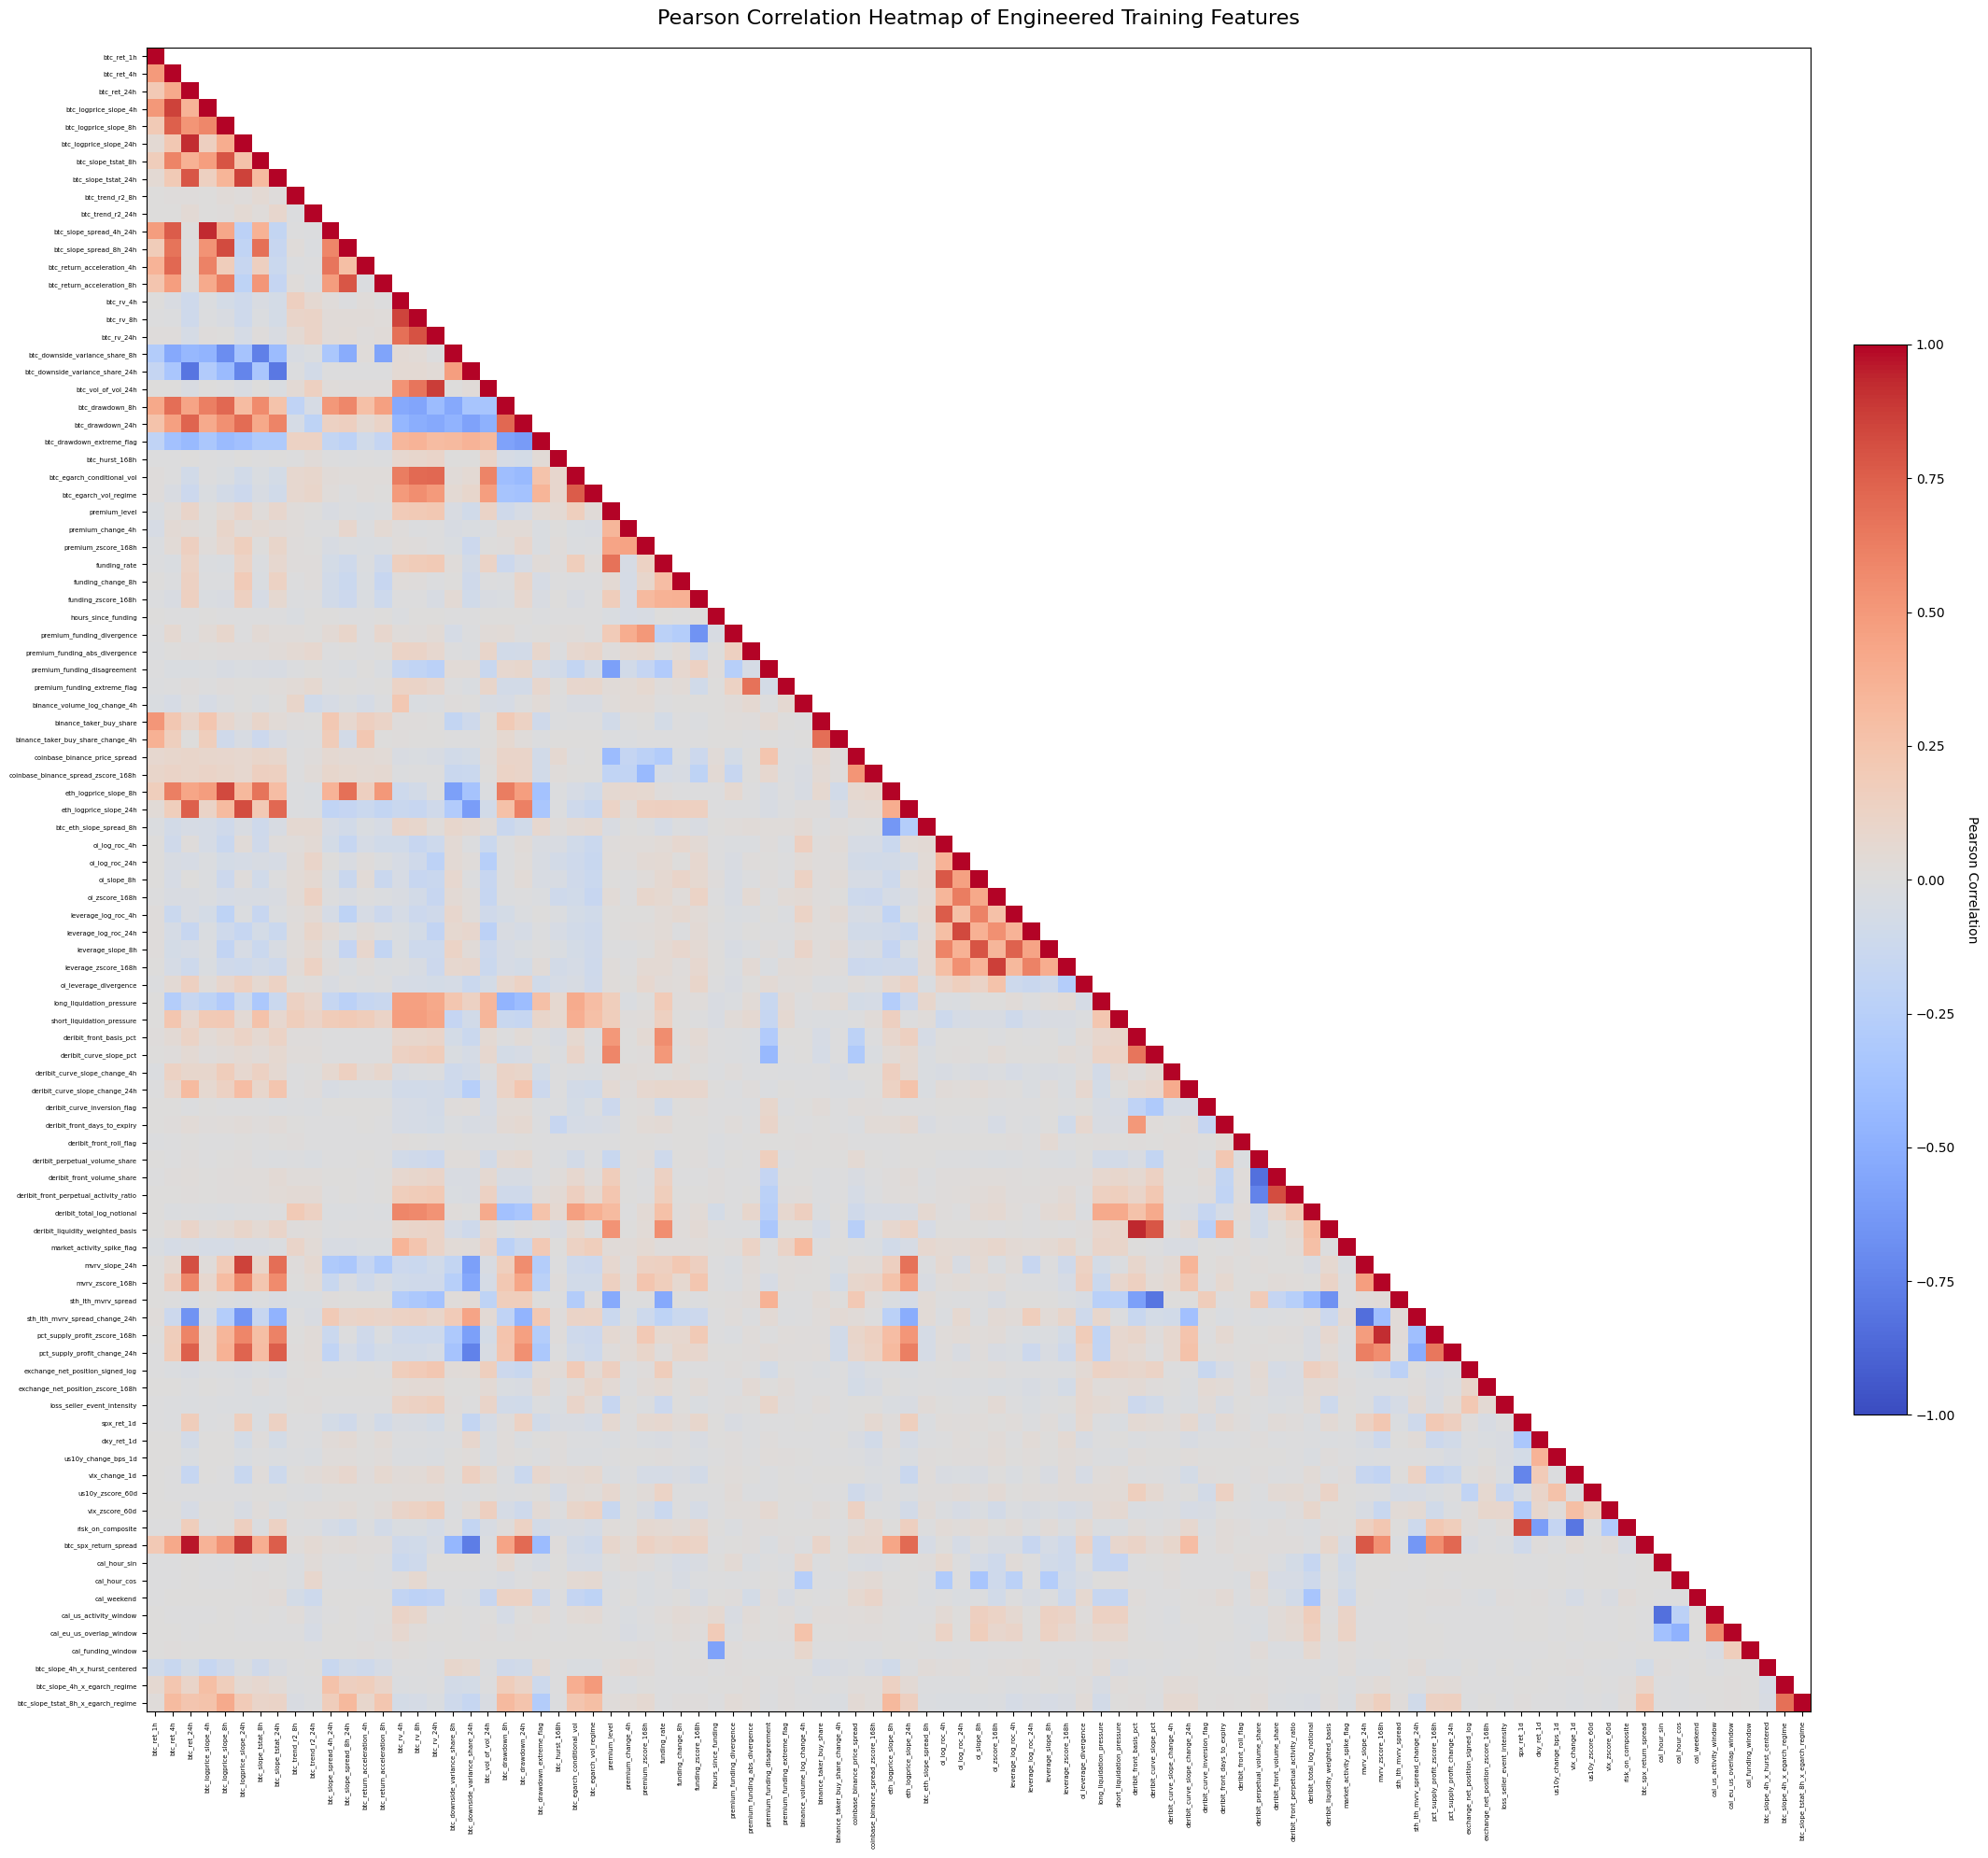

In [99]:
# Plot the complete feature-to-feature Pearson correlation heatmap
# Plot the lower triangle of the complete feature-to-feature Pearson correlation matrix
feature_corr = X_train_engineered.corr(method="pearson")
upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)
feature_corr_plot = np.ma.masked_where(upper_mask, feature_corr.to_numpy())

fig, ax = plt.subplots(figsize=(24, 20))
heatmap = ax.imshow(feature_corr_plot, vmin=-1, vmax=1, cmap="coolwarm", interpolation="nearest")

ax.set_xticks(range(len(feature_corr.columns)))
ax.set_yticks(range(len(feature_corr.index)))
ax.set_xticklabels(feature_corr.columns, rotation=90, fontsize=5)
ax.set_yticklabels(feature_corr.index, fontsize=5)
ax.set_title("Pearson Correlation Heatmap of Engineered Training Features", fontsize=16, pad=18)

colorbar = fig.colorbar(heatmap, ax=ax, fraction=0.025, pad=0.02)
colorbar.set_label("Pearson Correlation", rotation=270, labelpad=18)

plt.tight_layout()
plt.show()

The correlation heatmap does not show widespread high-correlation clustering across the full feature set. Strong relationships are concentrated mainly within economically related groups, particularly BTC trend/momentum, volatility, and some on-chain or term-structure features. Most cross-family correlations appear weak to moderate, suggesting that the engineered matrix contains substantial complementary information rather than being dominated by broad multicollinearity.

In [100]:
# Identify only highly correlated feature pairs
feature_corr = X_train_engineered.corr(method="pearson")
upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)

high_corr_pairs = feature_corr.where(upper_mask).stack().reset_index()
high_corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()
high_corr_pairs = high_corr_pairs.loc[high_corr_pairs["abs_correlation"] >= 0.90]
high_corr_pairs = high_corr_pairs.sort_values("abs_correlation", ascending=False).reset_index(drop=True)

print("Feature pairs with |correlation| >= 0.90:", len(high_corr_pairs))
display(high_corr_pairs.style.format({"correlation": "{:.4f}", "abs_correlation": "{:.4f}"}))

Feature pairs with |correlation| >= 0.90: 5


,feature_1,feature_2,correlation,abs_correlation
0,btc_ret_24h,btc_spx_return_spread,0.9640,0.9640
1,deribit_front_basis_pct,deribit_liquidity_weighted_basis,0.9310,0.9310
2,btc_logprice_slope_4h,btc_slope_spread_4h_24h,0.9287,0.9287
3,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9161,0.9161
4,btc_ret_24h,btc_logprice_slope_24h,0.9148,0.9148


In [102]:
# Remove structurally redundant engineered features
correlation_drop_features = [
    "btc_spx_return_spread",
    "btc_slope_spread_4h_24h",
    "deribit_front_basis_pct"]

assert set(correlation_drop_features).issubset(X_train_engineered.columns), "One or more selected features are missing."
X_train_corr_trimmed = X_train_engineered.drop(columns=correlation_drop_features).copy()

print("Original feature count:", X_train_engineered.shape[1])
print("Features removed:", len(correlation_drop_features))
print("Remaining feature count:", X_train_corr_trimmed.shape[1])
print("Removed features:", correlation_drop_features)

remaining_corr = X_train_corr_trimmed.corr(method="pearson")
upper_mask = np.triu(np.ones(remaining_corr.shape, dtype=bool), k=1)
remaining_pairs = remaining_corr.where(upper_mask).stack().reset_index()
remaining_pairs.columns = ["feature_1", "feature_2", "correlation"]
remaining_pairs["abs_correlation"] = remaining_pairs["correlation"].abs()
remaining_pairs = remaining_pairs.loc[remaining_pairs["abs_correlation"] >= 0.90]
remaining_pairs = remaining_pairs.sort_values("abs_correlation", ascending=False).reset_index(drop=True)

print("Remaining pairs with |correlation| >= 0.90:", len(remaining_pairs))
display(remaining_pairs.style.format({"correlation": "{:.4f}", "abs_correlation": "{:.4f}"}))

Original feature count: 95
Features removed: 3
Remaining feature count: 92
Removed features: ['btc_spx_return_spread', 'btc_slope_spread_4h_24h', 'deribit_front_basis_pct']
Remaining pairs with |correlation| >= 0.90: 2


,feature_1,feature_2,correlation,abs_correlation
0,mvrv_zscore_168h,pct_supply_profit_zscore_168h,0.9161,0.9161
1,btc_ret_24h,btc_logprice_slope_24h,0.9148,0.9148


These three features are removed because each is largely a constructed or narrower version of information already retained elsewhere. btc_spx_return_spread is dominated by the BTC 24-hour return component, btc_slope_spread_4h_24h is mechanically derived from the underlying slope features, and deribit_front_basis_pct is closely replicated by the broader liquidity-weighted basis measure. Removing them reduces redundancy without materially narrowing the economic information available to the models.

## **ii) VIF**

In [103]:
# Calculate VIF after structural correlation pruning
from sklearn.preprocessing import StandardScaler

X_vif = pd.DataFrame(
    StandardScaler().fit_transform(X_train_corr_trimmed),
    index=X_train_corr_trimmed.index,
    columns=X_train_corr_trimmed.columns)

inverse_corr = np.linalg.pinv(X_vif.corr().to_numpy())
vif_results = pd.DataFrame({"feature": X_vif.columns, "VIF": np.diag(inverse_corr)})
vif_results = vif_results.sort_values("VIF", ascending=False).reset_index(drop=True)

high_vif_features = vif_results.loc[vif_results["VIF"] > 30].copy()

print("Features assessed:", len(vif_results))
print("Features with VIF > 30:", len(high_vif_features))
display(high_vif_features.style.format({"VIF": "{:.2f}"}))

Features assessed: 92
Features with VIF > 30: 1


,feature,VIF
0,btc_ret_4h,65.52


Only btc_ret_4h exceeded the conservative VIF threshold of 30. Its elevated VIF reflects overlap with other short-term return and trend predictors. Because it remains a direct and interpretable momentum measure, it was retained for nonlinear feature selection and the L2-regularized logistic baseline.

In [ ]:
# Run Boruta using the locked ±0.05% dead zone
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import time

RETURN_THRESHOLD = 0.0005
BORUTA_MATRIX_PATH = DATA_PATH / "X_train_boruta_inclusive_4h.csv"
BORUTA_TARGET_PATH = DATA_PATH / "y_train_boruta_4h.csv"

targets_train = pd.read_csv(DATA_PATH / "targets_train_1h.csv", index_col="timestamp", parse_dates=["timestamp"])
targets_train.index = pd.to_datetime(targets_train.index, utc=True)
targets_train = targets_train.sort_index()

common_index = X_train_corr_trimmed.index.intersection(targets_train.index)
X_boruta = X_train_corr_trimmed.loc[common_index].copy()
fwd_ret_4h = targets_train.loc[common_index, "fwd_logret_4h"].copy()

keep_mask = fwd_ret_4h.abs() > RETURN_THRESHOLD
X_boruta = X_boruta.loc[keep_mask].copy()
y_boruta = (fwd_ret_4h.loc[keep_mask] > 0).astype(int).rename("target_4h")

assert X_boruta.index.equals(y_boruta.index), "Feature and target timestamps are not aligned."
assert X_boruta.isna().sum().sum() == 0, "Missing values detected."
assert np.isfinite(X_boruta.to_numpy()).all(), "Infinite values detected."
assert y_boruta.nunique() == 2, "Target must contain both classes."

print("Boruta observations:", len(X_boruta))
print("Boruta features:", X_boruta.shape[1])
print("Positive-class proportion:", f"{y_boruta.mean() * 100:.2f}%")

rf = RandomForestClassifier(max_depth=5, min_samples_leaf=20, max_features="sqrt", class_weight="balanced", n_jobs=-1, random_state=42)
boruta = BorutaPy(rf, n_estimators="auto", max_iter=100, perc=100, alpha=0.05, two_step=True, random_state=42, verbose=2)

start_time = time.time()
boruta.fit(X_boruta.to_numpy(), y_boruta.to_numpy())
runtime_minutes = (time.time() - start_time) / 60

boruta_results = pd.DataFrame({
    "feature": X_boruta.columns,
    "confirmed": boruta.support_,
    "tentative": boruta.support_weak_,
    "ranking": boruta.ranking_
})

boruta_results = boruta_results.sort_values(["confirmed", "tentative", "ranking"], ascending=[False, False, True]).reset_index(drop=True)

confirmed_features = boruta_results.loc[boruta_results["confirmed"], "feature"].tolist()
tentative_features = boruta_results.loc[boruta_results["tentative"], "feature"].tolist()
rejected_features = boruta_results.loc[~boruta_results["confirmed"] & ~boruta_results["tentative"], "feature"].tolist()

inclusive_features = confirmed_features + tentative_features
X_train_boruta_inclusive = X_boruta[inclusive_features].copy()

X_train_boruta_inclusive.to_csv(BORUTA_MATRIX_PATH, index=True, index_label="timestamp")
y_boruta.to_frame().to_csv(BORUTA_TARGET_PATH, index=True, index_label="timestamp")

print("Runtime in minutes:", f"{runtime_minutes:.2f}")
print("Confirmed features:", len(confirmed_features))
print("Tentative features:", len(tentative_features))
print("Rejected features:", len(rejected_features))
print("Inclusive matrix shape:", X_train_boruta_inclusive.shape)

display(boruta_results)

Aligned observations before target filtering: 40497
Near-zero observations removed: 5177
Boruta modelling observations: 35320
Boruta feature count: 108
Class 0 observations: 17179
Class 1 observations: 18141
Positive-class proportion: 51.36%
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	108
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	108
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	108
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	108
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	108
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	108
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	108
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	66
Tentative: 	29
Rejected: 	13
Iteration: 	9 / 100
Confirmed: 	66
Tentative: 	29
Rejected: 	13
Iteration: 	10 / 100
Confirmed: 	66
Tentative: 	29
Rejected: 	13
Iteration: 	11 / 100
Confirmed: 	66
Tentative: 	29
Rejected: 	13
Iteration: 	12 / 100
Confirmed: 	76
Tentative: 	19
Rejected

,feature,confirmed,tentative,ranking
0,btc_ret_1h,True,False,1
1,btc_ret_4h,True,False,1
2,btc_ret_6h,True,False,1
3,btc_ret_8h,True,False,1
4,btc_ret_12h,True,False,1
...,...,...,...,...
103,gn_liq_event_flag,False,False,15
104,btc_funding_event_flag,False,False,16
105,deribit_front_roll_flag,False,False,18
106,cal_quarter_end_flag,False,False,18


In [ ]:
# Prepare a chronological internal split for SHAP analysis

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, classification_report
import shap

X_shap_all = X_train_boruta_inclusive.copy()
y_shap_all = y_boruta.loc[X_shap_all.index].copy()

SHAP_TRAIN_FRACTION = 0.80
SHAP_SPLIT_INDEX = int(len(X_shap_all) * SHAP_TRAIN_FRACTION)

X_shap_train = X_shap_all.iloc[:SHAP_SPLIT_INDEX].copy()
X_shap_valid = X_shap_all.iloc[SHAP_SPLIT_INDEX:].copy()
y_shap_train = y_shap_all.iloc[:SHAP_SPLIT_INDEX].copy()
y_shap_valid = y_shap_all.iloc[SHAP_SPLIT_INDEX:].copy()

assert X_shap_train.index.max() < X_shap_valid.index.min(), "The SHAP development split is not chronological."
assert X_shap_train.columns.equals(X_shap_valid.columns), "Training and validation features differ."
assert X_shap_train.shape[1] == X_shap_all.shape[1], f"Unexpected SHAP input feature count: {X_shap_train.shape[1]}"

print("SHAP input features:", X_shap_all.shape[1])
print("Internal training shape:", X_shap_train.shape)
print("Internal validation shape:", X_shap_valid.shape)
print("Internal training range:", X_shap_train.index.min(), "to", X_shap_train.index.max())
print("Internal validation range:", X_shap_valid.index.min(), "to", X_shap_valid.index.max())

shap_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=20,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=2.00,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

start_time = time.time()
shap_model.fit(X_shap_train, y_shap_train)
shap_model_runtime_minutes = (time.time() - start_time) / 60

shap_valid_probability = shap_model.predict_proba(X_shap_valid)[:, 1]
shap_valid_prediction = (shap_valid_probability >= 0.50).astype(int)

print("XGBoost runtime in minutes:", round(shap_model_runtime_minutes, 2))
print("Validation accuracy:", round(accuracy_score(y_shap_valid, shap_valid_prediction), 4))
print("Validation balanced accuracy:", round(balanced_accuracy_score(y_shap_valid, shap_valid_prediction), 4))
print("Validation ROC-AUC:", round(roc_auc_score(y_shap_valid, shap_valid_probability), 4))
print()
print(classification_report(y_shap_valid, shap_valid_prediction, digits=4))

SHAP_SAMPLE_SIZE = min(5000, len(X_shap_valid))
X_shap_sample = X_shap_valid.sample(n=SHAP_SAMPLE_SIZE, random_state=42).sort_index()

print("Rows selected for SHAP calculation:", len(X_shap_sample))

SHAP input features: 91
Internal training shape: (28256, 91)
Internal validation shape: (7064, 91)
Internal training range: 2020-07-29 00:00:00+00:00 to 2024-04-08 01:00:00+00:00
Internal validation range: 2024-04-08 02:00:00+00:00 to 2025-03-12 08:00:00+00:00
XGBoost runtime in minutes: 0.13
Validation accuracy: 0.5263
Validation balanced accuracy: 0.5212
Validation ROC-AUC: 0.544

              precision    recall  f1-score   support

           0     0.5227    0.3213    0.3980      3442
           1     0.5279    0.7211    0.6096      3622

    accuracy                         0.5263      7064
   macro avg     0.5253    0.5212    0.5038      7064
weighted avg     0.5254    0.5263    0.5065      7064

Rows selected for SHAP calculation: 5000


SHAP runtime in minutes: 0.05
Features ranked: 91
Median mean absolute SHAP: 0.013592
Mean mean absolute SHAP: 0.017883


,selection_rule,number_of_features
0,Above median mean |SHAP|,45
1,Above mean mean |SHAP|,27
2,Top 20,20
3,Top 30,30
4,Top 40,40
5,Cumulative SHAP <= 80%,51
6,Cumulative SHAP <= 90%,66


,feature,mean_abs_shap,rank,cumulative_shap_share
0,yf_spx_level,0.096375,1,0.0592
1,btc_vol_scaled_momentum_4h,0.071074,2,0.1029
2,btc_ret_6h,0.065102,3,0.1429
3,btc_vol_scaled_momentum_24h,0.060357,4,0.1800
4,coinbase_premium,0.052760,5,0.2124
5,eth_ret_24h,0.049507,6,0.2428
6,yf_us10y_zscore_720h,0.041077,7,0.2681
7,btc_ret_4h,0.039339,8,0.2922
8,yf_us10y_change_168h,0.034323,9,0.3133
9,gn_oi_perp_change_24h,0.034069,10,0.3343


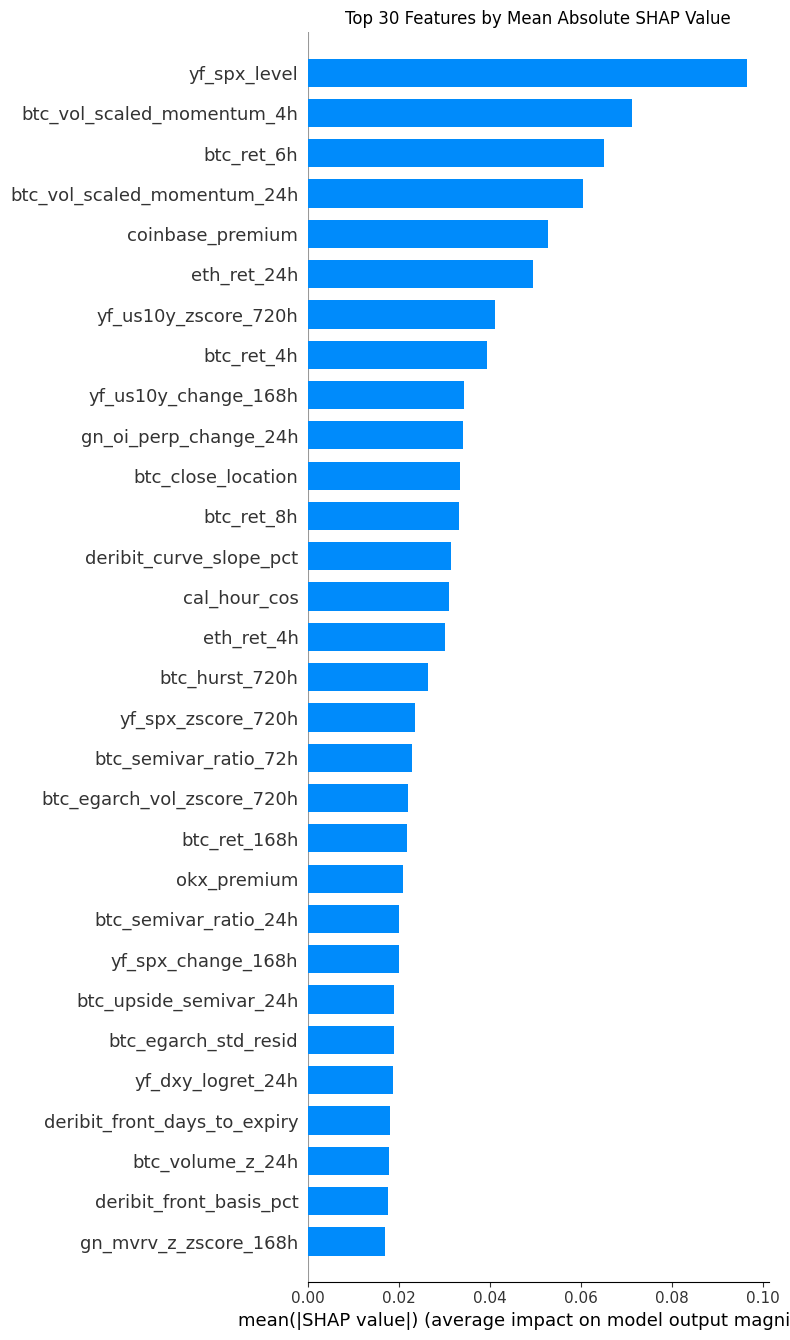

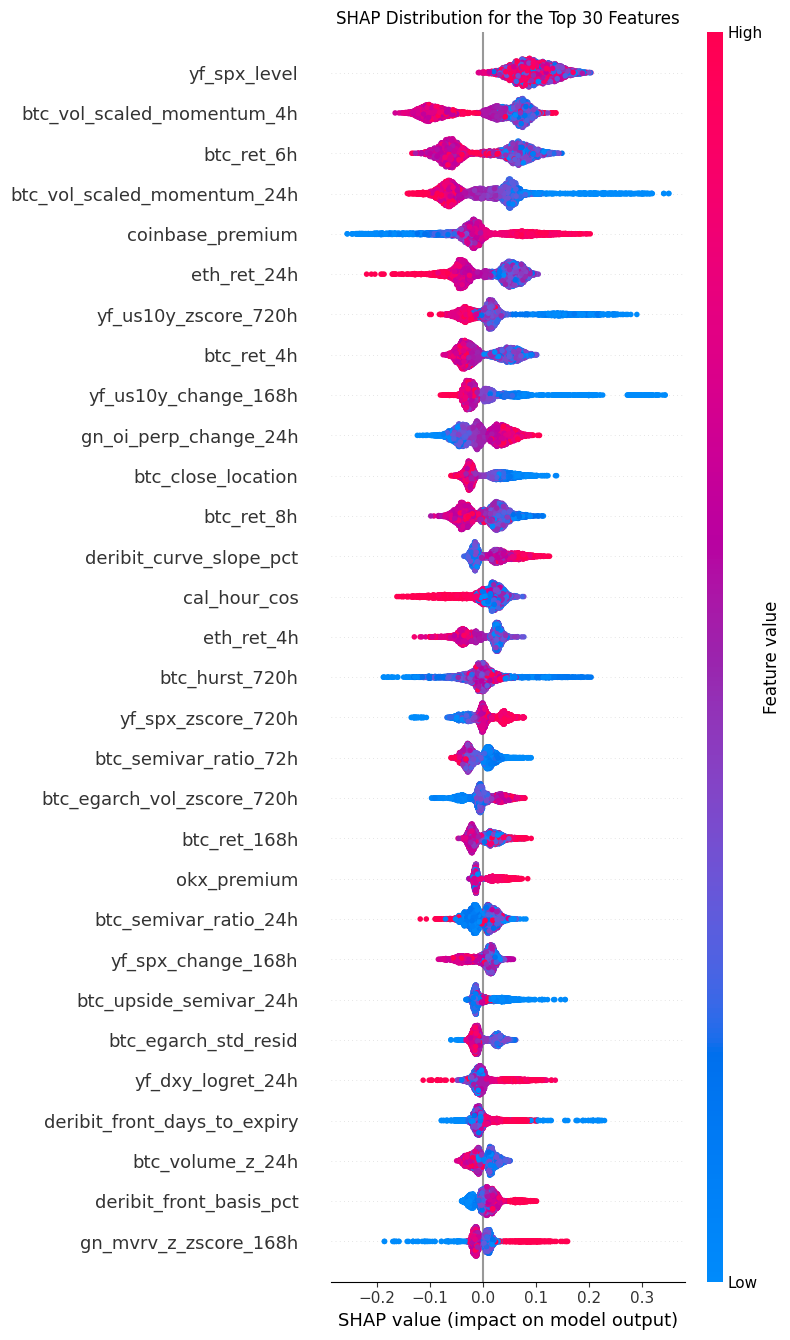

In [ ]:
# Calculate SHAP values and rank the Boruta-confirmed plus tentative features

start_time = time.time()

shap_explainer = shap.TreeExplainer(shap_model)
shap_values = shap_explainer(X_shap_sample)

shap_runtime_minutes = (time.time() - start_time) / 60

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_feature_ranking = pd.DataFrame({
    "feature": X_shap_sample.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_feature_ranking["rank"] = np.arange(1, len(shap_feature_ranking) + 1)
shap_feature_ranking["cumulative_shap_share"] = shap_feature_ranking["mean_abs_shap"].cumsum() / shap_feature_ranking["mean_abs_shap"].sum()

median_shap = shap_feature_ranking["mean_abs_shap"].median()
mean_shap = shap_feature_ranking["mean_abs_shap"].mean()

shap_cutoff_summary = pd.DataFrame({
    "selection_rule": ["Above median mean |SHAP|", "Above mean mean |SHAP|", "Top 20", "Top 30", "Top 40", "Cumulative SHAP <= 80%", "Cumulative SHAP <= 90%"],
    "number_of_features": [
        (shap_feature_ranking["mean_abs_shap"] > median_shap).sum(),
        (shap_feature_ranking["mean_abs_shap"] > mean_shap).sum(),
        min(20, len(shap_feature_ranking)),
        min(30, len(shap_feature_ranking)),
        min(40, len(shap_feature_ranking)),
        (shap_feature_ranking["cumulative_shap_share"] <= 0.80).sum() + 1,
        (shap_feature_ranking["cumulative_shap_share"] <= 0.90).sum() + 1
    ]
})

print("SHAP runtime in minutes:", round(shap_runtime_minutes, 2))
print("Features ranked:", len(shap_feature_ranking))
print("Median mean absolute SHAP:", round(median_shap, 6))
print("Mean mean absolute SHAP:", round(mean_shap, 6))

display(shap_cutoff_summary)
display(shap_feature_ranking.head(40).style.format({
    "mean_abs_shap": "{:.6f}",
    "cumulative_shap_share": "{:.4f}"
}))

shap.summary_plot(shap_values.values, X_shap_sample, plot_type="bar", max_display=30, show=False)
plt.title("Top 30 Features by Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values.values, X_shap_sample, max_display=30, show=False)
plt.title("SHAP Distribution for the Top 30 Features")
plt.tight_layout()
plt.show()

In [13]:
# Sensitivity check: iterative VIF reduction using threshold 10

from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF_THRESHOLD_10 = 10.0
X_train_vif10_trimmed = X_train_corr_trimmed.copy()
vif10_removal_log = []

while True:
    X_vif10_scaled = StandardScaler().fit_transform(X_train_vif10_trimmed)
    vif10_values = pd.Series([variance_inflation_factor(X_vif10_scaled, i) for i in range(X_vif10_scaled.shape[1])], index=X_train_vif10_trimmed.columns)
    max_vif10_feature = vif10_values.idxmax()
    max_vif10_value = vif10_values.max()

    if max_vif10_value <= VIF_THRESHOLD_10:
        break

    vif10_removal_log.append({"feature": max_vif10_feature, "vif_at_removal": max_vif10_value})
    X_train_vif10_trimmed = X_train_vif10_trimmed.drop(columns=max_vif10_feature)

vif10_removal_log = pd.DataFrame(vif10_removal_log)

print("VIF 30 feature count:", X_train_vif_trimmed.shape[1])
print("VIF 10 feature count:", X_train_vif10_trimmed.shape[1])
print("Additional features removed under VIF 10:", X_train_vif_trimmed.shape[1] - X_train_vif10_trimmed.shape[1])
print("Final maximum VIF under threshold 10:", f"{max_vif10_value:.2f}")

display(vif10_removal_log)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero

VIF 30 feature count: 108
VIF 10 feature count: 90
Additional features removed under VIF 10: 18
Final maximum VIF under threshold 10: 9.91


,feature,vif_at_removal
0,btc_ret_1h,inf
1,btc_ret_4h,inf
2,btc_ret_12h,inf
3,btc_ret_24h,inf
4,deribit_front_basis_pct,inf
5,gn_opt_skew_1w,inf
6,btc_log_base_volume,171.071252
7,btc_log_num_trades,75.934448
8,eth_ret_24h,63.469435
9,gn_mvrv_z,52.976022


## **(VII) Model Training**

## **Feature Engineering and Feature Selection Enhancement**

In [14]:
# Load and validate the existing v1 training matrices for the v2 feature-engineering experiment
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/CQF_final_project/data")

ENGINEERED_V1_PATH = DATA_PATH / "X_train_engineered_1h.csv"
RAW_TRAIN_PATH = DATA_PATH / "X_train_1h.csv"

assert ENGINEERED_V1_PATH.exists(), f"Missing file: {ENGINEERED_V1_PATH}"
assert RAW_TRAIN_PATH.exists(), f"Missing file: {RAW_TRAIN_PATH}"

X_train_engineered = pd.read_csv(ENGINEERED_V1_PATH, index_col="timestamp", parse_dates=["timestamp"])
X_train_engineered.index = pd.to_datetime(X_train_engineered.index, utc=True)
X_train_engineered = X_train_engineered.sort_index()

X_train_raw_v2 = pd.read_csv(RAW_TRAIN_PATH, index_col="timestamp", parse_dates=["timestamp"])
X_train_raw_v2.index = pd.to_datetime(X_train_raw_v2.index, utc=True)
X_train_raw_v2 = X_train_raw_v2.sort_index()

assert "btc_close" in X_train_raw_v2.columns, "btc_close is missing from X_train_1h.csv."
assert X_train_engineered.shape[1] == 121, f"Unexpected v1 feature count: {X_train_engineered.shape[1]}"
assert not X_train_engineered.index.has_duplicates, "Duplicate timestamps detected in X_train_engineered."
assert not X_train_engineered.columns.has_duplicates, "Duplicate feature names detected in X_train_engineered."
assert X_train_engineered.isna().sum().sum() == 0, "Missing values detected in X_train_engineered."
assert np.isfinite(X_train_engineered.select_dtypes(include=np.number).to_numpy()).all(), "Infinite values detected in X_train_engineered."
assert not X_train_raw_v2.index.has_duplicates, "Duplicate timestamps detected in X_train_raw_v2."
assert X_train_engineered.index.isin(X_train_raw_v2.index).all(), "Some engineered timestamps are absent from the raw training matrix."

print("V1 engineered training matrix:", X_train_engineered.shape)
print("V1 engineered date range:", X_train_engineered.index.min(), "to", X_train_engineered.index.max())
print("Raw training matrix:", X_train_raw_v2.shape)
print("Raw training date range:", X_train_raw_v2.index.min(), "to", X_train_raw_v2.index.max())
print("btc_close available:", "btc_close" in X_train_raw_v2.columns)
print("Missing values in engineered matrix:", int(X_train_engineered.isna().sum().sum()))
print("Infinite values in engineered matrix:", int(np.isinf(X_train_engineered.select_dtypes(include=np.number).to_numpy()).sum()))

V1 engineered training matrix: (40497, 121)
V1 engineered date range: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Raw training matrix: (45537, 48)
Raw training date range: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
btc_close available: True
Missing values in engineered matrix: 0
Infinite values in engineered matrix: 0


In [15]:
# Create the v2 working matrix and align BTC close for trend-feature construction
X_train_engineered_v2 = X_train_engineered.copy()

btc_close_v2 = X_train_raw_v2["btc_close"].reindex(X_train_engineered_v2.index).astype(float)
btc_log_close_v2 = np.log(btc_close_v2)

assert btc_close_v2.notna().all(), "Missing btc_close values after alignment."
assert np.isfinite(btc_close_v2.to_numpy()).all(), "Non-finite btc_close values detected."
assert (btc_close_v2 > 0).all(), "Non-positive btc_close values detected."
assert btc_log_close_v2.notna().all(), "Missing log BTC close values detected."
assert np.isfinite(btc_log_close_v2.to_numpy()).all(), "Non-finite log BTC close values detected."
assert X_train_engineered_v2.index.equals(btc_close_v2.index), "BTC close index is not aligned with the v2 matrix."

print("V2 working matrix:", X_train_engineered_v2.shape)
print("V2 date range:", X_train_engineered_v2.index.min(), "to", X_train_engineered_v2.index.max())
print("Aligned BTC close observations:", btc_close_v2.shape[0])
print("Missing aligned BTC close values:", int(btc_close_v2.isna().sum()))
print("BTC close range:", round(btc_close_v2.min(), 2), "to", round(btc_close_v2.max(), 2))
print("V1 matrix unchanged:", X_train_engineered_v2.equals(X_train_engineered))

V2 working matrix: (40497, 121)
V2 date range: 2020-07-29 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Aligned BTC close observations: 40497
Missing aligned BTC close values: 0
BTC close range: 9950.84 to 108332.0
V1 matrix unchanged: True


In [17]:
# Add compact v2 trend-geometry features

REQUIRED_TREND_SOURCE_FEATURES_V2 = ["btc_rv_24h"]

missing_trend_sources_v2 = [col for col in REQUIRED_TREND_SOURCE_FEATURES_V2 if col not in X_train_engineered_v2.columns]
assert not missing_trend_sources_v2, f"Missing required source features: {missing_trend_sources_v2}"

def rolling_logprice_slope_v2(values):
    y = np.asarray(values, dtype=float)
    x = np.arange(len(y), dtype=float)
    x_centered = x - x.mean()
    return np.dot(x_centered, y - y.mean()) / np.dot(x_centered, x_centered)

def rolling_logprice_tstat_v2(values):
    y = np.asarray(values, dtype=float)
    x = np.arange(len(y), dtype=float)
    x_centered = x - x.mean()
    y_centered = y - y.mean()
    slope = np.dot(x_centered, y_centered) / np.dot(x_centered, x_centered)
    fitted = y.mean() + slope * x_centered
    residuals = y - fitted
    degrees_of_freedom = len(y) - 2
    residual_variance = np.dot(residuals, residuals) / degrees_of_freedom
    slope_standard_error = np.sqrt(residual_variance / np.dot(x_centered, x_centered))
    return slope / slope_standard_error if slope_standard_error > 0 else np.nan

def rolling_logprice_r2_v2(values):
    y = np.asarray(values, dtype=float)
    x = np.arange(len(y), dtype=float)
    x_centered = x - x.mean()
    y_centered = y - y.mean()
    denominator = np.dot(x_centered, x_centered) * np.dot(y_centered, y_centered)
    return (np.dot(x_centered, y_centered) ** 2) / denominator if denominator > 0 else np.nan

X_train_engineered_v2["btc_logprice_slope_12h"] = btc_log_close_v2.rolling(window=12, min_periods=12).apply(rolling_logprice_slope_v2, raw=True)
X_train_engineered_v2["btc_logprice_slope_24h"] = btc_log_close_v2.rolling(window=24, min_periods=24).apply(rolling_logprice_slope_v2, raw=True)
X_train_engineered_v2["btc_logprice_slope_72h"] = btc_log_close_v2.rolling(window=72, min_periods=72).apply(rolling_logprice_slope_v2, raw=True)

X_train_engineered_v2["btc_logprice_slope_tstat_24h"] = btc_log_close_v2.rolling(window=24, min_periods=24).apply(rolling_logprice_tstat_v2, raw=True)
X_train_engineered_v2["btc_logprice_trend_r2_24h"] = btc_log_close_v2.rolling(window=24, min_periods=24).apply(rolling_logprice_r2_v2, raw=True)

X_train_engineered_v2["btc_slope_spread_12h_72h"] = X_train_engineered_v2["btc_logprice_slope_12h"] - X_train_engineered_v2["btc_logprice_slope_72h"]

btc_return_6h_v2 = btc_log_close_v2.diff(6)
X_train_engineered_v2["btc_return_acceleration_6h"] = btc_return_6h_v2 - btc_return_6h_v2.shift(6)

rv_24h_safe_v2 = X_train_engineered_v2["btc_rv_24h"].replace(0, np.nan)
X_train_engineered_v2["btc_vol_scaled_slope_24h"] = X_train_engineered_v2["btc_logprice_slope_24h"] / rv_24h_safe_v2

TREND_FEATURES_V2 = [
    "btc_logprice_slope_12h",
    "btc_logprice_slope_24h",
    "btc_logprice_slope_72h",
    "btc_logprice_slope_tstat_24h",
    "btc_logprice_trend_r2_24h",
    "btc_slope_spread_12h_72h",
    "btc_return_acceleration_6h",
    "btc_vol_scaled_slope_24h"
]

assert X_train_engineered_v2.shape[1] == 129, f"Unexpected v2 feature count: {X_train_engineered_v2.shape[1]}"
assert X_train_engineered_v2.columns.is_unique, "Duplicate feature names detected."
assert X_train_engineered_v2[TREND_FEATURES_V2].notna().any().all(), "One or more trend features contain no valid observations."

print("V2 matrix after trend features:", X_train_engineered_v2.shape)
print("New trend features added:", len(TREND_FEATURES_V2))
print("Duplicate feature names:", int(X_train_engineered_v2.columns.duplicated().sum()))

display(
    pd.DataFrame({
        "first_valid_timestamp": X_train_engineered_v2[TREND_FEATURES_V2].apply(pd.Series.first_valid_index),
        "missing_count": X_train_engineered_v2[TREND_FEATURES_V2].isna().sum(),
        "infinite_count": [
            int(np.isinf(X_train_engineered_v2[col].dropna().to_numpy()).sum())
            for col in TREND_FEATURES_V2
        ]
    })
)

V2 matrix after trend features: (40497, 129)
New trend features added: 8
Duplicate feature names: 0


,first_valid_timestamp,missing_count,infinite_count
btc_logprice_slope_12h,2020-07-29 11:00:00+00:00,11,0
btc_logprice_slope_24h,2020-07-29 23:00:00+00:00,23,0
btc_logprice_slope_72h,2020-07-31 23:00:00+00:00,71,0
btc_logprice_slope_tstat_24h,2020-07-29 23:00:00+00:00,23,0
btc_logprice_trend_r2_24h,2020-07-29 23:00:00+00:00,23,0
btc_slope_spread_12h_72h,2020-07-31 23:00:00+00:00,71,0
btc_return_acceleration_6h,2020-07-29 12:00:00+00:00,12,0
btc_vol_scaled_slope_24h,2020-07-29 23:00:00+00:00,23,0


In [18]:
# Add v2 regime-interaction and global-session features

INTERACTION_SOURCE_FEATURES_V2 = ["btc_vol_scaled_momentum_4h", "btc_hurst_720h", "btc_egarch_vol_zscore_720h"]
missing_interaction_sources_v2 = [col for col in INTERACTION_SOURCE_FEATURES_V2 if col not in X_train_engineered_v2.columns]
assert not missing_interaction_sources_v2, f"Missing interaction source features: {missing_interaction_sources_v2}"

X_train_engineered_v2["btc_momentum_4h_x_hurst"] = X_train_engineered_v2["btc_vol_scaled_momentum_4h"] * X_train_engineered_v2["btc_hurst_720h"]
X_train_engineered_v2["btc_momentum_4h_x_egarch_regime"] = X_train_engineered_v2["btc_vol_scaled_momentum_4h"] * X_train_engineered_v2["btc_egarch_vol_zscore_720h"]

hour_utc_v2 = X_train_engineered_v2.index.hour
X_train_engineered_v2["cal_us_session"] = ((hour_utc_v2 >= 13) & (hour_utc_v2 < 22)).astype(int)
X_train_engineered_v2["cal_europe_us_overlap"] = ((hour_utc_v2 >= 13) & (hour_utc_v2 < 16)).astype(int)

INTERACTION_SESSION_FEATURES_V2 = ["btc_momentum_4h_x_hurst", "btc_momentum_4h_x_egarch_regime", "cal_us_session", "cal_europe_us_overlap"]

assert X_train_engineered_v2.shape[1] == 133, f"Unexpected v2 feature count: {X_train_engineered_v2.shape[1]}"
assert X_train_engineered_v2.columns.is_unique, "Duplicate feature names detected."
assert X_train_engineered_v2[INTERACTION_SESSION_FEATURES_V2].notna().any().all(), "One or more new features contain no valid observations."
assert set(X_train_engineered_v2["cal_us_session"].unique()).issubset({0, 1}), "Invalid values in cal_us_session."
assert set(X_train_engineered_v2["cal_europe_us_overlap"].unique()).issubset({0, 1}), "Invalid values in cal_europe_us_overlap."
assert (X_train_engineered_v2["cal_europe_us_overlap"] <= X_train_engineered_v2["cal_us_session"]).all(), "Overlap occurs outside the US session."

interaction_session_audit_v2 = pd.DataFrame(index=INTERACTION_SESSION_FEATURES_V2)
interaction_session_audit_v2["first_valid_timestamp"] = X_train_engineered_v2[INTERACTION_SESSION_FEATURES_V2].apply(pd.Series.first_valid_index)
interaction_session_audit_v2["last_valid_timestamp"] = X_train_engineered_v2[INTERACTION_SESSION_FEATURES_V2].apply(pd.Series.last_valid_index)
interaction_session_audit_v2["missing_count"] = X_train_engineered_v2[INTERACTION_SESSION_FEATURES_V2].isna().sum()
interaction_session_audit_v2["infinite_count"] = [int(np.isinf(X_train_engineered_v2[col].dropna().to_numpy()).sum()) for col in INTERACTION_SESSION_FEATURES_V2]

print("V2 matrix after all 12 new features:", X_train_engineered_v2.shape)
print("Interaction and session features added:", len(INTERACTION_SESSION_FEATURES_V2))
print("Total new v2 features:", len(TREND_FEATURES_V2) + len(INTERACTION_SESSION_FEATURES_V2))
print("US-session observations:", int(X_train_engineered_v2["cal_us_session"].sum()))
print("Europe-US overlap observations:", int(X_train_engineered_v2["cal_europe_us_overlap"].sum()))
print("Duplicate feature names:", int(X_train_engineered_v2.columns.duplicated().sum()))

display(interaction_session_audit_v2)

V2 matrix after all 12 new features: (40497, 133)
Interaction and session features added: 4
Total new v2 features: 12
US-session observations: 15183
Europe-US overlap observations: 5061
Duplicate feature names: 0


,first_valid_timestamp,last_valid_timestamp,missing_count,infinite_count
btc_momentum_4h_x_hurst,2020-07-29 00:00:00+00:00,2025-03-12 08:00:00+00:00,0,0
btc_momentum_4h_x_egarch_regime,2020-07-29 00:00:00+00:00,2025-03-12 08:00:00+00:00,0,0
cal_us_session,2020-07-29 00:00:00+00:00,2025-03-12 08:00:00+00:00,0,0
cal_europe_us_overlap,2020-07-29 00:00:00+00:00,2025-03-12 08:00:00+00:00,0,0


In [19]:
# Audit all 12 new v2 features

NEW_FEATURES_V2 = TREND_FEATURES_V2 + INTERACTION_SESSION_FEATURES_V2

new_feature_audit_v2 = pd.DataFrame(index=NEW_FEATURES_V2)
new_feature_audit_v2["first_valid_timestamp"] = X_train_engineered_v2[NEW_FEATURES_V2].apply(pd.Series.first_valid_index)
new_feature_audit_v2["last_valid_timestamp"] = X_train_engineered_v2[NEW_FEATURES_V2].apply(pd.Series.last_valid_index)
new_feature_audit_v2["missing_count"] = X_train_engineered_v2[NEW_FEATURES_V2].isna().sum()
new_feature_audit_v2["infinite_count"] = [int(np.isinf(X_train_engineered_v2[col].dropna().to_numpy()).sum()) for col in NEW_FEATURES_V2]

new_feature_stats_v2 = X_train_engineered_v2[NEW_FEATURES_V2].describe().T
new_feature_stats_v2 = new_feature_stats_v2[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

common_valid_mask_v2 = X_train_engineered_v2[NEW_FEATURES_V2].notna().all(axis=1)
common_valid_mask_v2 &= np.isfinite(X_train_engineered_v2[NEW_FEATURES_V2].to_numpy()).all(axis=1)

common_valid_start_v2 = X_train_engineered_v2.index[common_valid_mask_v2][0]
rows_before_common_start_v2 = int((X_train_engineered_v2.index < common_valid_start_v2).sum())

assert len(NEW_FEATURES_V2) == 12, f"Unexpected new-feature count: {len(NEW_FEATURES_V2)}"
assert new_feature_audit_v2["infinite_count"].sum() == 0, "Infinite values detected in the new v2 features."
assert common_valid_mask_v2.any(), "No common valid observations exist across the new v2 features."

print("New v2 features audited:", len(NEW_FEATURES_V2))
print("Earliest common valid timestamp:", common_valid_start_v2)
print("Rows before common valid timestamp:", rows_before_common_start_v2)
print("Rows available after common valid timestamp:", int(common_valid_mask_v2.sum()))

display(new_feature_audit_v2)
display(new_feature_stats_v2)

New v2 features audited: 12
Earliest common valid timestamp: 2020-07-31 23:00:00+00:00
Rows before common valid timestamp: 71
Rows available after common valid timestamp: 40426


,first_valid_timestamp,last_valid_timestamp,missing_count,infinite_count
btc_logprice_slope_12h,2020-07-29 11:00:00+00:00,2025-03-12 08:00:00+00:00,11,0
btc_logprice_slope_24h,2020-07-29 23:00:00+00:00,2025-03-12 08:00:00+00:00,23,0
btc_logprice_slope_72h,2020-07-31 23:00:00+00:00,2025-03-12 08:00:00+00:00,71,0
btc_logprice_slope_tstat_24h,2020-07-29 23:00:00+00:00,2025-03-12 08:00:00+00:00,23,0
btc_logprice_trend_r2_24h,2020-07-29 23:00:00+00:00,2025-03-12 08:00:00+00:00,23,0
btc_slope_spread_12h_72h,2020-07-31 23:00:00+00:00,2025-03-12 08:00:00+00:00,71,0
btc_return_acceleration_6h,2020-07-29 12:00:00+00:00,2025-03-12 08:00:00+00:00,12,0
btc_vol_scaled_slope_24h,2020-07-29 23:00:00+00:00,2025-03-12 08:00:00+00:00,23,0
btc_momentum_4h_x_hurst,2020-07-29 00:00:00+00:00,2025-03-12 08:00:00+00:00,0,0
btc_momentum_4h_x_egarch_regime,2020-07-29 00:00:00+00:00,2025-03-12 08:00:00+00:00,0,0


,count,mean,std,min,25%,50%,75%,max
btc_logprice_slope_12h,40486.0,4.971512e-05,0.002068,-1.463143e-02,-0.000758,0.000042,0.000872,0.015278
btc_logprice_slope_24h,40474.0,4.947086e-05,0.001473,-9.291060e-03,-0.000588,0.000032,0.000713,0.009224
btc_logprice_slope_72h,40426.0,4.918182e-05,0.000838,-4.466611e-03,-0.000350,0.000036,0.000468,0.003858
btc_logprice_slope_tstat_24h,40474.0,3.424869e-01,5.690296,-3.141889e+01,-3.590978,0.263240,4.307450,25.642931
btc_logprice_trend_r2_24h,40474.0,4.108131e-01,0.283969,1.477025e-11,0.137017,0.415004,0.665991,0.978199
btc_slope_spread_12h_72h,40426.0,-6.262402e-08,0.002111,-1.432989e-02,-0.000983,-0.000021,0.000935,0.013613
btc_return_acceleration_6h,40485.0,-3.453446e-06,0.022723,-2.790422e-01,-0.010478,-0.000055,0.010290,0.222901
btc_vol_scaled_slope_24h,40474.0,1.287853e-02,0.207194,-7.998823e-01,-0.123580,0.008768,0.149424,0.781600
btc_momentum_4h_x_hurst,40497.0,9.226596e-03,0.488747,-2.077974e+00,-0.256507,0.010364,0.279017,2.568401
btc_momentum_4h_x_egarch_regime,40497.0,-7.465074e-02,1.617964,-3.481114e+01,-0.306542,-0.006315,0.240515,66.935175


In [20]:
# Trim the full v2 matrix to the common valid sample and save it

X_train_engineered_v2 = X_train_engineered_v2.loc[common_valid_start_v2:].copy()

numeric_values_v2 = X_train_engineered_v2.select_dtypes(include=np.number).to_numpy()

assert X_train_engineered_v2.shape == (40426, 133), f"Unexpected trimmed v2 shape: {X_train_engineered_v2.shape}"
assert X_train_engineered_v2.index.min() == common_valid_start_v2, "Unexpected v2 start timestamp."
assert X_train_engineered_v2.index.max() == X_train_engineered.index.max(), "Unexpected v2 end timestamp."
assert not X_train_engineered_v2.index.has_duplicates, "Duplicate timestamps detected."
assert X_train_engineered_v2.columns.is_unique, "Duplicate feature names detected."
assert X_train_engineered_v2.isna().sum().sum() == 0, "Missing values remain after trimming."
assert np.isfinite(numeric_values_v2).all(), "Infinite values remain after trimming."

ENGINEERED_V2_PATH = DATA_PATH / "X_train_engineered_v2_1h.csv"
X_train_engineered_v2.to_csv(ENGINEERED_V2_PATH, index=True, index_label="timestamp")

assert ENGINEERED_V2_PATH.exists(), f"File was not saved: {ENGINEERED_V2_PATH}"

print("Final v2 engineered matrix:", X_train_engineered_v2.shape)
print("Final v2 date range:", X_train_engineered_v2.index.min(), "to", X_train_engineered_v2.index.max())
print("Rows removed for v2 warm-up:", X_train_engineered.shape[0] - X_train_engineered_v2.shape[0])
print("Feature count increase versus v1:", X_train_engineered_v2.shape[1] - X_train_engineered.shape[1])
print("Missing values:", int(X_train_engineered_v2.isna().sum().sum()))
print("Infinite values:", int(np.isinf(numeric_values_v2).sum()))
print("Duplicate timestamps:", int(X_train_engineered_v2.index.duplicated().sum()))
print("Duplicate feature names:", int(X_train_engineered_v2.columns.duplicated().sum()))
print("Saved to:", ENGINEERED_V2_PATH)

Final v2 engineered matrix: (40426, 133)
Final v2 date range: 2020-07-31 23:00:00+00:00 to 2025-03-12 08:00:00+00:00
Rows removed for v2 warm-up: 71
Feature count increase versus v1: 12
Missing values: 0
Infinite values: 0
Duplicate timestamps: 0
Duplicate feature names: 0
Saved to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/X_train_engineered_v2_1h.csv


In [21]:
# Inspect current v2 feature families before curated trimming

FEATURE_FAMILY_PATTERNS_V2 = {
    "calendar": ["cal_"],
    "btc_returns_momentum": ["btc_ret_", "btc_vol_scaled_momentum_"],
    "btc_trend": ["btc_logprice_", "btc_slope_", "btc_return_acceleration_", "btc_vol_scaled_slope_"],
    "btc_volatility": ["btc_rv_", "btc_egarch_", "btc_semivar_"],
    "btc_hurst": ["btc_hurst_"],
    "eth": ["eth_"],
    "premium_funding": ["coinbase_premium", "okx_premium", "btc_premium_index", "btc_funding_rate"],
    "deribit": ["deribit_"],
    "macro": ["yf_"],
    "glassnode": ["gn_"]
}

feature_family_matches_v2 = {}

for family_v2, patterns_v2 in FEATURE_FAMILY_PATTERNS_V2.items():
    matched_columns_v2 = [col for col in X_train_engineered_v2.columns if any(pattern in col for pattern in patterns_v2)]
    feature_family_matches_v2[family_v2] = matched_columns_v2
    print(f"\n{family_v2.upper()} — {len(matched_columns_v2)} features")
    print(matched_columns_v2)

all_family_matches_v2 = [col for columns_v2 in feature_family_matches_v2.values() for col in columns_v2]
family_match_counts_v2 = pd.Series(all_family_matches_v2).value_counts()
overlapping_family_features_v2 = family_match_counts_v2[family_match_counts_v2 > 1].index.tolist()
unmatched_features_v2 = [col for col in X_train_engineered_v2.columns if col not in set(all_family_matches_v2)]

print("\nTotal v2 features:", X_train_engineered_v2.shape[1])
print("Unique family-matched features:", len(set(all_family_matches_v2)))
print("Features matched to multiple families:", len(overlapping_family_features_v2))
print("Unmatched features:", len(unmatched_features_v2))

print("\nFeatures matched to multiple families:")
print(overlapping_family_features_v2)

print("\nUnmatched features:")
print(unmatched_features_v2)


CALENDAR — 10 features
['cal_hour_sin', 'cal_hour_cos', 'cal_weekday_sin', 'cal_weekday_cos', 'cal_weekend_flag', 'cal_month_end_flag', 'cal_quarter_end_flag', 'cal_funding_hour_flag', 'cal_us_session', 'cal_europe_us_overlap']

BTC_RETURNS_MOMENTUM — 16 features
['btc_ret_1h', 'btc_ret_4h', 'btc_ret_6h', 'btc_ret_8h', 'btc_ret_12h', 'btc_ret_24h', 'btc_ret_72h', 'btc_ret_168h', 'btc_vol_scaled_momentum_4h', 'btc_vol_scaled_momentum_12h', 'btc_vol_scaled_momentum_24h', 'btc_vol_scaled_momentum_72h', 'eth_minus_btc_ret_1h', 'eth_minus_btc_ret_4h', 'eth_minus_btc_ret_12h', 'eth_minus_btc_ret_24h']

BTC_TREND — 8 features
['btc_logprice_slope_12h', 'btc_logprice_slope_24h', 'btc_logprice_slope_72h', 'btc_logprice_slope_tstat_24h', 'btc_logprice_trend_r2_24h', 'btc_slope_spread_12h_72h', 'btc_return_acceleration_6h', 'btc_vol_scaled_slope_24h']

BTC_VOLATILITY — 8 features
['btc_rv_24h', 'btc_rv_72h', 'btc_rv_168h', 'btc_semivar_ratio_24h', 'btc_semivar_ratio_72h', 'btc_egarch_vol_forecas

In [22]:
# Build and save the curated v2 feature matrix

CURATED_DROP_GROUPS_V2 = {
    "structural": ["btc_hurst_distance_05", "btc_taker_buy_ratio", "btc_taker_buy_quote_ratio", "deribit_second_days_to_expiry"],
    "calendar": ["cal_weekday_sin", "cal_weekday_cos", "cal_month_end_flag", "cal_quarter_end_flag"],
    "raw_macro_levels": ["yf_spx_level", "yf_dxy_level", "yf_us10y_level"],
    "btc_returns": ["btc_ret_6h", "btc_ret_8h", "btc_ret_12h", "btc_ret_72h"],
    "btc_scaled_momentum": ["btc_vol_scaled_momentum_12h", "btc_vol_scaled_momentum_72h"],
    "eth": ["eth_ret_1h", "eth_ret_12h", "eth_minus_btc_ret_1h", "eth_minus_btc_ret_4h", "eth_minus_btc_ret_12h"],
    "volatility": ["btc_rv_72h", "btc_egarch_vol_forecast_1h", "btc_downside_semivar_24h", "btc_downside_semivar_72h", "btc_upside_semivar_24h", "btc_upside_semivar_72h"],
    "deribit": ["deribit_front_basis_annualised_pct", "deribit_basis_dispersion_pct"],
    "glassnode_raw": ["gn_mvrv_z", "gn_pct_supply_profit", "gn_oi_perp_log", "gn_liq_total_log"]
}

CURATED_RETAIN_CHECKS_V2 = [
    "cal_hour_sin", "cal_hour_cos", "cal_weekend_flag", "cal_funding_hour_flag", "cal_us_session", "cal_europe_us_overlap",
    "btc_ret_1h", "btc_ret_4h", "btc_ret_24h", "btc_ret_168h", "btc_vol_scaled_momentum_4h", "btc_vol_scaled_momentum_24h",
    "eth_ret_4h", "eth_ret_24h", "eth_minus_btc_ret_24h",
    "btc_rv_24h", "btc_rv_168h", "btc_egarch_vol_zscore_720h", "btc_egarch_std_resid", "btc_semivar_ratio_24h", "btc_semivar_ratio_72h",
    "coinbase_premium", "okx_premium", "btc_funding_rate",
    "deribit_curve_slope_pct", "deribit_front_basis_pct", "deribit_front_days_to_expiry",
    "gn_mvrv_z_zscore_168h", "gn_pct_supply_profit_change_24h", "gn_pct_supply_profit_zscore_168h",
    "gn_oi_perp_change_24h", "gn_oi_perp_zscore_168h", "gn_liq_pressure_signed_log"
]

curated_drop_features_v2 = []

for group_v2, intended_drop_v2 in CURATED_DROP_GROUPS_V2.items():
    existing_drop_v2 = [col for col in intended_drop_v2 if col in X_train_engineered_v2.columns]
    absent_drop_v2 = [col for col in intended_drop_v2 if col not in X_train_engineered_v2.columns]
    curated_drop_features_v2.extend(existing_drop_v2)

    print(f"\n{group_v2.upper()}")
    print("Drop:", existing_drop_v2)
    print("Absent:", absent_drop_v2)

curated_drop_features_v2 = list(dict.fromkeys(curated_drop_features_v2))
missing_retain_checks_v2 = [col for col in CURATED_RETAIN_CHECKS_V2 if col not in X_train_engineered_v2.columns]
retain_drop_conflicts_v2 = [col for col in CURATED_RETAIN_CHECKS_V2 if col in curated_drop_features_v2]

assert not missing_retain_checks_v2, f"Required retained features are absent: {missing_retain_checks_v2}"
assert not retain_drop_conflicts_v2, f"Retained features were included in the drop list: {retain_drop_conflicts_v2}"
assert len(curated_drop_features_v2) == len(set(curated_drop_features_v2)), "Duplicate names exist in the curated drop list."

X_train_curated_v2 = X_train_engineered_v2.drop(columns=curated_drop_features_v2).copy()

curated_numeric_v2 = X_train_curated_v2.select_dtypes(include=np.number).to_numpy()

assert X_train_curated_v2.index.equals(X_train_engineered_v2.index), "The curated matrix index changed unexpectedly."
assert X_train_curated_v2.columns.is_unique, "Duplicate curated feature names detected."
assert X_train_curated_v2.isna().sum().sum() == 0, "Missing values detected in the curated matrix."
assert np.isfinite(curated_numeric_v2).all(), "Infinite values detected in the curated matrix."
assert not any(col in X_train_curated_v2.columns for col in curated_drop_features_v2), "A dropped feature remains."
assert all(col in X_train_curated_v2.columns for col in CURATED_RETAIN_CHECKS_V2), "A required retained feature was removed."

CURATED_V2_PATH = DATA_PATH / "X_train_curated_v2_1h.csv"
X_train_curated_v2.to_csv(CURATED_V2_PATH, index=True, index_label="timestamp")

print("\nFull v2 engineered matrix:", X_train_engineered_v2.shape)
print("Features deliberately removed:", len(curated_drop_features_v2))
print("Curated v2 matrix:", X_train_curated_v2.shape)
print("Curated date range:", X_train_curated_v2.index.min(), "to", X_train_curated_v2.index.max())
print("Missing values:", int(X_train_curated_v2.isna().sum().sum()))
print("Infinite values:", int(np.isinf(curated_numeric_v2).sum()))
print("Saved to:", CURATED_V2_PATH)


STRUCTURAL
Drop: ['btc_hurst_distance_05', 'btc_taker_buy_ratio', 'btc_taker_buy_quote_ratio', 'deribit_second_days_to_expiry']
Absent: []

CALENDAR
Drop: ['cal_weekday_sin', 'cal_weekday_cos', 'cal_month_end_flag', 'cal_quarter_end_flag']
Absent: []

RAW_MACRO_LEVELS
Drop: ['yf_spx_level', 'yf_dxy_level', 'yf_us10y_level']
Absent: []

BTC_RETURNS
Drop: ['btc_ret_6h', 'btc_ret_8h', 'btc_ret_12h', 'btc_ret_72h']
Absent: []

BTC_SCALED_MOMENTUM
Drop: ['btc_vol_scaled_momentum_12h', 'btc_vol_scaled_momentum_72h']
Absent: []

ETH
Drop: ['eth_ret_1h', 'eth_ret_12h', 'eth_minus_btc_ret_1h', 'eth_minus_btc_ret_4h', 'eth_minus_btc_ret_12h']
Absent: []

VOLATILITY
Drop: ['btc_rv_72h', 'btc_egarch_vol_forecast_1h', 'btc_downside_semivar_24h', 'btc_downside_semivar_72h', 'btc_upside_semivar_24h', 'btc_upside_semivar_72h']
Absent: []

DERIBIT
Drop: ['deribit_front_basis_annualised_pct', 'deribit_basis_dispersion_pct']
Absent: []

GLASSNODE_RAW
Drop: ['gn_mvrv_z', 'gn_pct_supply_profit', 'gn_oi_pe

In [23]:
# Diagnose highly correlated feature pairs in the curated v2 matrix

CORRELATION_THRESHOLD_V2 = 0.90

corr_matrix_v2 = X_train_curated_v2.corr(method="pearson")
corr_upper_v2 = corr_matrix_v2.where(np.triu(np.ones(corr_matrix_v2.shape), k=1).astype(bool))

high_corr_pairs_v2 = corr_upper_v2.stack().reset_index()
high_corr_pairs_v2.columns = ["feature_1", "feature_2", "correlation"]
high_corr_pairs_v2["abs_correlation"] = high_corr_pairs_v2["correlation"].abs()
high_corr_pairs_v2 = high_corr_pairs_v2.loc[high_corr_pairs_v2["abs_correlation"] >= CORRELATION_THRESHOLD_V2]
high_corr_pairs_v2 = high_corr_pairs_v2.sort_values("abs_correlation", ascending=False).reset_index(drop=True)

NEW_FEATURES_PRESENT_V2 = [col for col in NEW_FEATURES_V2 if col in X_train_curated_v2.columns]
new_feature_corr_pairs_v2 = high_corr_pairs_v2.loc[
    high_corr_pairs_v2["feature_1"].isin(NEW_FEATURES_PRESENT_V2) |
    high_corr_pairs_v2["feature_2"].isin(NEW_FEATURES_PRESENT_V2)
].copy()

feature_high_corr_counts_v2 = pd.concat([
    high_corr_pairs_v2["feature_1"],
    high_corr_pairs_v2["feature_2"]
]).value_counts().rename_axis("feature").reset_index(name="high_corr_pair_count")

assert corr_matrix_v2.shape == (99, 99), f"Unexpected correlation matrix shape: {corr_matrix_v2.shape}"
assert np.allclose(np.diag(corr_matrix_v2), 1.0), "Correlation matrix diagonal is invalid."
assert high_corr_pairs_v2["abs_correlation"].ge(CORRELATION_THRESHOLD_V2).all(), "Sub-threshold pair retained."

print("Curated v2 features:", X_train_curated_v2.shape[1])
print("Correlation threshold:", CORRELATION_THRESHOLD_V2)
print("Highly correlated pairs:", high_corr_pairs_v2.shape[0])
print("Highly correlated pairs involving new v2 features:", new_feature_corr_pairs_v2.shape[0])
print("Features appearing in at least one high-correlation pair:", feature_high_corr_counts_v2.shape[0])

print("\nTop highly correlated pairs:")
display(high_corr_pairs_v2.head(30))

print("\nHighly correlated pairs involving new v2 features:")
display(new_feature_corr_pairs_v2)

print("\nFeatures with the most high-correlation links:")
display(feature_high_corr_counts_v2.head(30))

Curated v2 features: 99
Correlation threshold: 0.9
Highly correlated pairs: 11
Highly correlated pairs involving new v2 features: 5
Features appearing in at least one high-correlation pair: 20

Top highly correlated pairs:


,feature_1,feature_2,correlation,abs_correlation
0,btc_vol_scaled_momentum_4h,btc_momentum_4h_x_hurst,0.997096,0.997096
1,btc_logprice_slope_tstat_24h,btc_vol_scaled_slope_24h,0.971286,0.971286
2,btc_log_dollar_volume,btc_log_num_trades,0.958729,0.958729
3,btc_ret_168h,btc_ma_distance_200h,0.925448,0.925448
4,deribit_second_basis_pct,deribit_curve_slope_pct,0.923964,0.923964
5,btc_logprice_slope_12h,btc_slope_spread_12h_72h,0.919742,0.919742
6,gn_mvrv_z_zscore_168h,gn_pct_supply_profit_zscore_168h,0.916007,0.916007
7,btc_ret_24h,btc_logprice_slope_24h,0.914893,0.914893
8,btc_vol_scaled_momentum_24h,btc_vol_scaled_slope_24h,0.906739,0.906739
9,btc_ret_1h,btc_egarch_std_resid,0.905591,0.905591



Highly correlated pairs involving new v2 features:


,feature_1,feature_2,correlation,abs_correlation
0,btc_vol_scaled_momentum_4h,btc_momentum_4h_x_hurst,0.997096,0.997096
1,btc_logprice_slope_tstat_24h,btc_vol_scaled_slope_24h,0.971286,0.971286
5,btc_logprice_slope_12h,btc_slope_spread_12h_72h,0.919742,0.919742
7,btc_ret_24h,btc_logprice_slope_24h,0.914893,0.914893
8,btc_vol_scaled_momentum_24h,btc_vol_scaled_slope_24h,0.906739,0.906739



Features with the most high-correlation links:


,feature,high_corr_pair_count
0,btc_vol_scaled_slope_24h,2
1,deribit_second_basis_pct,2
2,btc_vol_scaled_momentum_4h,1
3,btc_logprice_slope_tstat_24h,1
4,btc_ret_168h,1
5,btc_log_dollar_volume,1
6,gn_mvrv_z_zscore_168h,1
7,btc_logprice_slope_12h,1
8,btc_vol_scaled_momentum_24h,1
9,btc_ret_1h,1


In [24]:
# Apply targeted correlation trimming using explicit survivor rules

CORRELATION_DROP_DECISIONS_V2 = {
    "btc_log_num_trades": "Retain btc_log_dollar_volume as the broader market-activity measure.",
    "btc_ma_distance_200h": "Retain btc_ret_168h; the MA-distance feature was also removed by v1 VIF.",
    "deribit_second_basis_pct": "Retain front basis and deribit_curve_slope_pct as the compact term-structure representation.",
    "btc_vol_scaled_slope_24h": "Retain btc_logprice_slope_tstat_24h as the more interpretable volatility-adjusted trend-strength measure."
}

CORRELATION_RETAIN_CHECKS_V2 = [
    "btc_log_dollar_volume",
    "btc_ret_168h",
    "deribit_front_basis_pct",
    "deribit_curve_slope_pct",
    "btc_logprice_slope_tstat_24h",
    "btc_vol_scaled_momentum_4h",
    "btc_momentum_4h_x_hurst",
    "btc_logprice_slope_12h",
    "btc_slope_spread_12h_72h",
    "btc_ret_24h",
    "btc_logprice_slope_24h",
    "btc_vol_scaled_momentum_24h",
    "gn_mvrv_z_zscore_168h",
    "gn_pct_supply_profit_zscore_168h",
    "btc_ret_1h",
    "btc_egarch_std_resid"
]

corr_drop_features_v2 = [col for col in CORRELATION_DROP_DECISIONS_V2 if col in X_train_curated_v2.columns]
absent_corr_drops_v2 = [col for col in CORRELATION_DROP_DECISIONS_V2 if col not in X_train_curated_v2.columns]
missing_corr_retains_v2 = [col for col in CORRELATION_RETAIN_CHECKS_V2 if col not in X_train_curated_v2.columns]
retain_corr_conflicts_v2 = [col for col in CORRELATION_RETAIN_CHECKS_V2 if col in corr_drop_features_v2]

for feature_v2, reason_v2 in CORRELATION_DROP_DECISIONS_V2.items():
    print(f"{feature_v2}: {reason_v2}")

assert not absent_corr_drops_v2, f"Correlation-drop features are absent: {absent_corr_drops_v2}"
assert not missing_corr_retains_v2, f"Required retained features are absent: {missing_corr_retains_v2}"
assert not retain_corr_conflicts_v2, f"Retained features were marked for removal: {retain_corr_conflicts_v2}"

X_train_corr_trimmed_v2 = X_train_curated_v2.drop(columns=corr_drop_features_v2).copy()

corr_trimmed_numeric_v2 = X_train_corr_trimmed_v2.select_dtypes(include=np.number).to_numpy()

assert X_train_corr_trimmed_v2.shape == (40426, 95), f"Unexpected correlation-trimmed shape: {X_train_corr_trimmed_v2.shape}"
assert X_train_corr_trimmed_v2.index.equals(X_train_curated_v2.index), "The matrix index changed unexpectedly."
assert X_train_corr_trimmed_v2.columns.is_unique, "Duplicate feature names detected."
assert X_train_corr_trimmed_v2.isna().sum().sum() == 0, "Missing values detected."
assert np.isfinite(corr_trimmed_numeric_v2).all(), "Infinite values detected."
assert not any(col in X_train_corr_trimmed_v2.columns for col in corr_drop_features_v2), "A dropped feature remains."
assert all(col in X_train_corr_trimmed_v2.columns for col in CORRELATION_RETAIN_CHECKS_V2), "A retained feature was removed."

print("\nCurated v2 matrix:", X_train_curated_v2.shape)
print("Features removed after correlation review:", len(corr_drop_features_v2))
print("Correlation-trimmed v2 matrix:", X_train_corr_trimmed_v2.shape)
print("Removed features:", corr_drop_features_v2)
print("Missing values:", int(X_train_corr_trimmed_v2.isna().sum().sum()))
print("Infinite values:", int(np.isinf(corr_trimmed_numeric_v2).sum()))

btc_log_num_trades: Retain btc_log_dollar_volume as the broader market-activity measure.
btc_ma_distance_200h: Retain btc_ret_168h; the MA-distance feature was also removed by v1 VIF.
deribit_second_basis_pct: Retain front basis and deribit_curve_slope_pct as the compact term-structure representation.
btc_vol_scaled_slope_24h: Retain btc_logprice_slope_tstat_24h as the more interpretable volatility-adjusted trend-strength measure.

Curated v2 matrix: (40426, 99)
Features removed after correlation review: 4
Correlation-trimmed v2 matrix: (40426, 95)
Removed features: ['btc_log_num_trades', 'btc_ma_distance_200h', 'deribit_second_basis_pct', 'btc_vol_scaled_slope_24h']
Missing values: 0
Infinite values: 0


In [25]:
# Run iterative VIF 30 trimming and save the survivor matrix

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler

VIF_THRESHOLD_V2 = 30.0

assert X_train_corr_trimmed_v2.select_dtypes(include=np.number).shape[1] == X_train_corr_trimmed_v2.shape[1], "Non-numeric features detected."
assert not X_train_corr_trimmed_v2.isna().any().any(), "Missing values detected before VIF."
assert np.isfinite(X_train_corr_trimmed_v2.to_numpy()).all(), "Infinite values detected before VIF."
assert not X_train_corr_trimmed_v2.columns.duplicated().any(), "Duplicate feature names detected before VIF."

zero_variance_features_v2 = X_train_corr_trimmed_v2.columns[X_train_corr_trimmed_v2.var() == 0].tolist()
assert not zero_variance_features_v2, f"Zero-variance features detected: {zero_variance_features_v2}"

def calculate_vif_v2(feature_matrix_v2):
    scaled_values_v2 = StandardScaler().fit_transform(feature_matrix_v2)
    design_matrix_v2 = add_constant(scaled_values_v2, has_constant="add")
    vif_values_v2 = [variance_inflation_factor(design_matrix_v2, i) for i in range(1, design_matrix_v2.shape[1])]
    return pd.DataFrame({"feature": feature_matrix_v2.columns, "vif": vif_values_v2}).sort_values("vif", ascending=False).reset_index(drop=True)

X_train_vif30_trimmed_v2 = X_train_corr_trimmed_v2.copy()
vif_removal_history_v2 = []
vif_iteration_v2 = 0

while True:
    vif_iteration_v2 += 1
    current_vif_v2 = calculate_vif_v2(X_train_vif30_trimmed_v2)
    highest_vif_feature_v2 = current_vif_v2.loc[0, "feature"]
    highest_vif_value_v2 = current_vif_v2.loc[0, "vif"]

    print(f"Iteration {vif_iteration_v2}: maximum VIF = {highest_vif_value_v2:.2f} for {highest_vif_feature_v2}")

    if highest_vif_value_v2 <= VIF_THRESHOLD_V2:
        final_vif_results_v2 = current_vif_v2.copy()
        break

    vif_removal_history_v2.append({
        "iteration": vif_iteration_v2,
        "removed_feature": highest_vif_feature_v2,
        "vif_at_removal": highest_vif_value_v2
    })

    X_train_vif30_trimmed_v2 = X_train_vif30_trimmed_v2.drop(columns=highest_vif_feature_v2)

vif_removal_history_v2 = pd.DataFrame(vif_removal_history_v2)

assert final_vif_results_v2["vif"].max() <= VIF_THRESHOLD_V2, "Final VIF remains above the threshold."
assert X_train_vif30_trimmed_v2.index.equals(X_train_corr_trimmed_v2.index), "The VIF matrix index changed."
assert X_train_vif30_trimmed_v2.columns.is_unique, "Duplicate feature names detected after VIF."
assert not X_train_vif30_trimmed_v2.isna().any().any(), "Missing values detected after VIF."
assert np.isfinite(X_train_vif30_trimmed_v2.to_numpy()).all(), "Infinite values detected after VIF."

VIF30_V2_PATH = DATA_PATH / "X_train_vif30_trimmed_v2_1h.csv"
VIF_RESULTS_V2_PATH = DATA_PATH / "vif30_results_v2.csv"
VIF_HISTORY_V2_PATH = DATA_PATH / "vif30_removal_history_v2.csv"

X_train_vif30_trimmed_v2.to_csv(VIF30_V2_PATH, index=True, index_label="timestamp")
final_vif_results_v2.to_csv(VIF_RESULTS_V2_PATH, index=False)
vif_removal_history_v2.to_csv(VIF_HISTORY_V2_PATH, index=False)

print("\nCorrelation-trimmed input:", X_train_corr_trimmed_v2.shape)
print("Features removed by VIF 30:", vif_removal_history_v2.shape[0])
print("VIF-30 survivor matrix:", X_train_vif30_trimmed_v2.shape)
print("Final maximum VIF:", round(final_vif_results_v2["vif"].max(), 4))
print("Saved matrix to:", VIF30_V2_PATH)
print("Saved VIF results to:", VIF_RESULTS_V2_PATH)
print("Saved removal history to:", VIF_HISTORY_V2_PATH)

print("\nVIF removal history:")
display(vif_removal_history_v2)

print("\nHighest remaining VIF values:")
display(final_vif_results_v2.head(20))

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Iteration 1: maximum VIF = inf for btc_ret_24h


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Iteration 2: maximum VIF = inf for btc_logprice_slope_72h


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Iteration 3: maximum VIF = inf for gn_opt_skew_term_spread
Iteration 4: maximum VIF = 183.04 for btc_vol_scaled_momentum_4h
Iteration 5: maximum VIF = 161.91 for btc_logprice_slope_12h
Iteration 6: maximum VIF = 83.85 for btc_ma_distance_24h
Iteration 7: maximum VIF = 57.73 for eth_ret_24h
Iteration 8: maximum VIF = 49.13 for btc_log_base_volume
Iteration 9: maximum VIF = 20.96 for btc_volume_z_168h

Correlation-trimmed input: (40426, 95)
Features removed by VIF 30: 8
VIF-30 survivor matrix: (40426, 87)
Final maximum VIF: 20.9622
Saved matrix to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/X_train_vif30_trimmed_v2_1h.csv
Saved VIF results to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/vif30_results_v2.csv
Saved removal history to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/vif30_removal_history_v2.csv

VIF removal history:


,iteration,removed_feature,vif_at_removal
0,1,btc_ret_24h,inf
1,2,btc_logprice_slope_72h,inf
2,3,gn_opt_skew_term_spread,inf
3,4,btc_vol_scaled_momentum_4h,183.035634
4,5,btc_logprice_slope_12h,161.906430
5,6,btc_ma_distance_24h,83.851679
6,7,eth_ret_24h,57.726863
7,8,btc_log_base_volume,49.132386



Highest remaining VIF values:


,feature,vif
0,btc_volume_z_168h,20.962249
1,gn_mvrv_z_zscore_168h,13.796098
2,btc_log_dollar_volume,13.793845
3,gn_opt_skew_1m,13.318956
4,gn_inv_loss_seller_signed_log,13.100772
5,btc_vol_scaled_momentum_24h,12.096634
6,gn_pct_supply_profit_zscore_168h,11.896815
7,btc_ret_4h,11.366529
8,btc_logprice_slope_24h,11.198095
9,gn_opt_skew_1w,10.239989


In [27]:
# Rebuild v2 VIF 30 with explicit structural survivor rules and a documented protected-feature tolerance

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler

VIF_THRESHOLD_V2 = 30.0
PROTECTED_VIF_TOLERANCE_V2 = 35.0

PRE_VIF_STRUCTURAL_DROPS_V2 = {
    "eth_ret_24h": "Retain btc_ret_24h and eth_minus_btc_ret_24h; eth_ret_24h is algebraically recoverable.",
    "btc_logprice_slope_12h": "Retain btc_logprice_slope_72h and btc_slope_spread_12h_72h; the 12h slope is algebraically recoverable.",
    "gn_opt_skew_term_spread": "Retain gn_opt_skew_1w and gn_opt_skew_1m; the term spread is algebraically recoverable."
}

VIF_PROTECTED_FEATURES_V2 = ["btc_ret_24h", "btc_logprice_slope_72h", "btc_slope_spread_12h_72h"]

pre_vif_drop_features_v2 = [col for col in PRE_VIF_STRUCTURAL_DROPS_V2 if col in X_train_corr_trimmed_v2.columns]
missing_pre_vif_drops_v2 = [col for col in PRE_VIF_STRUCTURAL_DROPS_V2 if col not in X_train_corr_trimmed_v2.columns]
missing_vif_protected_v2 = [col for col in VIF_PROTECTED_FEATURES_V2 if col not in X_train_corr_trimmed_v2.columns]

assert not missing_pre_vif_drops_v2, f"Pre-VIF structural-drop features are absent: {missing_pre_vif_drops_v2}"
assert not missing_vif_protected_v2, f"Protected VIF features are absent: {missing_vif_protected_v2}"
assert not set(pre_vif_drop_features_v2).intersection(VIF_PROTECTED_FEATURES_V2), "A protected feature is marked for structural removal."

for feature_v2, reason_v2 in PRE_VIF_STRUCTURAL_DROPS_V2.items():
    print(f"{feature_v2}: {reason_v2}")

X_train_pre_vif_v2 = X_train_corr_trimmed_v2.drop(columns=pre_vif_drop_features_v2).copy()

assert X_train_pre_vif_v2.shape == (40426, 92), f"Unexpected pre-VIF shape: {X_train_pre_vif_v2.shape}"
assert X_train_pre_vif_v2.select_dtypes(include=np.number).shape[1] == X_train_pre_vif_v2.shape[1], "Non-numeric features detected."
assert not X_train_pre_vif_v2.isna().any().any(), "Missing values detected before VIF."
assert np.isfinite(X_train_pre_vif_v2.to_numpy()).all(), "Infinite values detected before VIF."
assert X_train_pre_vif_v2.columns.is_unique, "Duplicate feature names detected before VIF."

zero_variance_features_v2 = X_train_pre_vif_v2.columns[X_train_pre_vif_v2.var() == 0].tolist()
assert not zero_variance_features_v2, f"Zero-variance features detected: {zero_variance_features_v2}"

def calculate_vif_v2(feature_matrix_v2):
    scaled_values_v2 = StandardScaler().fit_transform(feature_matrix_v2)
    design_matrix_v2 = add_constant(scaled_values_v2, has_constant="add")
    vif_values_v2 = [variance_inflation_factor(design_matrix_v2, i) for i in range(1, design_matrix_v2.shape[1])]
    return pd.DataFrame({"feature": feature_matrix_v2.columns, "vif": vif_values_v2}).sort_values("vif", ascending=False).reset_index(drop=True)

X_train_vif30_trimmed_v2 = X_train_pre_vif_v2.copy()
vif_removal_history_v2 = []
vif_iteration_v2 = 0
protected_vif_exception_v2 = pd.DataFrame(columns=["feature", "vif"])

while True:
    vif_iteration_v2 += 1
    current_vif_v2 = calculate_vif_v2(X_train_vif30_trimmed_v2)
    removable_vif_v2 = current_vif_v2.loc[~current_vif_v2["feature"].isin(VIF_PROTECTED_FEATURES_V2)].reset_index(drop=True)

    highest_overall_feature_v2 = current_vif_v2.loc[0, "feature"]
    highest_overall_vif_v2 = current_vif_v2.loc[0, "vif"]
    highest_removable_feature_v2 = removable_vif_v2.loc[0, "feature"]
    highest_removable_vif_v2 = removable_vif_v2.loc[0, "vif"]

    print(f"Iteration {vif_iteration_v2}: overall maximum VIF = {highest_overall_vif_v2:.2f} for {highest_overall_feature_v2}")
    print(f"Iteration {vif_iteration_v2}: removable maximum VIF = {highest_removable_vif_v2:.2f} for {highest_removable_feature_v2}")

    if highest_overall_vif_v2 <= VIF_THRESHOLD_V2:
        final_vif_results_v2 = current_vif_v2.copy()
        break

    if highest_removable_vif_v2 <= VIF_THRESHOLD_V2:
        protected_vif_exception_v2 = current_vif_v2.loc[
            current_vif_v2["feature"].isin(VIF_PROTECTED_FEATURES_V2) & current_vif_v2["vif"].gt(VIF_THRESHOLD_V2)
        ].copy()

        assert not protected_vif_exception_v2.empty, "No protected feature explains the remaining VIF breach."
        assert protected_vif_exception_v2["vif"].max() <= PROTECTED_VIF_TOLERANCE_V2, "A protected feature exceeds the VIF tolerance."

        final_vif_results_v2 = current_vif_v2.copy()
        print("Stopping with a documented protected-feature VIF exception.")
        display(protected_vif_exception_v2)
        break

    vif_removal_history_v2.append({
        "iteration": vif_iteration_v2,
        "removed_feature": highest_removable_feature_v2,
        "vif_at_removal": highest_removable_vif_v2
    })

    X_train_vif30_trimmed_v2 = X_train_vif30_trimmed_v2.drop(columns=highest_removable_feature_v2)

vif_removal_history_v2 = pd.DataFrame(vif_removal_history_v2)

non_protected_final_vif_v2 = final_vif_results_v2.loc[~final_vif_results_v2["feature"].isin(VIF_PROTECTED_FEATURES_V2)].copy()
protected_final_vif_v2 = final_vif_results_v2.loc[final_vif_results_v2["feature"].isin(VIF_PROTECTED_FEATURES_V2)].copy()

assert non_protected_final_vif_v2["vif"].max() <= VIF_THRESHOLD_V2, "A non-protected feature remains above VIF 30."
assert protected_final_vif_v2["vif"].max() <= PROTECTED_VIF_TOLERANCE_V2, "A protected feature exceeds the permitted tolerance."
assert all(col in X_train_vif30_trimmed_v2.columns for col in VIF_PROTECTED_FEATURES_V2), "A protected feature was removed."
assert not any(col in X_train_vif30_trimmed_v2.columns for col in pre_vif_drop_features_v2), "A structural drop remains."
assert X_train_vif30_trimmed_v2.index.equals(X_train_corr_trimmed_v2.index), "The VIF matrix index changed."
assert X_train_vif30_trimmed_v2.columns.is_unique, "Duplicate feature names detected after VIF."
assert not X_train_vif30_trimmed_v2.isna().any().any(), "Missing values detected after VIF."
assert np.isfinite(X_train_vif30_trimmed_v2.to_numpy()).all(), "Infinite values detected after VIF."

VIF30_V2_PATH = DATA_PATH / "X_train_vif30_trimmed_v2_1h.csv"
VIF_RESULTS_V2_PATH = DATA_PATH / "vif30_results_v2.csv"
VIF_HISTORY_V2_PATH = DATA_PATH / "vif30_removal_history_v2.csv"
VIF_EXCEPTION_V2_PATH = DATA_PATH / "vif30_protected_exception_v2.csv"

X_train_vif30_trimmed_v2.to_csv(VIF30_V2_PATH, index=True, index_label="timestamp")
final_vif_results_v2.to_csv(VIF_RESULTS_V2_PATH, index=False)
vif_removal_history_v2.to_csv(VIF_HISTORY_V2_PATH, index=False)
protected_vif_exception_v2.to_csv(VIF_EXCEPTION_V2_PATH, index=False)

print("\nCorrelation-trimmed input:", X_train_corr_trimmed_v2.shape)
print("Pre-VIF structural removals:", pre_vif_drop_features_v2)
print("Pre-VIF matrix:", X_train_pre_vif_v2.shape)
print("Additional features removed by VIF 30:", vif_removal_history_v2.shape[0])
print("VIF-30 survivor matrix:", X_train_vif30_trimmed_v2.shape)
print("Protected features retained:", VIF_PROTECTED_FEATURES_V2)
print("Highest non-protected VIF:", round(non_protected_final_vif_v2["vif"].max(), 4))
print("Highest protected VIF:", round(protected_final_vif_v2["vif"].max(), 4))
print("Protected VIF tolerance:", PROTECTED_VIF_TOLERANCE_V2)
print("Saved matrix to:", VIF30_V2_PATH)
print("Saved VIF results to:", VIF_RESULTS_V2_PATH)
print("Saved removal history to:", VIF_HISTORY_V2_PATH)
print("Saved protected exception to:", VIF_EXCEPTION_V2_PATH)

print("\nVIF removal history:")
display(vif_removal_history_v2)

print("\nProtected-feature VIF exception:")
display(protected_vif_exception_v2)

print("\nHighest remaining VIF values:")
display(final_vif_results_v2.head(20))

eth_ret_24h: Retain btc_ret_24h and eth_minus_btc_ret_24h; eth_ret_24h is algebraically recoverable.
btc_logprice_slope_12h: Retain btc_logprice_slope_72h and btc_slope_spread_12h_72h; the 12h slope is algebraically recoverable.
gn_opt_skew_term_spread: Retain gn_opt_skew_1w and gn_opt_skew_1m; the term spread is algebraically recoverable.
Iteration 1: overall maximum VIF = 183.04 for btc_vol_scaled_momentum_4h
Iteration 1: removable maximum VIF = 183.04 for btc_vol_scaled_momentum_4h
Iteration 2: overall maximum VIF = 84.88 for btc_ma_distance_24h
Iteration 2: removable maximum VIF = 84.88 for btc_ma_distance_24h
Iteration 3: overall maximum VIF = 53.84 for btc_ma_distance_72h
Iteration 3: removable maximum VIF = 53.84 for btc_ma_distance_72h
Iteration 4: overall maximum VIF = 49.23 for btc_log_base_volume
Iteration 4: removable maximum VIF = 49.23 for btc_log_base_volume
Iteration 5: overall maximum VIF = 32.96 for btc_ret_24h
Iteration 5: removable maximum VIF = 21.00 for btc_volume

,feature,vif
0,btc_ret_24h,32.963081



Correlation-trimmed input: (40426, 95)
Pre-VIF structural removals: ['eth_ret_24h', 'btc_logprice_slope_12h', 'gn_opt_skew_term_spread']
Pre-VIF matrix: (40426, 92)
Additional features removed by VIF 30: 4
VIF-30 survivor matrix: (40426, 88)
Protected features retained: ['btc_ret_24h', 'btc_logprice_slope_72h', 'btc_slope_spread_12h_72h']
Highest non-protected VIF: 21.003
Highest protected VIF: 32.9631
Protected VIF tolerance: 35.0
Saved matrix to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/X_train_vif30_trimmed_v2_1h.csv
Saved VIF results to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/vif30_results_v2.csv
Saved removal history to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/vif30_removal_history_v2.csv
Saved protected exception to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/vif30_protected_exception_v2.csv

VIF removal history:


,iteration,removed_feature,vif_at_removal
0,1,btc_vol_scaled_momentum_4h,183.035634
1,2,btc_ma_distance_24h,84.876575
2,3,btc_ma_distance_72h,53.839572
3,4,btc_log_base_volume,49.226804



Protected-feature VIF exception:


,feature,vif
0,btc_ret_24h,32.963081



Highest remaining VIF values:


,feature,vif
0,btc_ret_24h,32.963081
1,btc_volume_z_168h,21.002973
2,btc_vol_scaled_momentum_24h,19.815346
3,btc_logprice_slope_24h,19.062251
4,btc_log_dollar_volume,13.831153
5,gn_mvrv_z_zscore_168h,13.793736
6,gn_opt_skew_1m,13.328327
7,gn_inv_loss_seller_signed_log,13.121390
8,gn_pct_supply_profit_zscore_168h,11.920038
9,btc_ret_4h,11.635005


In [28]:
# Align the locked 4-hour target and prepare the v2 Boruta dataset

RETURN_THRESHOLD_V2 = 0.0010
TARGETS_TRAIN_PATH = DATA_PATH / "targets_train_1h.csv"

assert TARGETS_TRAIN_PATH.exists(), f"Missing file: {TARGETS_TRAIN_PATH}"

targets_train_v2 = pd.read_csv(TARGETS_TRAIN_PATH, index_col="timestamp", parse_dates=["timestamp"])
targets_train_v2.index = pd.to_datetime(targets_train_v2.index, utc=True)
targets_train_v2 = targets_train_v2.sort_index()

assert "fwd_logret_4h" in targets_train_v2.columns, "fwd_logret_4h is missing from targets_train_1h.csv."
assert not targets_train_v2.index.has_duplicates, "Duplicate target timestamps detected."

common_boruta_index_v2 = X_train_vif30_trimmed_v2.index.intersection(targets_train_v2.index)
X_boruta_aligned_v2 = X_train_vif30_trimmed_v2.loc[common_boruta_index_v2].copy()
fwd_logret_4h_aligned_v2 = targets_train_v2.loc[common_boruta_index_v2, "fwd_logret_4h"].astype(float)

valid_target_mask_v2 = fwd_logret_4h_aligned_v2.notna() & np.isfinite(fwd_logret_4h_aligned_v2.to_numpy())
X_boruta_aligned_v2 = X_boruta_aligned_v2.loc[valid_target_mask_v2].copy()
fwd_logret_4h_aligned_v2 = fwd_logret_4h_aligned_v2.loc[valid_target_mask_v2].copy()

keep_mask_v2 = fwd_logret_4h_aligned_v2.abs() > RETURN_THRESHOLD_V2
X_boruta_v2 = X_boruta_aligned_v2.loc[keep_mask_v2].copy()
y_boruta_v2 = (fwd_logret_4h_aligned_v2.loc[keep_mask_v2] > RETURN_THRESHOLD_V2).astype(int)

aligned_observations_v2 = X_boruta_aligned_v2.shape[0]
near_zero_removed_v2 = int((~keep_mask_v2).sum())
retained_observations_v2 = X_boruta_v2.shape[0]
class_counts_v2 = y_boruta_v2.value_counts().sort_index()
positive_class_pct_v2 = y_boruta_v2.mean() * 100

assert X_boruta_v2.index.equals(y_boruta_v2.index), "Boruta features and target are misaligned."
assert X_boruta_v2.shape[0] == y_boruta_v2.shape[0], "Boruta feature and target row counts differ."
assert set(y_boruta_v2.unique()) == {0, 1}, "The Boruta target is not binary."
assert not X_boruta_v2.isna().any().any(), "Missing feature values detected in the Boruta matrix."
assert np.isfinite(X_boruta_v2.to_numpy()).all(), "Infinite feature values detected in the Boruta matrix."
assert y_boruta_v2.notna().all(), "Missing target values detected."
assert (fwd_logret_4h_aligned_v2.loc[keep_mask_v2].abs() > RETURN_THRESHOLD_V2).all(), "Threshold filtering failed."

print("VIF-30 feature matrix:", X_train_vif30_trimmed_v2.shape)
print("Target file date range:", targets_train_v2.index.min(), "to", targets_train_v2.index.max())
print("Aligned observations:", aligned_observations_v2)
print("Near-zero rows removed:", near_zero_removed_v2)
print("Retained observations:", retained_observations_v2)
print("Boruta input matrix:", X_boruta_v2.shape)
print("Class 0 observations:", int(class_counts_v2.get(0, 0)))
print("Class 1 observations:", int(class_counts_v2.get(1, 0)))
print("Positive-class percentage:", round(positive_class_pct_v2, 2))
print("Return threshold:", RETURN_THRESHOLD_V2)

VIF-30 feature matrix: (40426, 88)
Target file date range: 2020-01-01 00:00:00+00:00 to 2025-03-12 08:00:00+00:00
Aligned observations: 40426
Near-zero rows removed: 5173
Retained observations: 35253
Boruta input matrix: (35253, 88)
Class 0 observations: 17156
Class 1 observations: 18097
Positive-class percentage: 51.33
Return threshold: 0.001


In [29]:
# Run Boruta v2 using the same Random Forest setup as v1 and save all outputs

from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

BORUTA_RANDOM_STATE_V2 = 42
BORUTA_MAX_ITER_V2 = 100

rf_boruta_v2 = RandomForestClassifier(
    n_estimators="auto",
    max_depth=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=BORUTA_RANDOM_STATE_V2
)

boruta_selector_v2 = BorutaPy(
    estimator=rf_boruta_v2,
    n_estimators="auto",
    perc=100,
    alpha=0.05,
    two_step=True,
    max_iter=BORUTA_MAX_ITER_V2,
    random_state=BORUTA_RANDOM_STATE_V2,
    verbose=2
)

X_boruta_values_v2 = X_boruta_v2.to_numpy(dtype=float)
y_boruta_values_v2 = y_boruta_v2.to_numpy(dtype=int)

assert X_boruta_values_v2.shape == (35253, 88), f"Unexpected Boruta input shape: {X_boruta_values_v2.shape}"
assert y_boruta_values_v2.shape == (35253,), f"Unexpected Boruta target shape: {y_boruta_values_v2.shape}"
assert np.isfinite(X_boruta_values_v2).all(), "Non-finite Boruta feature values detected."
assert set(np.unique(y_boruta_values_v2)) == {0, 1}, "Boruta target is not binary."

boruta_selector_v2.fit(X_boruta_values_v2, y_boruta_values_v2)

boruta_results_v2 = pd.DataFrame({
    "feature": X_boruta_v2.columns,
    "confirmed": boruta_selector_v2.support_,
    "tentative": boruta_selector_v2.support_weak_,
    "ranking": boruta_selector_v2.ranking_
})

boruta_results_v2["decision"] = np.select(
    [boruta_results_v2["confirmed"], boruta_results_v2["tentative"]],
    ["confirmed", "tentative"],
    default="rejected"
)

boruta_results_v2 = boruta_results_v2.sort_values(["ranking", "feature"]).reset_index(drop=True)

boruta_confirmed_features_v2 = boruta_results_v2.loc[boruta_results_v2["decision"] == "confirmed", "feature"].tolist()
boruta_tentative_features_v2 = boruta_results_v2.loc[boruta_results_v2["decision"] == "tentative", "feature"].tolist()
boruta_rejected_features_v2 = boruta_results_v2.loc[boruta_results_v2["decision"] == "rejected", "feature"].tolist()

X_train_boruta_confirmed_v2 = X_boruta_v2[boruta_confirmed_features_v2].copy()
boruta_inclusive_features_v2 = boruta_confirmed_features_v2 + boruta_tentative_features_v2
X_train_boruta_inclusive_v2 = X_boruta_v2[boruta_inclusive_features_v2].copy()

assert len(boruta_confirmed_features_v2) + len(boruta_tentative_features_v2) + len(boruta_rejected_features_v2) == X_boruta_v2.shape[1]
assert X_train_boruta_confirmed_v2.index.equals(y_boruta_v2.index), "Confirmed matrix and target are misaligned."
assert X_train_boruta_inclusive_v2.index.equals(y_boruta_v2.index), "Inclusive matrix and target are misaligned."
assert X_train_boruta_confirmed_v2.columns.is_unique, "Duplicate confirmed feature names detected."
assert X_train_boruta_inclusive_v2.columns.is_unique, "Duplicate inclusive feature names detected."
assert not X_train_boruta_confirmed_v2.isna().any().any(), "Missing values detected in confirmed matrix."
assert not X_train_boruta_inclusive_v2.isna().any().any(), "Missing values detected in inclusive matrix."

BORUTA_RESULTS_V2_PATH = DATA_PATH / "boruta_results_v2.csv"
BORUTA_CONFIRMED_V2_PATH = DATA_PATH / "X_train_boruta_confirmed_v2_4h_threshold_0p10pct.csv"
BORUTA_INCLUSIVE_V2_PATH = DATA_PATH / "X_train_boruta_inclusive_v2_4h_threshold_0p10pct.csv"
BORUTA_TARGET_V2_PATH = DATA_PATH / "y_train_boruta_v2_4h_threshold_0p10pct.csv"

boruta_results_v2.to_csv(BORUTA_RESULTS_V2_PATH, index=False)
X_train_boruta_confirmed_v2.to_csv(BORUTA_CONFIRMED_V2_PATH, index=True, index_label="timestamp")
X_train_boruta_inclusive_v2.to_csv(BORUTA_INCLUSIVE_V2_PATH, index=True, index_label="timestamp")
y_boruta_v2.rename("target_4h").to_csv(BORUTA_TARGET_V2_PATH, index=True, index_label="timestamp")

print("Boruta input matrix:", X_boruta_v2.shape)
print("Confirmed features:", len(boruta_confirmed_features_v2))
print("Tentative features:", len(boruta_tentative_features_v2))
print("Rejected features:", len(boruta_rejected_features_v2))
print("Confirmed matrix:", X_train_boruta_confirmed_v2.shape)
print("Inclusive matrix:", X_train_boruta_inclusive_v2.shape)
print("Saved Boruta results to:", BORUTA_RESULTS_V2_PATH)
print("Saved confirmed matrix to:", BORUTA_CONFIRMED_V2_PATH)
print("Saved inclusive matrix to:", BORUTA_INCLUSIVE_V2_PATH)
print("Saved target to:", BORUTA_TARGET_V2_PATH)

print("\nConfirmed features:")
print(boruta_confirmed_features_v2)

print("\nTentative features:")
print(boruta_tentative_features_v2)

print("\nRejected features:")
print(boruta_rejected_features_v2)

display(boruta_results_v2)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	88
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	88
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	88
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	88
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	88
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	88
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	88
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	57
Tentative: 	17
Rejected: 	14
Iteration: 	9 / 100
Confirmed: 	57
Tentative: 	17
Rejected: 	14
Iteration: 	10 / 100
Confirmed: 	57
Tentative: 	17
Rejected: 	14
Iteration: 	11 / 100
Confirmed: 	57
Tentative: 	17
Rejected: 	14
Iteration: 	12 / 100
Confirmed: 	61
Tentative: 	13
Rejected: 	14
Iteration: 	13 / 100
Confirmed: 	61
Tentative: 	13
Rejected: 	14
Iteration: 	14 / 100
Confirmed: 	61
Tentative: 	13
Rejected: 	14
Iteration: 	15 / 100
Confirmed: 	61
Tentative: 	13
Rejected: 	14
Iteration: 	16 / 100
Confirmed: 	62
Tentative: 	

,feature,confirmed,tentative,ranking,decision
0,btc_amihud_illiquidity,True,False,1,confirmed
1,btc_average_trade_size,True,False,1,confirmed
2,btc_close_location,True,False,1,confirmed
3,btc_drawdown_720h,True,False,1,confirmed
4,btc_drawdown_expanding,True,False,1,confirmed
...,...,...,...,...,...
83,cal_us_session,False,False,15,rejected
84,btc_funding_event_flag,False,False,16,rejected
85,gn_liq_event_flag,False,False,17,rejected
86,cal_funding_hour_flag,False,False,18,rejected


In [31]:
# Prepare the chronological v2 SHAP split and fit the comparable XGBoost model

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, classification_report
import shap
import time

X_shap_all_v2 = X_train_boruta_inclusive_v2.copy()
y_shap_all_v2 = y_boruta_v2.loc[X_shap_all_v2.index].copy()

SHAP_TRAIN_FRACTION_V2 = 0.80
SHAP_SPLIT_INDEX_V2 = int(len(X_shap_all_v2) * SHAP_TRAIN_FRACTION_V2)

X_shap_train_v2 = X_shap_all_v2.iloc[:SHAP_SPLIT_INDEX_V2].copy()
X_shap_valid_v2 = X_shap_all_v2.iloc[SHAP_SPLIT_INDEX_V2:].copy()
y_shap_train_v2 = y_shap_all_v2.iloc[:SHAP_SPLIT_INDEX_V2].copy()
y_shap_valid_v2 = y_shap_all_v2.iloc[SHAP_SPLIT_INDEX_V2:].copy()

assert X_shap_train_v2.index.max() < X_shap_valid_v2.index.min(), "The v2 SHAP split is not chronological."
assert X_shap_train_v2.columns.equals(X_shap_valid_v2.columns), "The v2 training and validation features differ."
assert X_shap_train_v2.shape[1] == X_train_boruta_inclusive_v2.shape[1], "Unexpected v2 SHAP feature count."
assert X_shap_train_v2.index.equals(y_shap_train_v2.index), "The v2 training features and target are misaligned."
assert X_shap_valid_v2.index.equals(y_shap_valid_v2.index), "The v2 validation features and target are misaligned."

print("SHAP v2 input features:", X_shap_all_v2.shape[1])
print("Internal training shape:", X_shap_train_v2.shape)
print("Internal validation shape:", X_shap_valid_v2.shape)
print("Internal training range:", X_shap_train_v2.index.min(), "to", X_shap_train_v2.index.max())
print("Internal validation range:", X_shap_valid_v2.index.min(), "to", X_shap_valid_v2.index.max())

shap_model_v2 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=20,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=2.00,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

shap_model_start_v2 = time.time()
shap_model_v2.fit(X_shap_train_v2, y_shap_train_v2)
shap_model_runtime_minutes_v2 = (time.time() - shap_model_start_v2) / 60

shap_valid_probability_v2 = shap_model_v2.predict_proba(X_shap_valid_v2)[:, 1]
shap_valid_prediction_v2 = (shap_valid_probability_v2 >= 0.50).astype(int)

shap_validation_accuracy_v2 = accuracy_score(y_shap_valid_v2, shap_valid_prediction_v2)
shap_validation_balanced_accuracy_v2 = balanced_accuracy_score(y_shap_valid_v2, shap_valid_prediction_v2)
shap_validation_roc_auc_v2 = roc_auc_score(y_shap_valid_v2, shap_valid_probability_v2)

print("XGBoost runtime in minutes:", round(shap_model_runtime_minutes_v2, 2))
print("Validation accuracy:", round(shap_validation_accuracy_v2, 4))
print("Validation balanced accuracy:", round(shap_validation_balanced_accuracy_v2, 4))
print("Validation ROC-AUC:", round(shap_validation_roc_auc_v2, 4))
print()
print(classification_report(y_shap_valid_v2, shap_valid_prediction_v2, digits=4))

SHAP_SAMPLE_SIZE_V2 = min(5000, len(X_shap_valid_v2))
X_shap_sample_v2 = X_shap_valid_v2.sample(n=SHAP_SAMPLE_SIZE_V2, random_state=42).sort_index()

print("Rows selected for v2 SHAP calculation:", len(X_shap_sample_v2))

SHAP v2 input features: 70
Internal training shape: (28202, 70)
Internal validation shape: (7051, 70)
Internal training range: 2020-07-31 23:00:00+00:00 to 2024-04-08 14:00:00+00:00
Internal validation range: 2024-04-08 19:00:00+00:00 to 2025-03-12 08:00:00+00:00
XGBoost runtime in minutes: 0.37
Validation accuracy: 0.5374
Validation balanced accuracy: 0.5337
Validation ROC-AUC: 0.5438

              precision    recall  f1-score   support

           0     0.5353    0.3864    0.4488      3437
           1     0.5385    0.6810    0.6014      3614

    accuracy                         0.5374      7051
   macro avg     0.5369    0.5337    0.5251      7051
weighted avg     0.5369    0.5374    0.5270      7051

Rows selected for v2 SHAP calculation: 5000


In [32]:
# Calculate v2 SHAP values, build the ranking, report concentration and save the results

shap_explainer_v2 = shap.TreeExplainer(shap_model_v2)
shap_values_v2 = shap_explainer_v2.shap_values(X_shap_sample_v2)

if isinstance(shap_values_v2, list):
    shap_values_v2 = shap_values_v2[1]

shap_values_v2 = np.asarray(shap_values_v2)

assert shap_values_v2.shape == X_shap_sample_v2.shape, f"Unexpected SHAP shape: {shap_values_v2.shape}"
assert np.isfinite(shap_values_v2).all(), "Non-finite SHAP values detected."

mean_abs_shap_v2 = np.abs(shap_values_v2).mean(axis=0)
median_abs_shap_v2 = np.median(np.abs(shap_values_v2), axis=0)

shap_feature_ranking_v2 = pd.DataFrame({
    "feature": X_shap_sample_v2.columns,
    "mean_abs_shap": mean_abs_shap_v2,
    "median_abs_shap": median_abs_shap_v2
})

shap_feature_ranking_v2 = shap_feature_ranking_v2.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_feature_ranking_v2["rank"] = np.arange(1, len(shap_feature_ranking_v2) + 1)
shap_feature_ranking_v2["shap_share"] = shap_feature_ranking_v2["mean_abs_shap"] / shap_feature_ranking_v2["mean_abs_shap"].sum()
shap_feature_ranking_v2["cumulative_shap_share"] = shap_feature_ranking_v2["shap_share"].cumsum()

mean_shap_threshold_v2 = shap_feature_ranking_v2["mean_abs_shap"].mean()
median_shap_threshold_v2 = shap_feature_ranking_v2["mean_abs_shap"].median()

above_mean_shap_count_v2 = int((shap_feature_ranking_v2["mean_abs_shap"] > mean_shap_threshold_v2).sum())
above_median_shap_count_v2 = int((shap_feature_ranking_v2["mean_abs_shap"] > median_shap_threshold_v2).sum())
features_to_80pct_shap_v2 = int((shap_feature_ranking_v2["cumulative_shap_share"] < 0.80).sum() + 1)
features_to_90pct_shap_v2 = int((shap_feature_ranking_v2["cumulative_shap_share"] < 0.90).sum() + 1)

top_20_shap_share_v2 = shap_feature_ranking_v2.head(20)["shap_share"].sum()
top_30_shap_share_v2 = shap_feature_ranking_v2.head(30)["shap_share"].sum()
top_40_shap_share_v2 = shap_feature_ranking_v2.head(40)["shap_share"].sum()

NEW_FEATURES_SURVIVING_BORUTA_V2 = [col for col in NEW_FEATURES_V2 if col in X_shap_all_v2.columns]
new_feature_shap_ranking_v2 = shap_feature_ranking_v2.loc[
    shap_feature_ranking_v2["feature"].isin(NEW_FEATURES_SURVIVING_BORUTA_V2)
].copy()

SHAP_RANKING_V2_PATH = DATA_PATH / "shap_feature_ranking_v2.csv"
shap_feature_ranking_v2.to_csv(SHAP_RANKING_V2_PATH, index=False)

print("SHAP input features:", X_shap_sample_v2.shape[1])
print("SHAP sample rows:", X_shap_sample_v2.shape[0])
print("Above-mean SHAP features:", above_mean_shap_count_v2)
print("Above-median SHAP features:", above_median_shap_count_v2)
print("Features required for cumulative 80% SHAP:", features_to_80pct_shap_v2)
print("Features required for cumulative 90% SHAP:", features_to_90pct_shap_v2)
print("Top 20 cumulative SHAP share:", round(top_20_shap_share_v2 * 100, 2), "%")
print("Top 30 cumulative SHAP share:", round(top_30_shap_share_v2 * 100, 2), "%")
print("Top 40 cumulative SHAP share:", round(top_40_shap_share_v2 * 100, 2), "%")
print("Saved SHAP ranking to:", SHAP_RANKING_V2_PATH)

print("\nTop 40 v2 SHAP features:")
display(shap_feature_ranking_v2.head(40))

print("\nNew v2 features surviving Boruta and their SHAP ranks:")
display(new_feature_shap_ranking_v2)

SHAP input features: 70
SHAP sample rows: 5000
Above-mean SHAP features: 21
Above-median SHAP features: 35
Features required for cumulative 80% SHAP: 41
Features required for cumulative 90% SHAP: 52
Top 20 cumulative SHAP share: 55.43 %
Top 30 cumulative SHAP share: 68.42 %
Top 40 cumulative SHAP share: 79.21 %
Saved SHAP ranking to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/shap_feature_ranking_v2.csv

Top 40 v2 SHAP features:


,feature,mean_abs_shap,median_abs_shap,rank,shap_share,cumulative_shap_share
0,btc_momentum_4h_x_hurst,0.094991,0.106760,1,0.064541,0.064541
1,btc_vol_scaled_momentum_24h,0.087639,0.085473,2,0.059546,0.124087
2,coinbase_premium,0.061703,0.040289,3,0.041924,0.166010
3,deribit_curve_slope_pct,0.058139,0.037741,4,0.039502,0.205512
4,yf_us10y_zscore_720h,0.043734,0.026872,5,0.029715,0.235227
5,eth_ret_4h,0.039317,0.039105,6,0.026714,0.261941
6,eth_minus_btc_ret_24h,0.039110,0.032227,7,0.026573,0.288514
7,btc_ret_4h,0.036439,0.034833,8,0.024758,0.313272
8,btc_hurst_720h,0.035297,0.021552,9,0.023982,0.337254
9,btc_drawdown_expanding,0.034306,0.033324,10,0.023309,0.360563



New v2 features surviving Boruta and their SHAP ranks:


,feature,mean_abs_shap,median_abs_shap,rank,shap_share,cumulative_shap_share
0,btc_momentum_4h_x_hurst,0.094991,0.106760,1,0.064541,0.064541
10,btc_return_acceleration_6h,0.031694,0.028401,11,0.021534,0.382097
15,btc_slope_spread_12h_72h,0.029055,0.022424,16,0.019741,0.483050
27,btc_logprice_trend_r2_24h,0.018164,0.016007,28,0.012341,0.660612
43,btc_logprice_slope_tstat_24h,0.014675,0.006913,44,0.009971,0.832470
45,btc_logprice_slope_72h,0.014490,0.011422,46,0.009845,0.852284
60,btc_logprice_slope_24h,0.008906,0.008032,61,0.006051,0.964963
62,btc_momentum_4h_x_egarch_regime,0.007836,0.006663,63,0.005324,0.976118


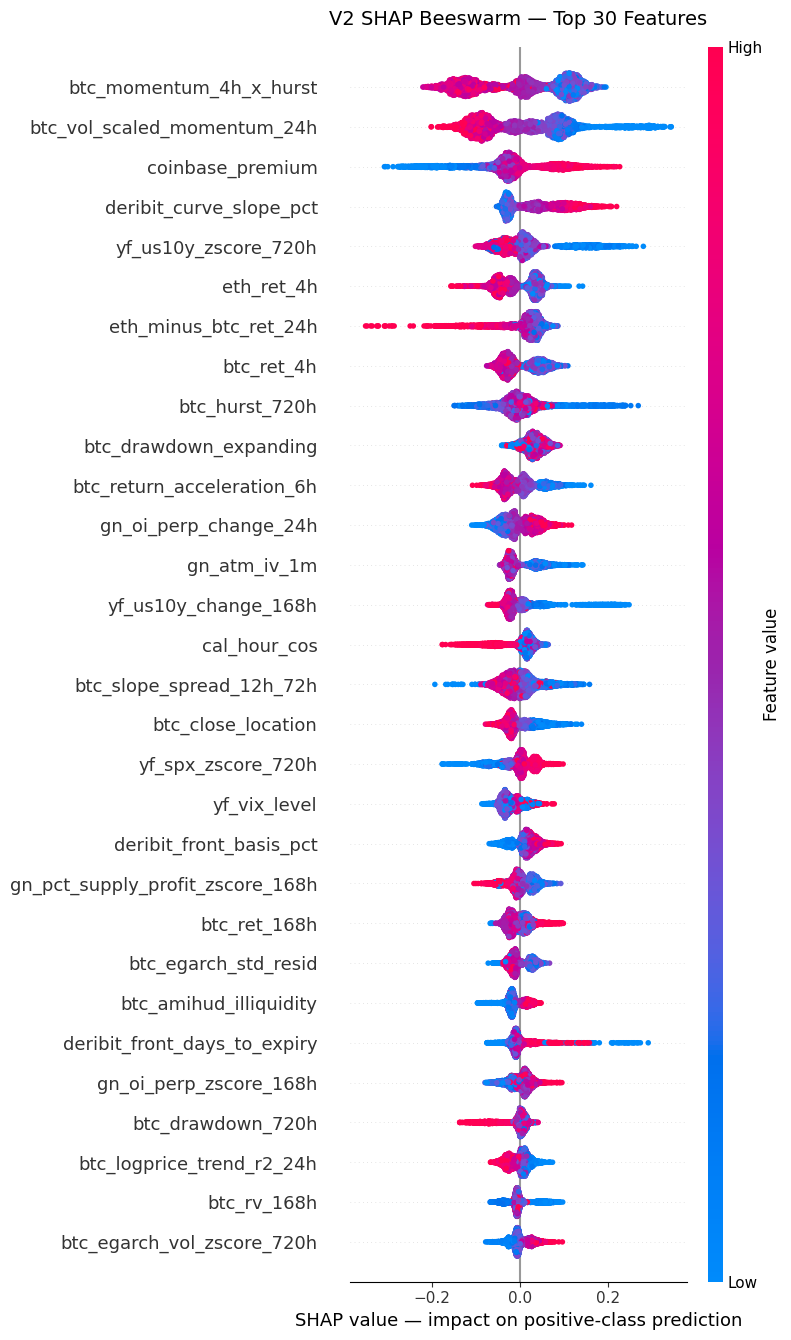

In [33]:
# Plot the v2 SHAP beeswarm summary

import matplotlib.pyplot as plt

SHAP_BEESWARM_MAX_DISPLAY_V2 = 30

plt.figure(figsize=(11, 12))
shap.summary_plot(shap_values_v2, X_shap_sample_v2, plot_type="dot", max_display=SHAP_BEESWARM_MAX_DISPLAY_V2, show=False)
plt.title("V2 SHAP Beeswarm — Top 30 Features", fontsize=14, pad=16)
plt.xlabel("SHAP value — impact on positive-class prediction")
plt.tight_layout()
plt.show()

In [35]:
# Compare untuned L2 logistic regression across v2 SHAP-ranked feature sets

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

L2_FEATURE_COUNTS_V2 = [20, 30, 40, len(shap_feature_ranking_v2)]

l2_results_v2 = []

for feature_count_v2 in L2_FEATURE_COUNTS_V2:
    selected_features_v2 = shap_feature_ranking_v2.head(feature_count_v2)["feature"].tolist()

    X_l2_train_v2 = X_shap_train_v2[selected_features_v2].copy()
    X_l2_valid_v2 = X_shap_valid_v2[selected_features_v2].copy()

    l2_model_v2 = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=2000, random_state=42))
    ])

    l2_model_v2.fit(X_l2_train_v2, y_shap_train_v2)

    l2_valid_probability_v2 = l2_model_v2.predict_proba(X_l2_valid_v2)[:, 1]
    l2_valid_prediction_v2 = (l2_valid_probability_v2 >= 0.50).astype(int)

    l2_results_v2.append({
        "feature_set": f"Top {feature_count_v2}" if feature_count_v2 < len(shap_feature_ranking_v2) else f"All {feature_count_v2}",
        "feature_count": feature_count_v2,
        "accuracy": accuracy_score(y_shap_valid_v2, l2_valid_prediction_v2),
        "balanced_accuracy": balanced_accuracy_score(y_shap_valid_v2, l2_valid_prediction_v2),
        "roc_auc": roc_auc_score(y_shap_valid_v2, l2_valid_probability_v2),
        "precision": precision_score(y_shap_valid_v2, l2_valid_prediction_v2, zero_division=0),
        "recall": recall_score(y_shap_valid_v2, l2_valid_prediction_v2, zero_division=0),
        "f1_score": f1_score(y_shap_valid_v2, l2_valid_prediction_v2, zero_division=0),
        "predicted_positive_pct": l2_valid_prediction_v2.mean() * 100
    })

l2_results_v2 = pd.DataFrame(l2_results_v2)
l2_results_v2 = l2_results_v2.sort_values(["roc_auc", "balanced_accuracy"], ascending=False).reset_index(drop=True)

L2_RESULTS_V2_PATH = DATA_PATH / "l2_feature_set_comparison_v2.csv"
l2_results_v2.to_csv(L2_RESULTS_V2_PATH, index=False)

print("Chronological training observations:", len(X_shap_train_v2))
print("Chronological validation observations:", len(X_shap_valid_v2))
print("Validation positive-class percentage:", round(y_shap_valid_v2.mean() * 100, 2))
print("Saved L2 comparison to:", L2_RESULTS_V2_PATH)

display(l2_results_v2.style.format({
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "roc_auc": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1_score": "{:.4f}",
    "predicted_positive_pct": "{:.2f}"
}))

Chronological training observations: 28202
Chronological validation observations: 7051
Validation positive-class percentage: 51.26
Saved L2 comparison to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/l2_feature_set_comparison_v2.csv


,feature_set,feature_count,accuracy,balanced_accuracy,roc_auc,precision,recall,f1_score,predicted_positive_pct
0,All 70,70,0.5344,0.5370,0.5542,0.5592,0.4328,0.4879,39.67
1,Top 40,40,0.5311,0.5300,0.5442,0.5401,0.5739,0.5565,54.46
2,Top 20,20,0.5382,0.5332,0.5439,0.5362,0.7341,0.6197,70.17
3,Top 30,30,0.5343,0.5316,0.5416,0.5385,0.6384,0.5842,60.76


In [43]:
# Compare untuned Random Forest and Extra Trees on the full 70-feature v2 set

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import time

tree_models_v2 = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight=None,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight=None,
        random_state=42,
        n_jobs=-1
    )
}

tree_results_v2 = []

for model_name_v2, model_v2 in tree_models_v2.items():
    start_time_v2 = time.time()
    model_v2.fit(X_shap_train_v2, y_shap_train_v2)
    runtime_seconds_v2 = time.time() - start_time_v2

    valid_probability_v2 = model_v2.predict_proba(X_shap_valid_v2)[:, 1]
    valid_prediction_v2 = (valid_probability_v2 >= 0.50).astype(int)

    tree_results_v2.append({
        "model": model_name_v2,
        "feature_count": X_shap_train_v2.shape[1],
        "accuracy": accuracy_score(y_shap_valid_v2, valid_prediction_v2),
        "balanced_accuracy": balanced_accuracy_score(y_shap_valid_v2, valid_prediction_v2),
        "roc_auc": roc_auc_score(y_shap_valid_v2, valid_probability_v2),
        "precision": precision_score(y_shap_valid_v2, valid_prediction_v2, zero_division=0),
        "recall": recall_score(y_shap_valid_v2, valid_prediction_v2, zero_division=0),
        "f1_score": f1_score(y_shap_valid_v2, valid_prediction_v2, zero_division=0),
        "predicted_positive_pct": valid_prediction_v2.mean() * 100,
        "runtime_seconds": runtime_seconds_v2
    })

tree_results_v2 = pd.DataFrame(tree_results_v2)
tree_results_v2 = tree_results_v2.sort_values(["roc_auc", "balanced_accuracy"], ascending=False).reset_index(drop=True)

TREE_RESULTS_V2_PATH = DATA_PATH / "tree_model_screen_v2.csv"
tree_results_v2.to_csv(TREE_RESULTS_V2_PATH, index=False)

print("Training observations:", len(X_shap_train_v2))
print("Validation observations:", len(X_shap_valid_v2))
print("Features:", X_shap_train_v2.shape[1])
print("Saved tree-model comparison to:", TREE_RESULTS_V2_PATH)

display(tree_results_v2.style.format({
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "roc_auc": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1_score": "{:.4f}",
    "predicted_positive_pct": "{:.2f}",
    "runtime_seconds": "{:.2f}"
}))

Training observations: 28202
Validation observations: 7051
Features: 70
Saved tree-model comparison to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/tree_model_screen_v2.csv


,model,feature_count,accuracy,balanced_accuracy,roc_auc,precision,recall,f1_score,predicted_positive_pct,runtime_seconds
0,Extra Trees,70,0.5401,0.5365,0.5532,0.5410,0.6774,0.6015,64.18,26.08
1,Random Forest,70,0.5391,0.5368,0.5524,0.5435,0.6287,0.5830,59.28,149.62


In [44]:
# Run an untuned HistGradientBoosting baseline on the full 70-feature v2 set

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import time

hist_model_v2 = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=100,
    max_leaf_nodes=31,
    l2_regularization=0.0,
    random_state=42
)

start_time_v2 = time.time()

hist_model_v2.fit(X_shap_train_v2, y_shap_train_v2)

hist_runtime_seconds_v2 = time.time() - start_time_v2

hist_valid_probability_v2 = hist_model_v2.predict_proba(X_shap_valid_v2)[:, 1]
hist_valid_prediction_v2 = (hist_valid_probability_v2 >= 0.50).astype(int)

hist_results_v2 = pd.DataFrame([{
    "model": "HistGradientBoosting",
    "feature_count": X_shap_train_v2.shape[1],
    "accuracy": accuracy_score(y_shap_valid_v2, hist_valid_prediction_v2),
    "balanced_accuracy": balanced_accuracy_score(y_shap_valid_v2, hist_valid_prediction_v2),
    "roc_auc": roc_auc_score(y_shap_valid_v2, hist_valid_probability_v2),
    "precision": precision_score(y_shap_valid_v2, hist_valid_prediction_v2, zero_division=0),
    "recall": recall_score(y_shap_valid_v2, hist_valid_prediction_v2, zero_division=0),
    "f1_score": f1_score(y_shap_valid_v2, hist_valid_prediction_v2, zero_division=0),
    "predicted_positive_pct": hist_valid_prediction_v2.mean() * 100,
    "runtime_seconds": hist_runtime_seconds_v2
}])

HIST_RESULTS_V2_PATH = DATA_PATH / "hist_gradient_boosting_screen_v2.csv"
hist_results_v2.to_csv(HIST_RESULTS_V2_PATH, index=False)

print("Training observations:", len(X_shap_train_v2))
print("Validation observations:", len(X_shap_valid_v2))
print("Features:", X_shap_train_v2.shape[1])
print("Saved HistGradientBoosting result to:", HIST_RESULTS_V2_PATH)

display(hist_results_v2.style.format({
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "roc_auc": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1_score": "{:.4f}",
    "predicted_positive_pct": "{:.2f}",
    "runtime_seconds": "{:.2f}"
}))

Training observations: 28202
Validation observations: 7051
Features: 70
Saved HistGradientBoosting result to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/hist_gradient_boosting_screen_v2.csv


,model,feature_count,accuracy,balanced_accuracy,roc_auc,precision,recall,f1_score,predicted_positive_pct,runtime_seconds
0,HistGradientBoosting,70,0.5257,0.5232,0.5403,0.5318,0.6251,0.5747,60.25,7.60


In [45]:
# Run an untuned LightGBM baseline on the full 70-feature v2 set

import time
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

lightgbm_model_v2 = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

start_time_v2 = time.time()

lightgbm_model_v2.fit(X_shap_train_v2, y_shap_train_v2)

lightgbm_runtime_seconds_v2 = time.time() - start_time_v2

lightgbm_valid_probability_v2 = lightgbm_model_v2.predict_proba(X_shap_valid_v2)[:, 1]
lightgbm_valid_prediction_v2 = (lightgbm_valid_probability_v2 >= 0.50).astype(int)

lightgbm_results_v2 = pd.DataFrame([{
    "model": "LightGBM",
    "feature_count": X_shap_train_v2.shape[1],
    "accuracy": accuracy_score(y_shap_valid_v2, lightgbm_valid_prediction_v2),
    "balanced_accuracy": balanced_accuracy_score(y_shap_valid_v2, lightgbm_valid_prediction_v2),
    "roc_auc": roc_auc_score(y_shap_valid_v2, lightgbm_valid_probability_v2),
    "precision": precision_score(y_shap_valid_v2, lightgbm_valid_prediction_v2, zero_division=0),
    "recall": recall_score(y_shap_valid_v2, lightgbm_valid_prediction_v2, zero_division=0),
    "f1_score": f1_score(y_shap_valid_v2, lightgbm_valid_prediction_v2, zero_division=0),
    "predicted_positive_pct": lightgbm_valid_prediction_v2.mean() * 100,
    "runtime_seconds": lightgbm_runtime_seconds_v2
}])

LIGHTGBM_RESULTS_V2_PATH = DATA_PATH / "lightgbm_screen_v2.csv"
lightgbm_results_v2.to_csv(LIGHTGBM_RESULTS_V2_PATH, index=False)

print("Training observations:", len(X_shap_train_v2))
print("Validation observations:", len(X_shap_valid_v2))
print("Features:", X_shap_train_v2.shape[1])
print("Saved LightGBM result to:", LIGHTGBM_RESULTS_V2_PATH)

display(lightgbm_results_v2.style.format({
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "roc_auc": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1_score": "{:.4f}",
    "predicted_positive_pct": "{:.2f}",
    "runtime_seconds": "{:.2f}"
}))

Training observations: 28202
Validation observations: 7051
Features: 70
Saved LightGBM result to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/lightgbm_screen_v2.csv


,model,feature_count,accuracy,balanced_accuracy,roc_auc,precision,recall,f1_score,predicted_positive_pct,runtime_seconds
0,LightGBM,70,0.5335,0.5300,0.5425,0.5359,0.6704,0.5957,64.12,15.72


In [48]:
# Fast Elastic Net logistic stability selection for a 30-feature v2 candidate set

import time
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ELASTIC_NET_TARGET_FEATURES_V2 = 30
ELASTIC_NET_TUNING_SPLITS_V2 = 3
ELASTIC_NET_STABILITY_SPLITS_V2 = 5
ELASTIC_NET_GAP_V2 = 4
ELASTIC_NET_CS_V2 = [0.01, 0.05, 0.20, 1.00]
ELASTIC_NET_L1_RATIOS_V2 = [0.25, 0.50, 0.75]
ELASTIC_NET_MAX_ITER_V2 = 3000
ELASTIC_NET_TOL_V2 = 1e-3
ELASTIC_NET_ZERO_TOL_V2 = 1e-6

elastic_net_tuning_cv_v2 = TimeSeriesSplit(n_splits=ELASTIC_NET_TUNING_SPLITS_V2, gap=ELASTIC_NET_GAP_V2)

elastic_net_cv_model_v2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegressionCV(
        Cs=ELASTIC_NET_CS_V2,
        cv=elastic_net_tuning_cv_v2,
        penalty="elasticnet",
        solver="saga",
        l1_ratios=ELASTIC_NET_L1_RATIOS_V2,
        scoring="roc_auc",
        max_iter=ELASTIC_NET_MAX_ITER_V2,
        tol=ELASTIC_NET_TOL_V2,
        random_state=42,
        n_jobs=-1,
        refit=True
    ))
])

start_time_v2 = time.time()
elastic_net_cv_model_v2.fit(X_shap_train_v2, y_shap_train_v2)
elastic_net_runtime_minutes_v2 = (time.time() - start_time_v2) / 60

elastic_net_estimator_v2 = elastic_net_cv_model_v2.named_steps["model"]
best_c_v2 = float(np.ravel(elastic_net_estimator_v2.C_)[0])
best_l1_ratio_v2 = float(np.ravel(elastic_net_estimator_v2.l1_ratio_)[0])

elastic_net_stability_cv_v2 = TimeSeriesSplit(n_splits=ELASTIC_NET_STABILITY_SPLITS_V2, gap=ELASTIC_NET_GAP_V2)
elastic_net_fold_coefficients_v2 = []
elastic_net_fold_details_v2 = []

for fold_v2, (train_idx_v2, valid_idx_v2) in enumerate(elastic_net_stability_cv_v2.split(X_shap_train_v2), start=1):
    X_fold_train_v2 = X_shap_train_v2.iloc[train_idx_v2]
    y_fold_train_v2 = y_shap_train_v2.iloc[train_idx_v2]

    fold_model_v2 = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=best_c_v2,
            l1_ratio=best_l1_ratio_v2,
            max_iter=ELASTIC_NET_MAX_ITER_V2,
            tol=ELASTIC_NET_TOL_V2,
            random_state=42
        ))
    ])

    fold_model_v2.fit(X_fold_train_v2, y_fold_train_v2)

    fold_estimator_v2 = fold_model_v2.named_steps["model"]
    fold_coefficients_v2 = pd.Series(fold_estimator_v2.coef_.ravel(), index=X_shap_train_v2.columns, name=f"fold_{fold_v2}")

    elastic_net_fold_coefficients_v2.append(fold_coefficients_v2)

    elastic_net_fold_details_v2.append({
        "fold": fold_v2,
        "training_observations": len(train_idx_v2),
        "validation_observations": len(valid_idx_v2),
        "iterations_used": int(np.ravel(fold_estimator_v2.n_iter_)[0]),
        "nonzero_features": int((fold_coefficients_v2.abs() > ELASTIC_NET_ZERO_TOL_V2).sum())
    })

elastic_net_fold_coefficients_v2 = pd.concat(elastic_net_fold_coefficients_v2, axis=1)
elastic_net_fold_details_v2 = pd.DataFrame(elastic_net_fold_details_v2)

elastic_net_full_coefficients_v2 = pd.Series(elastic_net_estimator_v2.coef_.ravel(), index=X_shap_train_v2.columns)
elastic_net_nonzero_mask_v2 = elastic_net_fold_coefficients_v2.abs() > ELASTIC_NET_ZERO_TOL_V2

selection_count_v2 = elastic_net_nonzero_mask_v2.sum(axis=1)
selection_frequency_v2 = elastic_net_nonzero_mask_v2.mean(axis=1)
median_coefficient_v2 = elastic_net_fold_coefficients_v2.median(axis=1)
median_abs_coefficient_v2 = elastic_net_fold_coefficients_v2.abs().median(axis=1)

def elastic_net_sign_consistency_v2(row_v2):
    nonzero_row_v2 = row_v2[row_v2.abs() > ELASTIC_NET_ZERO_TOL_V2]
    if nonzero_row_v2.empty:
        return 0.0
    return float(max((nonzero_row_v2 > 0).mean(), (nonzero_row_v2 < 0).mean()))

sign_consistency_v2 = elastic_net_fold_coefficients_v2.apply(elastic_net_sign_consistency_v2, axis=1)

elastic_net_stability_ranking_v2 = pd.DataFrame({
    "feature": X_shap_train_v2.columns,
    "selection_count": selection_count_v2.reindex(X_shap_train_v2.columns).values,
    "selection_frequency": selection_frequency_v2.reindex(X_shap_train_v2.columns).values,
    "sign_consistency": sign_consistency_v2.reindex(X_shap_train_v2.columns).values,
    "median_coefficient": median_coefficient_v2.reindex(X_shap_train_v2.columns).values,
    "median_abs_coefficient": median_abs_coefficient_v2.reindex(X_shap_train_v2.columns).values,
    "full_train_coefficient": elastic_net_full_coefficients_v2.reindex(X_shap_train_v2.columns).values
})

elastic_net_stability_ranking_v2["full_train_nonzero"] = elastic_net_stability_ranking_v2["full_train_coefficient"].abs() > ELASTIC_NET_ZERO_TOL_V2

elastic_net_stability_ranking_v2 = elastic_net_stability_ranking_v2.sort_values(
    ["selection_frequency", "sign_consistency", "median_abs_coefficient", "full_train_nonzero"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

elastic_net_stability_ranking_v2["stability_rank"] = np.arange(1, len(elastic_net_stability_ranking_v2) + 1)

elastic_net_selected_features_v2 = elastic_net_stability_ranking_v2.head(ELASTIC_NET_TARGET_FEATURES_V2)["feature"].tolist()

X_elastic_net30_train_v2 = X_shap_train_v2[elastic_net_selected_features_v2].copy()
X_elastic_net30_valid_v2 = X_shap_valid_v2[elastic_net_selected_features_v2].copy()

ELASTIC_NET_RANKING_PATH_V2 = DATA_PATH / "elastic_net_stability_ranking_v2.csv"
ELASTIC_NET_SELECTED_PATH_V2 = DATA_PATH / "elastic_net_selected_features_30_v2.csv"
ELASTIC_NET_FOLD_PATH_V2 = DATA_PATH / "elastic_net_fold_details_v2.csv"

elastic_net_stability_ranking_v2.to_csv(ELASTIC_NET_RANKING_PATH_V2, index=False)
pd.DataFrame({"feature": elastic_net_selected_features_v2}).to_csv(ELASTIC_NET_SELECTED_PATH_V2, index=False)
elastic_net_fold_details_v2.to_csv(ELASTIC_NET_FOLD_PATH_V2, index=False)

assert len(elastic_net_selected_features_v2) == 30, "Elastic Net did not produce exactly 30 selected features."
assert X_elastic_net30_train_v2.shape[1] == 30, "Reduced training matrix does not contain 30 features."
assert X_elastic_net30_valid_v2.shape[1] == 30, "Reduced validation matrix does not contain 30 features."

print("Elastic Net runtime in minutes:", round(elastic_net_runtime_minutes_v2, 2))
print("Best C:", best_c_v2)
print("Best l1 ratio:", best_l1_ratio_v2)
print("Full-fit non-zero features:", int(elastic_net_stability_ranking_v2["full_train_nonzero"].sum()))
print("Selected reduced features:", len(elastic_net_selected_features_v2))
print("Reduced training matrix:", X_elastic_net30_train_v2.shape)
print("Reduced validation matrix:", X_elastic_net30_valid_v2.shape)
print("Saved stability ranking to:", ELASTIC_NET_RANKING_PATH_V2)
print("Saved selected features to:", ELASTIC_NET_SELECTED_PATH_V2)
print("Saved fold details to:", ELASTIC_NET_FOLD_PATH_V2)

display(elastic_net_fold_details_v2)

display(elastic_net_stability_ranking_v2.head(40).style.format({
    "selection_frequency": "{:.2f}",
    "sign_consistency": "{:.2f}",
    "median_coefficient": "{:.6f}",
    "median_abs_coefficient": "{:.6f}",
    "full_train_coefficient": "{:.6f}"
}))

Elastic Net runtime in minutes: 2.06
Best C: 0.01
Best l1 ratio: 0.75
Full-fit non-zero features: 43
Selected reduced features: 30
Reduced training matrix: (28202, 30)
Reduced validation matrix: (7051, 30)
Saved stability ranking to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/elastic_net_stability_ranking_v2.csv
Saved selected features to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/elastic_net_selected_features_30_v2.csv
Saved fold details to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/elastic_net_fold_details_v2.csv


,fold,training_observations,validation_observations,iterations_used,nonzero_features
0,1,4698,4700,13,10
1,2,9398,4700,22,22
2,3,14098,4700,13,23
3,4,18798,4700,15,33
4,5,23498,4700,24,34


,feature,selection_count,selection_frequency,sign_consistency,median_coefficient,median_abs_coefficient,full_train_coefficient,full_train_nonzero,stability_rank
0,eth_minus_btc_ret_24h,5,1.00,1.00,-0.073068,0.073068,-0.056099,True,1
1,coinbase_premium,5,1.00,1.00,0.066748,0.066748,0.058907,True,2
2,btc_vol_scaled_momentum_24h,5,1.00,1.00,-0.066481,0.066481,-0.142201,True,3
3,eth_ret_4h,5,1.00,1.00,-0.043692,0.043692,-0.025978,True,4
4,btc_momentum_4h_x_hurst,5,1.00,1.00,-0.034557,0.034557,-0.069071,True,5
5,cal_hour_cos,5,1.00,1.00,-0.029915,0.029915,-0.017034,True,6
6,gn_pct_supply_profit_change_24h,5,1.00,1.00,-0.024844,0.024844,-0.008844,True,7
7,btc_close_location,4,0.80,1.00,-0.046113,0.046113,-0.054458,True,8
8,gn_oi_perp_change_24h,4,0.80,1.00,0.033558,0.033558,0.029340,True,9
9,yf_vix_level,4,0.80,1.00,0.028161,0.028161,0.011384,True,10


In [50]:
# Compare the original and adjusted Elastic Net Top 30 using untuned L2 logistic regression

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

ELASTIC_NET_FEATURE_COUNT_V2 = 30
ELASTIC_NET_EXCLUSIONS_V2 = ["coinbase_premium", "gn_inv_loss_seller_signed_log"]

elastic_net_original30_features_v2 = elastic_net_stability_ranking_v2.head(ELASTIC_NET_FEATURE_COUNT_V2)["feature"].tolist()

missing_exclusions_v2 = [feature for feature in ELASTIC_NET_EXCLUSIONS_V2 if feature not in elastic_net_original30_features_v2]
assert not missing_exclusions_v2, f"Excluded features are not inside the original Top 30: {missing_exclusions_v2}"

elastic_net_adjusted30_features_v2 = [feature for feature in elastic_net_original30_features_v2 if feature not in ELASTIC_NET_EXCLUSIONS_V2]

replacement_candidates_v2 = elastic_net_stability_ranking_v2.loc[
    ~elastic_net_stability_ranking_v2["feature"].isin(elastic_net_original30_features_v2 + ELASTIC_NET_EXCLUSIONS_V2),
    "feature"
].tolist()

replacement_count_v2 = ELASTIC_NET_FEATURE_COUNT_V2 - len(elastic_net_adjusted30_features_v2)
elastic_net_replacement_features_v2 = replacement_candidates_v2[:replacement_count_v2]
elastic_net_adjusted30_features_v2.extend(elastic_net_replacement_features_v2)

assert len(elastic_net_original30_features_v2) == 30, "Original Elastic Net set does not contain 30 features."
assert len(elastic_net_adjusted30_features_v2) == 30, "Adjusted Elastic Net set does not contain 30 features."
assert len(set(elastic_net_adjusted30_features_v2)) == 30, "Duplicate features detected in the adjusted set."
assert not set(ELASTIC_NET_EXCLUSIONS_V2).intersection(elastic_net_adjusted30_features_v2), "Excluded features remain in the adjusted set."

elastic_net_l2_feature_sets_v2 = {
    "Elastic Net Top 30": elastic_net_original30_features_v2,
    "Elastic Net Adjusted Top 30": elastic_net_adjusted30_features_v2
}

elastic_net_l2_results_v2 = []

for feature_set_name_v2, selected_features_v2 in elastic_net_l2_feature_sets_v2.items():
    X_l2_train_v2 = X_shap_train_v2[selected_features_v2].copy()
    X_l2_valid_v2 = X_shap_valid_v2[selected_features_v2].copy()

    l2_model_v2 = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=2000, random_state=42))
    ])

    l2_model_v2.fit(X_l2_train_v2, y_shap_train_v2)

    l2_valid_probability_v2 = l2_model_v2.predict_proba(X_l2_valid_v2)[:, 1]
    l2_valid_prediction_v2 = (l2_valid_probability_v2 >= 0.50).astype(int)

    elastic_net_l2_results_v2.append({
        "feature_set": feature_set_name_v2,
        "feature_count": len(selected_features_v2),
        "accuracy": accuracy_score(y_shap_valid_v2, l2_valid_prediction_v2),
        "balanced_accuracy": balanced_accuracy_score(y_shap_valid_v2, l2_valid_prediction_v2),
        "roc_auc": roc_auc_score(y_shap_valid_v2, l2_valid_probability_v2),
        "precision": precision_score(y_shap_valid_v2, l2_valid_prediction_v2, zero_division=0),
        "recall": recall_score(y_shap_valid_v2, l2_valid_prediction_v2, zero_division=0),
        "f1_score": f1_score(y_shap_valid_v2, l2_valid_prediction_v2, zero_division=0),
        "predicted_positive_pct": l2_valid_prediction_v2.mean() * 100
    })

elastic_net_l2_results_v2 = pd.DataFrame(elastic_net_l2_results_v2)
elastic_net_l2_results_v2 = elastic_net_l2_results_v2.sort_values(["roc_auc", "balanced_accuracy"], ascending=False).reset_index(drop=True)

ELASTIC_NET_L2_RESULTS_PATH_V2 = DATA_PATH / "elastic_net_top30_l2_comparison_v2.csv"
ELASTIC_NET_ADJUSTED_FEATURES_PATH_V2 = DATA_PATH / "elastic_net_adjusted_features_30_v2.csv"

elastic_net_l2_results_v2.to_csv(ELASTIC_NET_L2_RESULTS_PATH_V2, index=False)
pd.DataFrame({"feature": elastic_net_adjusted30_features_v2}).to_csv(ELASTIC_NET_ADJUSTED_FEATURES_PATH_V2, index=False)

print("Excluded features:", ELASTIC_NET_EXCLUSIONS_V2)
print("Replacement features:", elastic_net_replacement_features_v2)
print("Original Top 30 features:", len(elastic_net_original30_features_v2))
print("Adjusted Top 30 features:", len(elastic_net_adjusted30_features_v2))
print("Saved L2 comparison to:", ELASTIC_NET_L2_RESULTS_PATH_V2)
print("Saved adjusted feature list to:", ELASTIC_NET_ADJUSTED_FEATURES_PATH_V2)

display(elastic_net_l2_results_v2.style.format({
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "roc_auc": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1_score": "{:.4f}",
    "predicted_positive_pct": "{:.2f}"
}))

display(pd.DataFrame({
    "original_top30": elastic_net_original30_features_v2,
    "adjusted_top30": elastic_net_adjusted30_features_v2
}))

Excluded features: ['coinbase_premium', 'gn_inv_loss_seller_signed_log']
Replacement features: ['gn_opt_skew_1m', 'btc_egarch_std_resid']
Original Top 30 features: 30
Adjusted Top 30 features: 30
Saved L2 comparison to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/elastic_net_top30_l2_comparison_v2.csv
Saved adjusted feature list to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/elastic_net_adjusted_features_30_v2.csv


,feature_set,feature_count,accuracy,balanced_accuracy,roc_auc,precision,recall,f1_score,predicted_positive_pct
0,Elastic Net Adjusted Top 30,30,0.5372,0.5346,0.5488,0.5412,0.6381,0.5857,60.43
1,Elastic Net Top 30,30,0.5337,0.5308,0.5466,0.5376,0.6442,0.5861,61.41


,original_top30,adjusted_top30
0,eth_minus_btc_ret_24h,eth_minus_btc_ret_24h
1,coinbase_premium,btc_vol_scaled_momentum_24h
2,btc_vol_scaled_momentum_24h,eth_ret_4h
3,eth_ret_4h,btc_momentum_4h_x_hurst
4,btc_momentum_4h_x_hurst,cal_hour_cos
5,cal_hour_cos,gn_pct_supply_profit_change_24h
6,gn_pct_supply_profit_change_24h,btc_close_location
7,btc_close_location,gn_oi_perp_change_24h
8,gn_oi_perp_change_24h,yf_vix_level
9,yf_vix_level,btc_return_acceleration_6h


In [51]:
# Compare three Elastic Net 30-feature sets, including one with all inverse-loss-seller features removed

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

ELASTIC_NET_FEATURE_COUNT_V2 = 30
COINBASE_EXCLUSION_V2 = ["coinbase_premium"]
INV_LOSS_EXCLUSIONS_V2 = [feature for feature in elastic_net_stability_ranking_v2["feature"] if "inv_loss_seller" in feature]

elastic_net_original30_features_v2 = elastic_net_stability_ranking_v2.head(ELASTIC_NET_FEATURE_COUNT_V2)["feature"].tolist()
elastic_net_adjusted30_exclusions_v2 = COINBASE_EXCLUSION_V2 + ["gn_inv_loss_seller_signed_log"]
elastic_net_no_inv_loss_exclusions_v2 = COINBASE_EXCLUSION_V2 + INV_LOSS_EXCLUSIONS_V2

def build_adjusted_top30_v2(excluded_features_v2):
    ranked_features_v2 = elastic_net_stability_ranking_v2["feature"].tolist()
    selected_features_v2 = [feature for feature in elastic_net_original30_features_v2 if feature not in excluded_features_v2]
    replacement_features_v2 = [feature for feature in ranked_features_v2 if feature not in selected_features_v2 and feature not in excluded_features_v2]
    replacements_needed_v2 = ELASTIC_NET_FEATURE_COUNT_V2 - len(selected_features_v2)
    selected_features_v2.extend(replacement_features_v2[:replacements_needed_v2])
    return selected_features_v2, replacement_features_v2[:replacements_needed_v2]

elastic_net_adjusted30_features_v2, elastic_net_adjusted30_replacements_v2 = build_adjusted_top30_v2(elastic_net_adjusted30_exclusions_v2)
elastic_net_no_inv_loss30_features_v2, elastic_net_no_inv_loss30_replacements_v2 = build_adjusted_top30_v2(elastic_net_no_inv_loss_exclusions_v2)

assert len(elastic_net_original30_features_v2) == 30, "Original Elastic Net set does not contain 30 features."
assert len(elastic_net_adjusted30_features_v2) == 30, "Adjusted Elastic Net set does not contain 30 features."
assert len(elastic_net_no_inv_loss30_features_v2) == 30, "No-inverse-loss Elastic Net set does not contain 30 features."
assert len(set(elastic_net_no_inv_loss30_features_v2)) == 30, "Duplicate features detected in the no-inverse-loss set."
assert "coinbase_premium" not in elastic_net_no_inv_loss30_features_v2, "Coinbase premium remains in the no-inverse-loss set."
assert not any("inv_loss_seller" in feature for feature in elastic_net_no_inv_loss30_features_v2), "An inverse-loss feature remains in the no-inverse-loss set."

elastic_net_l2_feature_sets_v2 = {
    "Elastic Net Top 30": elastic_net_original30_features_v2,
    "Elastic Net Adjusted Top 30": elastic_net_adjusted30_features_v2,
    "Elastic Net No Inv Loss Top 30": elastic_net_no_inv_loss30_features_v2
}

elastic_net_l2_results_v2 = []

for feature_set_name_v2, selected_features_v2 in elastic_net_l2_feature_sets_v2.items():
    X_l2_train_v2 = X_shap_train_v2[selected_features_v2].copy()
    X_l2_valid_v2 = X_shap_valid_v2[selected_features_v2].copy()

    l2_model_v2 = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=2000, random_state=42))
    ])

    l2_model_v2.fit(X_l2_train_v2, y_shap_train_v2)

    l2_valid_probability_v2 = l2_model_v2.predict_proba(X_l2_valid_v2)[:, 1]
    l2_valid_prediction_v2 = (l2_valid_probability_v2 >= 0.50).astype(int)

    elastic_net_l2_results_v2.append({
        "feature_set": feature_set_name_v2,
        "feature_count": len(selected_features_v2),
        "accuracy": accuracy_score(y_shap_valid_v2, l2_valid_prediction_v2),
        "balanced_accuracy": balanced_accuracy_score(y_shap_valid_v2, l2_valid_prediction_v2),
        "roc_auc": roc_auc_score(y_shap_valid_v2, l2_valid_probability_v2),
        "precision": precision_score(y_shap_valid_v2, l2_valid_prediction_v2, zero_division=0),
        "recall": recall_score(y_shap_valid_v2, l2_valid_prediction_v2, zero_division=0),
        "f1_score": f1_score(y_shap_valid_v2, l2_valid_prediction_v2, zero_division=0),
        "predicted_positive_pct": l2_valid_prediction_v2.mean() * 100
    })

elastic_net_l2_results_v2 = pd.DataFrame(elastic_net_l2_results_v2)
elastic_net_l2_results_v2 = elastic_net_l2_results_v2.sort_values(["roc_auc", "balanced_accuracy"], ascending=False).reset_index(drop=True)

ELASTIC_NET_L2_RESULTS_PATH_V2 = DATA_PATH / "elastic_net_top30_l2_three_way_comparison_v2.csv"
ELASTIC_NET_NO_INV_LOSS_PATH_V2 = DATA_PATH / "elastic_net_no_inv_loss_features_30_v2.csv"

elastic_net_l2_results_v2.to_csv(ELASTIC_NET_L2_RESULTS_PATH_V2, index=False)
pd.DataFrame({"feature": elastic_net_no_inv_loss30_features_v2}).to_csv(ELASTIC_NET_NO_INV_LOSS_PATH_V2, index=False)

print("All inverse-loss exclusions:", INV_LOSS_EXCLUSIONS_V2)
print("Adjusted Top 30 replacements:", elastic_net_adjusted30_replacements_v2)
print("No-inverse-loss Top 30 replacements:", elastic_net_no_inv_loss30_replacements_v2)
print("Saved comparison to:", ELASTIC_NET_L2_RESULTS_PATH_V2)
print("Saved no-inverse-loss feature list to:", ELASTIC_NET_NO_INV_LOSS_PATH_V2)

display(elastic_net_l2_results_v2.style.format({
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "roc_auc": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1_score": "{:.4f}",
    "predicted_positive_pct": "{:.2f}"
}))

display(pd.DataFrame({
    "original_top30": elastic_net_original30_features_v2,
    "adjusted_top30": elastic_net_adjusted30_features_v2,
    "no_inv_loss_top30": elastic_net_no_inv_loss30_features_v2
}))

All inverse-loss exclusions: ['gn_inv_loss_seller_change_24h', 'gn_inv_loss_seller_signed_log', 'gn_inv_loss_seller_zscore_168h']
Adjusted Top 30 replacements: ['gn_opt_skew_1m', 'btc_egarch_std_resid']
No-inverse-loss Top 30 replacements: ['gn_opt_skew_1m', 'btc_egarch_std_resid', 'btc_hurst_720h', 'gn_atm_iv_1m_zscore_168h']
Saved comparison to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/elastic_net_top30_l2_three_way_comparison_v2.csv
Saved no-inverse-loss feature list to: /content/drive/MyDrive/Colab Notebooks/CQF_final_project/data/elastic_net_no_inv_loss_features_30_v2.csv


,feature_set,feature_count,accuracy,balanced_accuracy,roc_auc,precision,recall,f1_score,predicted_positive_pct
0,Elastic Net No Inv Loss Top 30,30,0.5314,0.5284,0.5510,0.5355,0.6472,0.5861,61.95
1,Elastic Net Adjusted Top 30,30,0.5372,0.5346,0.5488,0.5412,0.6381,0.5857,60.43
2,Elastic Net Top 30,30,0.5337,0.5308,0.5466,0.5376,0.6442,0.5861,61.41


,original_top30,adjusted_top30,no_inv_loss_top30
0,eth_minus_btc_ret_24h,eth_minus_btc_ret_24h,eth_minus_btc_ret_24h
1,coinbase_premium,btc_vol_scaled_momentum_24h,btc_vol_scaled_momentum_24h
2,btc_vol_scaled_momentum_24h,eth_ret_4h,eth_ret_4h
3,eth_ret_4h,btc_momentum_4h_x_hurst,btc_momentum_4h_x_hurst
4,btc_momentum_4h_x_hurst,cal_hour_cos,cal_hour_cos
5,cal_hour_cos,gn_pct_supply_profit_change_24h,gn_pct_supply_profit_change_24h
6,gn_pct_supply_profit_change_24h,btc_close_location,btc_close_location
7,btc_close_location,gn_oi_perp_change_24h,gn_oi_perp_change_24h
8,gn_oi_perp_change_24h,yf_vix_level,yf_vix_level
9,yf_vix_level,btc_return_acceleration_6h,btc_return_acceleration_6h
